# 00. ACOS Master Pipeline: End-to-End Execution (Production PRO Version)

**Aspect-Category-Opinion-Sentiment (ACOS) Quadruple Extraction with Implicit Aspects and Opinions**

This production-grade master notebook executes the **entire ACOS benchmark pipeline with 1-Click** on **Google Colab** (with automatic Google Drive persistence at `/content/drive/MyDrive/ACOS`) or on a **Local Environment** (Windows / Linux):

1. **Environment Setup & GPU Diagnostics:** Automatic Google Drive mounting, dependency installation, and detailed GPU / VRAM inspection.
2. **Dynamic Path Architecture (Zero Hardcoded Paths):** Seamless switching between Google Drive `/content/drive/MyDrive/ACOS` and local project workspace.
3. **Pretrained BERT Offline Caching:** Directly caches `bert-base-uncased` from HuggingFace Hub to prevent legacy S3 URL deprecation errors.
4. **Exploratory Data Analysis (EDA):** High-resolution publication plots (300 DPI) and structured CSV exports with auto-caching.
5. **Step 1 (Aspect-Opinion Co-Extraction):** Trains and evaluates BERT-CRF, saves best model checkpoint, tracks peak VRAM, exports `pred4pipeline.txt`, and auto-skips if already trained.
6. **Smart State Checkpoint & Multi-Tier Recovery:** Persists complete runtime state (`pipeline_state.pkl`) and provides seamless fallback auto-loading across all cells.
7. **Candidate Pair Generation Bridge:** Forms Cartesian candidate pairs `(aspect, opinion)` with implicit entity handling `[-1, -1]`.
8. **Step 2 (Category-Sentiment Classification):** Trains multi-label classifier, saves best checkpoint, predicts full quadruples, and auto-skips if already trained.
9. **Benchmark Dashboard & 15 Subtask Metrics:** Evaluates complete quadruple extraction and exports `master_metrics.json`.
10. **MCP (Model Context Protocol) Ready:** Emits real-time `session_manifest.json` tracking pipeline lifecycle states.
11. **Live Interactive Inference:** Color-coded two-stage quadruple extraction on arbitrary customer review text with automatic model loading.

---

### Versi V2 — eksekusi bertahap penuh

Notebook ini adalah turunan dari `00_ACOS_Master_Pipeline_Colab_PRO_Resume.ipynb`.
Perbedaannya: **setiap tahap berat dipecah menjadi sel-sel kecil yang melaporkan
progresnya sendiri**, bukan hanya Step 1.

| Tahap | Sel | Pola |
|---|---|---|
| Pelacak progres | 1b | `step_stage` + `require_vars`, dipakai seluruh notebook |
| Step 1 (BERT-CRF) | 5a-5f | init, cache, data, model, training, laporan |
| Jembatan pasangan | 7a-7b | generate/cache, laporan |
| Step 2 (Category-Sentiment) | 8a-8f | init, cache, data, model, training, laporan |
| Evaluasi final | 9a-9b | evaluasi, tabel & plot |

Setiap sel mencetak judul, langkah bernomor dengan detik berjalan, dan durasi total.
Sel training menulis progres per epoch ke `logs/step*_progress.json` sehingga tetap
terbaca dari Drive bila tab Colab tertutup. Sel yang mahal melewati dirinya sendiri
saat artefaknya sudah ada.

Jalankan sel 1b sekali setelah setiap restart kernel — semua sel tahap
bergantung padanya.

**Metrik mentah**: sel 1b mendefinisikan `patch_eval_metrics_counts()` yang dipanggil di
sel 5a dan 8a, sehingga TP/FP/FN ikut dikembalikan oleh `measureQuad`/`measureQuad_imp`.
Hitungan itu disimpan ke `csv/step*_training_history.csv`, `logs/step*_progress.json`,
`logs/step*_run_result.json`, dan `logs/master_metrics.json`, lalu ditampilkan pada tabel
`master_03`, `master_06`, `master_07`, `master_08`, dan `master_09`.

---

### Versi V4 — IndoBERT fine-tuned + dataset Indonesia (Apps-ACOS)

Turunan dari `00_ACOS_Master_Pipeline_Colab_V2_STAGED.ipynb`, dibangun ulang oleh
`_build_v4_indobert.py` (yang menjalankan generator V2 lebih dulu). Seluruh pola
V2 dipertahankan — sel bertahap `step_stage`, cache per tahap, folder sesi
bertimestamp, tabel `master_*`, dan plot 300 DPI — hanya **backbone** dan
**dataset**-nya yang berganti.

| Aspek | V2 (baseline) | V4 (ini) |
|---|---|---|
| Backbone | `bert-base-uncased` | `indobenchmark/indobert-base-p1`, **fine-tuned di sini** |
| Domain | `rest16` / `laptop` | `appsid` (ulasan aplikasi bank digital) |
| Kategori | 13 (`ENTITAS#ATRIBUT`) | 13 (nama datar, mis. `AUTH_ACCESS`) |
| `num_labels` Step 2 | 39 | **39** (sengaja sama, head tak berubah dimensi) |
| Sumber data | `data/Restaurant-ACOS/` | `data/Apps-ACOS/processed/` → dikonversi di sel 4d |
| Folder sesi | `results/rest16_<ts>/` | `results/appsid_<ts>/` |

Sel baru dibanding V2:

| Sel | Isi | Torch? |
|---|---|---|
| 1s | Sinkronisasi paket `acos_id/` + `sys.path` | tidak |
| 4c | Adapter checkpoint IndoBERT (rekey prefiks `bert.`) + laporan vocab | ya |
| 4d | Gerbang data: taksonomi, split, konversi ACOS, generator `tokenized_data`, gate 2 Inggris | tidak |
| 5d2 | **Gate 1**: bobot encoder dibandingkan numerik dengan checkpoint | ya |

Urutan 4c sebelum 4d disengaja: generator `tokenized_data` memakai vocab
IndoBERT, jadi gerbang data tidak punya tokenizer sebelum adapter selesai.

**Dua kegagalan senyap yang dijaga sel-sel itu.** Pertama, checkpoint IndoBERT
menyimpan key tanpa prefiks `bert.`, sementara loader legacy
(`modeling.py:745`) menetapkan `start_prefix=''` karena `BertForQuadABSA` punya
atribut `self.bert`; tanpa rekey seluruh bobot encoder masuk `missing_keys` dan
logging yang melaporkannya di-comment out (`modeling.py:749-755`) — training
berjalan mulus dengan encoder **acak**. Kedua, `get_labels()` upstream hanya
mengenal `rest*` dan `laptop`; domain lain membuat daftar kategori `None`.
Keduanya diperiksa gate, bukan diasumsikan.

Jalankan sel 1s satu kali setelah setiap restart kernel, sama seperti 1b.

## 1. Environment Setup, Google Drive Mounting & GPU Diagnostics

In [21]:
# 2. Instalasi dependensi yang dibutuhkan (termasuk openpyxl & tabulate untuk ekspor Excel & Markdown)
!pip install -q pytorch-crf transformers huggingface_hub seaborn scikit-learn matplotlib pandas boto3 tqdm openpyxl tabulate
!pip install jupyterlab-google-drive


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement jupyterlab-google-drive (from versions: none)

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for jupyterlab-google-drive


In [22]:
# 1. Mount Google Drive jika di Colab & siapkan mekanisme backup otomatis
GDRIVE_MOUNTED = True
GDRIVE_BACKUP_DIR = None

try:
    from google.colab import drive
    drive.mount('/content/drive')
    GDRIVE_MOUNTED = True
    GDRIVE_BACKUP_DIR = "/content/drive/MyDrive/ACOS_BACKUP"
    os.makedirs(GDRIVE_BACKUP_DIR, exist_ok=True)
    print(f"✅ Google Drive berhasil di-mount pada /content/drive (Backup dir: {GDRIVE_BACKUP_DIR})")
except Exception:
    print("💻 Berjalan pada lingkungan Lokal / Colab tanpa drive mount.")

def sync_to_gdrive(source_path, target_subpath=""):
    """Menyalin file atau direktori artefak ke Google Drive secara otomatis."""
    if not GDRIVE_MOUNTED or not GDRIVE_BACKUP_DIR:
        return False
    try:
        import shutil
        dest_dir = os.path.join(GDRIVE_BACKUP_DIR, target_subpath) if target_subpath else GDRIVE_BACKUP_DIR
        os.makedirs(dest_dir, exist_ok=True)
        if os.path.isdir(source_path):
            dest_path = os.path.join(dest_dir, os.path.basename(source_path))
            if os.path.exists(dest_path):
                shutil.rmtree(dest_path, ignore_errors=True)
            shutil.copytree(source_path, dest_path)
        else:
            shutil.copy2(source_path, dest_dir)
        return True
    except Exception as _e_sync:
        print(f"⚠️ Gagal sync ke Google Drive: {_e_sync}")
        return False



💻 Berjalan pada lingkungan Lokal / Colab tanpa drive mount.


In [23]:

import os
import sys
import random
import json
import shutil
import pickle
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [24]:
# 3. GPU Hardware Diagnostics, ROCm/CUDA Detection & Profiling
import platform

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n⚡ Perangkat Komputasi Utama: {device}")

# Deteksi platform ROCm (AMD Instinct) vs CUDA (NVIDIA)
is_rocm = hasattr(torch.version, 'hip') and torch.version.hip is not None
is_cuda = torch.cuda.is_available() and not is_rocm

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
total_vram_gb = 0.0
cuda_cap_str = "N/A"
cudnn_version_str = "N/A"

if torch.cuda.is_available():
    total_vram_gb = round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 2)
    try:
        cuda_cap = torch.cuda.get_device_capability(0)
        cuda_cap_str = f"{cuda_cap[0]}.{cuda_cap[1]}"
    except Exception:
        cuda_cap_str = "ROCm/HIP Target"
    try:
        cudnn_ver = torch.backends.cudnn.version()
        cudnn_version_str = str(cudnn_ver) if cudnn_ver is not None else "MIOpen (ROCm)"
    except Exception:
        cudnn_version_str = "MIOpen (ROCm)"

# Kriteria Large GPU: VRAM >= 16 GB atau GPU kelas enterprise/akselerator besar
is_large_gpu = total_vram_gb >= 16.0 or any(
    k in gpu_name.upper() for k in ["MI300X","MI300", "MI250", "A100", "H100", "V100", "L40", "RTX 4090", "RTX 3090", "A6000"]
)

# Aktifkan optimasi benchmark cuDNN jika NVIDIA CUDA
if is_cuda:
    try:
        torch.backends.cudnn.benchmark = True
    except Exception:
        pass
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Simpan metadata profil hardware ke global dictionary
GPU_BENCHMARK_INFO = {
    "device": str(device),
    "gpu_name": gpu_name,
    "total_vram_gb": total_vram_gb,
    "is_large_gpu": is_large_gpu,
    "platform_type": "AMD ROCm HIP" if is_rocm else ("NVIDIA CUDA" if is_cuda else "CPU"),
    "rocm_hip_version": str(torch.version.hip) if is_rocm else None,
    "cuda_version": str(torch.version.cuda) if hasattr(torch.version, 'cuda') and torch.version.cuda else None,
    "compute_capability": cuda_cap_str,
    "cudnn_miopen_version": cudnn_version_str,
    "pytorch_version": torch.__version__,
    "os_platform": f"{platform.system()} {platform.release()}",
    "python_version": platform.python_version()
}

print("=" * 60)
print("🖥️  SPESIFIKASI HARDWARE & AKSESIBILITAS GPU:")
print(f"   Model GPU         : {gpu_name}")
print(f"   Total VRAM        : {total_vram_gb:.2f} GB")
print(f"   Akselerator       : {GPU_BENCHMARK_INFO['platform_type']}")
if is_rocm:
    print(f"   ROCm HIP Build    : {torch.version.hip}")
elif is_cuda:
    print(f"   CUDA Version      : {torch.version.cuda}")
    print(f"   Compute Cap       : {cuda_cap_str}")
print(f"   Large GPU Class   : {'🚀 YA (Enterprise / High-VRAM Accelerator)' if is_large_gpu else 'Standard GPU / CPU'}")
print(f"   PyTorch Version   : {torch.__version__}")
print("=" * 60)



⚡ Perangkat Komputasi Utama: cuda
🖥️  SPESIFIKASI HARDWARE & AKSESIBILITAS GPU:
   Model GPU         : AMD Instinct MI300X VF
   Total VRAM        : 191.69 GB
   Akselerator       : AMD ROCm HIP
   ROCm HIP Build    : 7.14.60850
   Large GPU Class   : 🚀 YA (Enterprise / High-VRAM Accelerator)
   PyTorch Version   : 2.12.0+rocm7.14.0


### 1b. Pelacak Progres Bertahap (`step_stage`)
Definisi dipakai oleh seluruh sel tahap di bawah. **Wajib dijalankan ulang setiap kali
kernel di-restart**, sebelum melompat ke Step 1/2 atau evaluasi.

Sel ini juga mendefinisikan `patch_eval_metrics_counts()` — patch yang membuat
`measureQuad`/`measureQuad_imp` ikut mengembalikan **TP, FP, FN** di samping
precision/recall/micro-F1, sehingga hitungan mentah bisa disimpan ke CSV/JSON dan
ditampilkan di tabel hasil. Patch-nya dipanggil dari sel 5a dan 8a (setelah
`sys.path` memuat `Extract-Classify-ACOS`), bukan di sini.

In [25]:
import time


class step_stage:
    """Pelacak progres satu sel: judul, langkah bernomor + waktu, durasi akhir.

    Dipakai seluruh tahap pipeline supaya setiap sel punya jejak sendiri saat
    runtime Colab terputus di tengah eksekusi.
    """

    def __init__(self, title, total_steps=None):
        self.title = title
        self.total = total_steps
        self.n = 0
        self.t0 = None

    def __enter__(self):
        self.t0 = time.time()
        print("=" * 78)
        print(f"▶️  {self.title}")
        print("=" * 78, flush=True)
        return self

    def step(self, msg):
        self.n += 1
        tag = f"{self.n}/{self.total}" if self.total else str(self.n)
        print(f"   [{tag}] {time.time() - self.t0:6.1f}s  {msg}", flush=True)

    def note(self, msg):
        print(f"        {msg}", flush=True)

    def __exit__(self, exc_type, exc, tb):
        dur = time.time() - self.t0
        if exc_type is None:
            print(f"✅ {self.title} — selesai dalam {dur:.1f}s\n", flush=True)
        else:
            print(f"❌ {self.title} — gagal setelah {dur:.1f}s: {exc}\n", flush=True)
        return False


def require_vars(*names):
    """Menghentikan sel dengan pesan jelas bila sel prasyarat belum dijalankan."""
    missing = [n for n in names if n not in globals()]
    if missing:
        raise RuntimeError(
            f"Variabel {missing} belum ada di memori. Jalankan sel tahap sebelumnya "
            f"(atau sel pemulihan 6b/6c) sebelum sel ini.")


def write_stage_progress(path, **fields):
    """Menulis jejak progres yang bertahan meski runtime terputus."""
    fields["updated_at"] = datetime.now().isoformat()
    with open(path, "w", encoding="utf-8") as pf:
        json.dump(fields, pf, indent=2)
    return path


# Kolom hitungan mentah dilaporkan apa adanya; hanya kolom laju yang dipersenkan.
METRIC_COUNT_COLS = ("tp", "fp", "fn")
METRIC_RATE_COLS = ("precision", "recall", "micro-F1", "f1")


def patch_eval_metrics_counts():
    """Membuat `measureQuad` & `measureQuad_imp` ikut mengembalikan tp/fp/fn.

    Versi upstream mencetak ketiga hitungan itu lalu membuangnya, sehingga
    `pred_eval`/`pair_eval` hanya meneruskan precision/recall/micro-F1 dan
    notebook tidak pernah bisa menyimpan hitungan mentahnya. Patch ini juga
    memperbaiki dua cacat upstream sekaligus: `measureQuad_imp` melakukan
    `return` di luar loop (hanya slot difficulty terakhir yang terbawa) dan
    melempar KeyError untuk teks prediksi yang tidak ada di `text_type`.
    """
    import eval_metrics as _em

    if getattr(_em, "_ACOS_COUNTS_PATCHED", False):
        return _em

    def _prf(tp, fp, fn):
        p = 0.0 if tp + fp == 0 else 1.0 * tp / (tp + fp)
        r = 0.0 if tp + fn == 0 else 1.0 * tp / (tp + fn)
        f = 0.0 if p + r == 0 else 2 * p * r / (p + r)
        return {"precision": p, "recall": r, "micro-F1": f,
                "tp": float(tp), "fp": float(fp), "fn": float(fn)}

    def measureQuad(pred, gold):
        tp = fp = fn = 0.0
        for text in pred:
            cnt = 0
            if text in gold:
                for pair in pred[text]:
                    if pair in gold[text]:
                        cnt += 1
            tp += cnt
            fp += len(pred[text]) - cnt
            if text in gold:
                fn += len(gold[text]) - cnt
        for text in gold:
            if text not in pred:
                fn += len(gold[text])
        print("tp: {}. fp: {}. fn: {}.".format(tp, fp, fn))
        return _prf(tp, fp, fn)

    def measureQuad_imp(pred, gold, text_type):
        tp = [.0] * 5
        fp = [.0] * 5
        fn = [.0] * 5
        for text in pred:
            for dt in text_type.get(text, [4]):
                cnt = 0
                if text in gold:
                    for pair in pred[text]:
                        if pair in gold[text]:
                            cnt += 1
                tp[dt] += cnt
                fp[dt] += len(pred[text]) - cnt
                if text in gold:
                    fn[dt] += len(gold[text]) - cnt
        for text in gold:
            for dt in text_type.get(text, [4]):
                if text not in pred:
                    fn[dt] += len(gold[text])

        per_dt = []
        for i in range(5):
            print("tp: {}. fp: {}. fn: {}.".format(tp[i], fp[i], fn[i]))
            slot = _prf(tp[i], fp[i], fn[i])
            print(i, ': ', slot)
            per_dt.append(slot)
        # Agregat seluruh slot difficulty. Upstream me-return di luar loop
        # sehingga hanya slot i=4 yang terbawa.
        res = _prf(sum(tp), sum(fp), sum(fn))
        # `pair_eval` mem-format tiap nilai dengan {:.2%}, jadi nilai non-skalar
        # tidak boleh masuk dict ini; rincian per slot disimpan di modul.
        _em.LAST_DIFFICULTY_BREAKDOWN = per_dt
        return res

    _em.measureQuad = measureQuad
    _em.measureQuad_imp = measureQuad_imp
    _em.LAST_DIFFICULTY_BREAKDOWN = []
    _em._ACOS_COUNTS_PATCHED = True
    return _em


def history_display_frame(history, epochs_col="epoch"):
    """Riwayat per epoch → DataFrame siap tabel: hitungan mentah + kolom persen."""
    df = pd.DataFrame(history)
    if df.empty:
        return df
    for c in METRIC_RATE_COLS:
        if c in df.columns and pd.to_numeric(df[c], errors="coerce").max() <= 1.0:
            df[c] = (pd.to_numeric(df[c], errors="coerce") * 100).round(2)
    rename = {"tp": "TP", "fp": "FP", "fn": "FN", "precision": "Precision_%",
              "recall": "Recall_%", "micro-F1": "Micro_F1_%"}
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})
    order = [epochs_col, "loss", "TP", "FP", "FN",
             "Precision_%", "Recall_%", "Micro_F1_%"]
    cols = [c for c in order if c in df.columns]
    return df[cols + [c for c in df.columns if c not in cols]]


def metrics_display_frame(res):
    """Satu dict metrik → tabel dua-jenis: hitungan mentah dan laju dalam persen."""
    rows = []
    for k, v in res.items():
        if not isinstance(v, (int, float)):
            continue
        is_count = k in METRIC_COUNT_COLS
        rows.append({"Metrik": {"tp": "TP", "fp": "FP", "fn": "FN"}.get(k, k),
                     "Jenis": "hitungan" if is_count else "laju",
                     "Nilai": float(v),
                     "Tampil": (f"{float(v):.0f}" if is_count
                                else f"{float(v) * 100:.2f}%")})
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("Jenis", ascending=False).reset_index(drop=True)
    return df


def best_epoch_row(history, f1_key="micro-F1"):
    """Baris epoch terbaik dari riwayat, apa pun skala kolom F1 yang tersimpan."""
    df = pd.DataFrame(history)
    if df.empty or f1_key not in df.columns:
        return {}, 0.0, 0
    f1 = pd.to_numeric(df[f1_key], errors="coerce")
    idx = int(f1.idxmax())
    best_f1 = float(f1.max())
    if best_f1 > 1.0:  # riwayat lama menyimpan persen
        best_f1 /= 100.0
    epoch = int(df.loc[idx].get("epoch", idx + 1))
    return df.loc[idx].to_dict(), best_f1, epoch


print("🛠️  step_stage, require_vars, write_stage_progress, patch_eval_metrics_counts, "
      "history_display_frame, metrics_display_frame, best_epoch_row siap dipakai.")

# ==============================================================================
# Pelacak Waktu Eksekusi, Penanda Waktu Penyimpanan & Ekspor CSV/Excel/Markdown
# ==============================================================================
class ExecutionTracker:
    """Melacak durasi eksekusi per epoch, penanda waktu penyimpanan checkpoint,
    serta mengekspor rekap performa ke CSV, Excel (.xlsx), dan Markdown (.md).
    """

    def __init__(self, gpu_info=None):
        self.gpu_info = gpu_info or globals().get("GPU_BENCHMARK_INFO", {})
        self.epoch_records = []
        self.checkpoint_records = []

    def record_epoch(self, step_name, epoch, duration_sec, train_loss,
                     precision=None, recall=None, f1=None,
                     peak_vram_mb=None, checkpoint_saved=False,
                     save_duration_sec=0.0, save_path=None):
        from datetime import datetime
        now_ts = datetime.now()
        rec = {
            "Step": step_name,
            "Epoch": int(epoch),
            "Timestamp": now_ts.strftime("%Y-%m-%d %H:%M:%S"),
            "Duration_Sec": round(float(duration_sec), 2),
            "Duration_Formatted": f"{int(duration_sec // 60)}m {duration_sec % 60:04.1f}s",
            "Train_Loss": round(float(train_loss), 4) if train_loss is not None else None,
            "Precision_%": round(float(precision) * 100, 2) if precision is not None else None,
            "Recall_%": round(float(recall) * 100, 2) if recall is not None else None,
            "Micro_F1_%": round(float(f1) * 100, 2) if f1 is not None else None,
            "Peak_VRAM_MB": round(float(peak_vram_mb), 2) if peak_vram_mb is not None else None,
            "Checkpoint_Saved": bool(checkpoint_saved),
            "Save_Duration_Sec": round(float(save_duration_sec), 3) if checkpoint_saved else 0.0,
            "Save_Path": str(save_path) if checkpoint_saved and save_path else "-",
            "GPU_Name": self.gpu_info.get("gpu_name", "Unknown"),
            "Total_VRAM_GB": self.gpu_info.get("total_vram_gb", 0.0),
            "Is_Large_GPU": self.gpu_info.get("is_large_gpu", False)
        }
        self.epoch_records.append(rec)
        if checkpoint_saved:
            self.checkpoint_records.append({
                "Step": step_name,
                "Epoch": int(epoch),
                "Timestamp": now_ts.strftime("%Y-%m-%d %H:%M:%S"),
                "Micro_F1_%": round(float(f1) * 100, 2) if f1 is not None else None,
                "Save_Duration_Sec": round(float(save_duration_sec), 3),
                "Save_Path": str(save_path),
                "GPU_Name": self.gpu_info.get("gpu_name", "Unknown"),
                "Total_VRAM_GB": self.gpu_info.get("total_vram_gb", 0.0)
            })
        return rec

    def to_dataframe(self):
        return pd.DataFrame(self.epoch_records)

    def export_summary(self, output_dir, session_name="ACOS_Session", gdrive_sync=True):
        os.makedirs(output_dir, exist_ok=True)
        df_records = self.to_dataframe()
        df_saves = pd.DataFrame(self.checkpoint_records)
        df_gpu = pd.DataFrame([self.gpu_info])

        csv_file = os.path.join(output_dir, f"{session_name}_execution_time.csv")
        excel_file = os.path.join(output_dir, f"{session_name}_execution_report.xlsx")
        md_file = os.path.join(output_dir, f"{session_name}_execution_report.md")

        # 1. Ekspor CSV
        df_records.to_csv(csv_file, index=False, encoding="utf-8")

        # 2. Ekspor Excel (.xlsx) dengan tab terpisah
        try:
            with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
                df_records.to_excel(writer, sheet_name="Epoch_Execution_Time", index=False)
                df_gpu.to_excel(writer, sheet_name="GPU_Hardware_Profile", index=False)
                if not df_saves.empty:
                    df_saves.to_excel(writer, sheet_name="Checkpoint_Saves", index=False)
        except Exception as _e_xl:
            print(f"⚠️ Gagal export file Excel: {_e_xl}")

        # 3. Ekspor Markdown (.md)
        md_content = self.generate_markdown(session_name)
        with open(md_file, "w", encoding="utf-8") as f:
            f.write(md_content)

        # 4. Sinkronisasi otomatis ke Google Drive
        if gdrive_sync and "sync_to_gdrive" in globals():
            sync_to_gdrive(csv_file, "reports")
            sync_to_gdrive(excel_file, "reports")
            sync_to_gdrive(md_file, "reports")

        return {"csv": csv_file, "excel": excel_file, "md": md_file}

    def generate_markdown(self, session_name="ACOS_Session"):
        lines = []
        lines.append(f"# ⏱️ Ringkasan Waktu Eksekusi & Profil GPU: {session_name}")
        lines.append(f"\n> Diekspor otomatis pada: `{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}`\n")

        # Profil Hardware
        lines.append("## 🖥️ 1. Detail Hardware & Akselerator GPU")
        lines.append("| Parameter | Nilai |")
        lines.append("| :--- | :--- |")
        lines.append(f"| **GPU Model** | {self.gpu_info.get('gpu_name', 'N/A')} |")
        lines.append(f"| **Total VRAM** | {self.gpu_info.get('total_vram_gb', '0')} GB |")
        lines.append(f"| **Tipe Akselerator** | {self.gpu_info.get('platform_type', 'N/A')} |")
        lines.append(f"| **Kategori Akselerator** | {'🚀 High-End / Large GPU' if self.gpu_info.get('is_large_gpu') else 'Standard GPU / CPU'} |")
        lines.append(f"| **Compute Cap / HIP** | {self.gpu_info.get('rocm_hip_version') or self.gpu_info.get('compute_capability', 'N/A')} |")
        lines.append(f"| **PyTorch Version** | {self.gpu_info.get('pytorch_version', 'N/A')} |")
        lines.append(f"| **Sistem Operasi** | {self.gpu_info.get('os_platform', 'N/A')} |\n")

        # Rincian Epoch
        df = self.to_dataframe()
        if not df.empty:
            lines.append("## 📈 2. Detail Waktu Eksekusi Per-Epoch")
            cols_show = ["Step", "Epoch", "Duration_Formatted", "Train_Loss", "Precision_%", "Recall_%", "Micro_F1_%", "Peak_VRAM_MB", "Checkpoint_Saved", "Save_Duration_Sec"]
            cols_avail = [c for c in cols_show if c in df.columns]
            lines.append("| " + " | ".join(cols_avail) + " |")
            lines.append("| " + " | ".join([":---:" if c in ["Epoch", "Checkpoint_Saved"] else (":---" if c == "Step" else "---:") for c in cols_avail]) + " |")
            for _, r in df[cols_avail].iterrows():
                row_vals = []
                for c in cols_avail:
                    v = r[c]
                    if pd.isna(v):
                        row_vals.append("-")
                    elif c == "Checkpoint_Saved":
                        row_vals.append("✅ YA" if v else "-")
                    elif c == "Save_Duration_Sec":
                        row_vals.append(f"{v:.3f}s" if v > 0 else "-")
                    else:
                        row_vals.append(str(v))
                lines.append("| " + " | ".join(row_vals) + " |")
            lines.append("")

            # Total Durasi
            tot_sec = df["Duration_Sec"].sum()
            tot_min = tot_sec / 60.0
            lines.append(f"**Total Durasi Eksekusi Training:** `{int(tot_sec // 3600)}j {int((tot_sec % 3600) // 60)}m {tot_sec % 60:.1f}s` ({tot_min:.2f} menit)\n")

        # Riwayat Checkpoint Saves
        if self.checkpoint_records:
            lines.append("## 💾 3. Penanda Waktu & Durasi Penyimpanan Checkpoint")
            lines.append("| Step | Epoch | Waktu Tersimpan | Micro-F1 (%) | Durasi Simpan (s) | Path Simpan |")
            lines.append("| :--- | :---: | :---: | ---: | ---: | :--- |")
            for cs in self.checkpoint_records:
                lines.append(f"| {cs['Step']} | {cs['Epoch']} | `{cs['Timestamp']}` | {cs['Micro_F1_%']}% | {cs['Save_Duration_Sec']:.3f}s | `{cs['Save_Path']}` |")
            lines.append("")

        return "\n".join(lines)


# Inisialisasi instance global ExecutionTracker
execution_tracker = ExecutionTracker(gpu_info=globals().get("GPU_BENCHMARK_INFO", {}))
print("⏱️  ExecutionTracker siap mencatat durasi eksekusi per-epoch & waktu penyimpanan checkpoint.")


🛠️  step_stage, require_vars, write_stage_progress, patch_eval_metrics_counts, history_display_frame, metrics_display_frame, best_epoch_row siap dipakai.
⏱️  ExecutionTracker siap mencatat durasi eksekusi per-epoch & waktu penyimpanan checkpoint.


## 2. Dynamic Directory Navigation & Path Initialization (Zero Hardcoded Paths)

In [26]:
# 1. Deteksi dinamis root direktori proyek (Google Drive vs Colab vs Lokal)
IS_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
HAS_DRIVE = os.path.exists("/content/drive/MyDrive")

# Prioritas pencarian folder ACOS di Google Drive
drive_candidates = [
    "/content/drive/MyDrive/ACOS",
    "/content/drive/MyDrive/ACOS-ASLI",
]
if HAS_DRIVE:
    try:
        for _item in sorted(os.listdir("/content/drive/MyDrive")):
            if "acos" in _item.lower():
                _p = os.path.join("/content/drive/MyDrive", _item)
                if os.path.isdir(_p) and _p not in drive_candidates:
                    drive_candidates.append(_p)
    except Exception:
        pass

base_project_dir = None
if HAS_DRIVE:
    for dc in drive_candidates:
        if os.path.isdir(dc) and (os.path.exists(os.path.join(dc, "Extract-Classify-ACOS")) or os.path.exists(os.path.join(dc, "data"))):
            base_project_dir = dc
            break
    if not base_project_dir:
        base_project_dir = "/content/drive/MyDrive/ACOS"
        os.makedirs(base_project_dir, exist_ok=True)
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Google Drive Terdeteksi: {base_project_dir}")
    print(f"📁 Output Sesi akan disimpan persisten di: {save_dir}")
elif os.path.exists("/content/ACOS/Extract-Classify-ACOS"):
    base_project_dir = "/content/ACOS"
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Colab Ephemeral Aktif: {base_project_dir}")
elif os.path.exists("Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath(".")
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Lokal Aktif (Current Dir): {base_project_dir}")
elif os.path.exists("../Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("..")
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Lokal Aktif (Parent Dir): {base_project_dir}")
else:
    base_project_dir = os.path.abspath("ACOS")
    os.makedirs(base_project_dir, exist_ok=True)
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Inisialisasi folder ACOS: {base_project_dir}")

# 2. Auto-clone repositori ACOS jika folder inti belum tersedia
extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
absa5_dir = os.path.join(base_project_dir, "absa5")
if not os.path.exists(extract_dir) or not os.path.exists(absa5_dir):
    print(f"📥 Repositori atau modul absa5 belum lengkap di {base_project_dir}. Menyinkronkan dari GitHub...")
    os.system('git clone https://github.com/haisyamalawwab/ACOS.git /tmp/ACOS_clone')
    os.system(f'cp -r /tmp/ACOS_clone/* "{base_project_dir}/"')
    os.system('rm -rf /tmp/ACOS_clone')
    print("✅ Repositori dan modul absa5 berhasil disinkronkan.")

data_root = os.path.join(base_project_dir, "data")
notebooks_dir = os.path.join(base_project_dir, "notebooks")


💾 Inisialisasi folder ACOS: /shared-docker/ACOS


In [27]:

# Impor colab_utils dengan pemilihan salinan yang lengkap & robust
import re
import importlib

# Kontrak: 21 nama yang dipakai notebook. Kalau satu hilang, salinan itu ditolak.
REQUIRED_UTILS = (
    "setup_timestamped_run_dir", "download_bert_pretrained", "analyze_and_plot_eda",
    "plot_training_history", "export_benchmark_tables_and_plots",
    "display_quadruple_dataframe", "df_to_markdown", "export_step_table",
    "MarkdownReport", "SubtaskMetricCapture", "plot_subtask_metrics",
    "features_step1", "features_step2", "pair_examples_from_file",
    "resolve_eval_pair_file", "unpack_model_output",
    "detect_acos_project_root", "inspect_acos_drive_structure",
    "verify_session_save_paths", "find_resumable_session", "auto_find_file",
)

# 1. Pulihkan variabel path bila cell [5] berhenti sebelum barisnya tercapai
if "base_project_dir" not in globals() or not base_project_dir:
    base_project_dir = os.path.abspath(".")
if "save_dir" not in globals() or not save_dir:
    save_dir = os.path.join(base_project_dir, "Output")
if "extract_dir" not in globals() or not extract_dir:
    extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
if "notebooks_dir" not in globals() or not notebooks_dir:
    notebooks_dir = os.path.join(base_project_dir, "notebooks")
if "data_root" not in globals() or not data_root:
    data_root = os.path.join(base_project_dir, "data")


def _utils_missing_symbols(path):
    """Nama publik yang tidak didefinisikan di satu file colab_utils.py.

    Membaca teks file, bukan mengimpornya: pemeriksaan ini harus tetap benar
    sebelum pip install selesai, karena colab_utils sendiri butuh torch.
    """
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return list(REQUIRED_UTILS)
    with open(path, encoding="utf-8") as fh:
        src = fh.read()
    return [n for n in REQUIRED_UTILS
            if not re.search(r"^(?:def|class)\s+%s\b" % re.escape(n), src, re.M)]


def _prepend_sys_path(p):
    """Paksa p ke posisi terdepan walau sudah ada di urutan yang lebih rendah."""
    while p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)


# 2. Pilih salinan colab_utils.py yang lengkap; notebooks/ diperiksa lebih dulu
_utils_candidates = [notebooks_dir, extract_dir, base_project_dir, os.getcwd()]
_utils_dir = None
_utils_report = []
for _d in _utils_candidates:
    _f = os.path.join(_d, "colab_utils.py")
    _miss = _utils_missing_symbols(_f)
    if os.path.isfile(_f):
        _utils_report.append((_f, _miss))
    if not _miss:
        _utils_dir = _d
        break

# 3. Unduh dari induk hanya kalau semua salinan lokal memang tidak layak
if _utils_dir is None:
    print("⚠️ Tidak ada salinan colab_utils.py yang lengkap. Mengunduh dari GitHub...")
    for _f, _miss in _utils_report:
        print(f"   ✗ {_f} — kurang {len(_miss)} simbol: {', '.join(_miss[:4])}...")
    import urllib.request
    _fresh_dir = os.path.join(base_project_dir, "_acos_utils")
    os.makedirs(_fresh_dir, exist_ok=True)
    _target = os.path.join(_fresh_dir, "colab_utils.py")
    for _url in (
        "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/notebooks/colab_utils.py",
        "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/colab_utils.py",
        "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/Extract-Classify-ACOS/colab_utils.py",
    ):
        try:
            urllib.request.urlretrieve(_url, _target)
        except Exception as _e:
            print(f"   ✗ gagal unduh {_url}: {_e}")
            continue
        if not _utils_missing_symbols(_target):
            _utils_dir = _fresh_dir
            print(f"   ✅ Berhasil: {_url}")
            break
        print(f"   ✗ {_url} juga belum lengkap.")
    if _utils_dir is None:
        raise RuntimeError(
            "colab_utils.py lengkap tidak ditemukan secara lokal maupun dari GitHub. "
            "Salin manual notebooks/colab_utils.py dari repo ke " + base_project_dir)

# 4. Sumber terpilih ditaruh paling depan agar salinan usang tidak membayangi
for _p in [notebooks_dir, extract_dir, base_project_dir, _utils_dir]:
    if os.path.isdir(_p):
        _prepend_sys_path(_p)

# 5. Impor bersih: buang cache lama supaya salinan usang tidak dipakai ulang
sys.modules.pop("colab_utils", None)
try:
    colab_utils = importlib.import_module("colab_utils")
except ModuleNotFoundError as _e:
    _dep = getattr(_e, "name", "") or ""
    if _dep and _dep != "colab_utils":
        raise RuntimeError(
            f"colab_utils butuh paket '{_dep}' yang belum ter-install. Jalankan "
            f"sel instalasi dependensi lebih dulu, lalu ulangi sel ini.") from _e
    raise

_missing_attr = [n for n in REQUIRED_UTILS if not hasattr(colab_utils, n)]
if _missing_attr:
    raise ImportError(
        f"colab_utils di {colab_utils.__file__} tidak punya: {_missing_attr}")
globals().update({n: getattr(colab_utils, n) for n in REQUIRED_UTILS})

print(f"🧩 colab_utils aktif       : {colab_utils.__file__}")
print(f"📂 Base Project Directory : {base_project_dir}")
print(f"📁 Extract & Model Dir     : {extract_dir}")
print(f"📁 Dataset Data Dir        : {data_root}")
print(f"📁 Output & Save Directory : {save_dir}")


🧩 colab_utils aktif       : /shared-docker/ACOS/notebooks/colab_utils.py
📂 Base Project Directory : /shared-docker/ACOS
📁 Extract & Model Dir     : /shared-docker/ACOS/Extract-Classify-ACOS
📁 Dataset Data Dir        : /shared-docker/ACOS/data
📁 Output & Save Directory : /shared-docker/ACOS/Output


### 2c. Dua Root & Paket `acos_id/`

V4 memakai **dua root** yang tidak boleh tertukar:

| Variabel | Isi | Ditulis? |
|---|---|---|
| `indo_root` | `ACOS-IndoBERT/` — dataset, `tokenized_data`, `backbones`, `results` | ya, semuanya |
| `acos_root` | `ACOS-ASLI/` — `Extract-Classify-ACOS/` + data rest16 | **tidak**, baca saja |

Seluruh perbedaan Indonesia ada di paket `acos_id/` di bawah `indo_root`,
**bukan** patch pada `Extract-Classify-ACOS/`. Jalur Inggris karena itu tetap
utuh dan bisa dipakai sebagai kontrol: cukup ganti `DOMAIN` kembali ke `rest16`
di sel 3.

Sel ini berada **setelah** dua sel path di atasnya, bukan sebelum: sel-sel itu
menetapkan `base_project_dir` dan `extract_dir` dari hasil deteksi Drive, dan sel
ini yang menimpanya dengan nilai dua-root yang benar. Kalau urutannya dibalik,
penimpaannya justru yang hilang — tanpa pesan apa pun.

Kelengkapan paket diperiksa per-modul, bukan sekadar `import acos_id`, karena
folder yang tersinkron separuh lolos pemeriksaan paket tetapi gagal beberapa sel
kemudian, jauh dari penyebabnya.

Jalankan sel ini sekali setiap kali kernel di-restart, sama seperti 1b.

In [28]:
# ============================================================
#  Dua root: indo_root (ditulis) & acos_root (baca saja)
# ============================================================
ACOS_ID_MODULES = ("taxonomy", "build_acos", "tokenize_data", "checkpoint",
                   "selftest", "eda", "upstream")

import importlib

# Repo GitHub yang memuat kedua folder. Dipakai hanya bila ACOS-IndoBERT belum ada.
ACOS_REPO_URL = "https://github.com/haisyamalawwab/ACOS.git"


def _cari_indo_root():
    """Folder ACOS-IndoBERT: satu-satunya penanda adalah subfolder acos_id/."""
    kandidat = []
    if os.path.exists("/content/drive/MyDrive"):
        kandidat += ["/content/drive/MyDrive/ACOS-IndoBERT",
                     "/content/drive/MyDrive/ACOS/ACOS-IndoBERT",
                     "/content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT"]
    _base = globals().get("base_project_dir") or os.path.abspath(".")
    kandidat += [os.path.join(_base, "ACOS-IndoBERT"),
                 os.path.abspath("ACOS-IndoBERT"),
                 os.path.abspath(os.path.join("..", "ACOS-IndoBERT")),
                 os.path.abspath(".")]
    for _d in kandidat:
        if os.path.isdir(os.path.join(_d, "acos_id")):
            return _d
    return None


indo_root = _cari_indo_root()
if indo_root is None:
    _target = os.path.join(globals().get("base_project_dir") or os.path.abspath("."),
                           "ACOS-IndoBERT")
    print(f"📥 ACOS-IndoBERT belum ada. Menyinkronkan ke {_target} ...")
    _tmp = "/tmp/ACOS_clone_indo"
    os.system(f"rm -rf {_tmp}")
    os.system(f"git clone --depth 1 {ACOS_REPO_URL} {_tmp}")
    _src = os.path.join(_tmp, "ACOS-IndoBERT")
    if not os.path.isdir(os.path.join(_src, "acos_id")):
        raise RuntimeError(
            f"folder ACOS-IndoBERT/acos_id tidak ada di {ACOS_REPO_URL}. Unggah "
            f"folder ACOS-IndoBERT/ ke Drive secara manual, lalu ulangi sel ini.")
    os.makedirs(_target, exist_ok=True)
    os.system(f'cp -r "{_src}/." "{_target}/"')
    os.system(f"rm -rf {_tmp}")
    indo_root = _target
    print("✅ ACOS-IndoBERT tersinkron.")

_acos_id_dir = os.path.join(indo_root, "acos_id")
_missing = [f"{_m}.py" for _m in ACOS_ID_MODULES
            if not os.path.isfile(os.path.join(_acos_id_dir, f"{_m}.py"))
            or os.path.getsize(os.path.join(_acos_id_dir, f"{_m}.py")) == 0]
if _missing:
    raise RuntimeError(f"acos_id tidak lengkap di {_acos_id_dir}; hilang: {_missing}")


def _prepend_path(p):
    """Paksa p ke posisi terdepan sys.path walau sudah ada di urutan lebih rendah."""
    while p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)


_prepend_path(indo_root)

for _m in list(sys.modules):
    if _m == "acos_id" or _m.startswith("acos_id."):
        del sys.modules[_m]

acos_id = importlib.import_module("acos_id")
acos_taxonomy = importlib.import_module("acos_id.taxonomy")
acos_selftest = importlib.import_module("acos_id.selftest")
acos_ckpt = importlib.import_module("acos_id.checkpoint")
acos_eda = importlib.import_module("acos_id.eda")
acos_upstream = importlib.import_module("acos_id.upstream")

# Root pipeline Inggris. find_upstream() menuntut keempat berkas kunci ada, jadi
# folder bernama benar tapi kosong ditolak di sini — bukan nanti saat impor
# modeling, di mana pesannya tidak menunjuk penyebabnya.
extract_dir = acos_upstream.ensure_path(
    acos_root=globals().get("base_project_dir"))
acos_root = os.path.dirname(extract_dir)

# Seluruh penyimpanan Indonesia di bawah indo_root; tidak satu pun di bawah
# acos_root, supaya repo pipeline Inggris tetap bersih.
save_dir = indo_root
data_root = os.path.join(indo_root, "data")
tokenized_dir = os.path.join(indo_root, "tokenized_data")
backbones_dir = os.path.join(indo_root, "backbones")
for _d in (data_root, tokenized_dir, backbones_dir,
           os.path.join(indo_root, "results"), os.path.join(indo_root, "build")):
    os.makedirs(_d, exist_ok=True)

print(f"🇮🇩 acos_id v{acos_id.__version__}")
print(f"   indo_root  (tulis) : {indo_root}")
print(f"   acos_root  (baca)  : {acos_root}")
print(f"   extract_dir        : {extract_dir}")
print(f"   data / tokenized   : {data_root} | {tokenized_dir}")
print(f"   Domain Indonesia   : {acos_taxonomy.DOMAIN}")
print(f"   Kategori           : {len(acos_taxonomy.CATEGORIES)} "
      f"→ num_labels Step 2 = {acos_taxonomy.num_labels_step2()}")
print(f"   Label sekuens S1   : {list(acos_taxonomy.SEQ_LABELS)}")
print(f"   Gerbang torch-free : {', '.join(acos_selftest.TORCH_FREE_GATES)}")

🇮🇩 acos_id v0.2.1
   indo_root  (tulis) : /shared-docker/ACOS/ACOS-IndoBERT
   acos_root  (baca)  : /shared-docker/ACOS
   extract_dir        : /shared-docker/ACOS/Extract-Classify-ACOS
   data / tokenized   : /shared-docker/ACOS/ACOS-IndoBERT/data | /shared-docker/ACOS/ACOS-IndoBERT/tokenized_data
   Domain Indonesia   : appsid
   Kategori           : 13 → num_labels Step 2 = 39
   Label sekuens S1   : ['[CLS]', 'O', 'I-A', 'B-A', 'I-O', 'B-O']
   Gerbang torch-free : taxonomy, dataset, acos_build, tokenized, gate2_english


## 3. Master Pipeline Parameters, BERT Caching & Session Manifest

In [ ]:
# ============================================================
#  Konfigurasi V4 — IndoBERT fine-tuned + dataset Indonesia
# ============================================================
# Pilihan Domain Dataset:
#   'appsid'  → data/Apps-ACOS   (Indonesia, 13 kategori, backbone IndoBERT)
#   'rest16'  → data/Restaurant-ACOS (Inggris, kontrol; backbone jadi bert-en)
#   'laptop'  → data/Laptop-ACOS     (Inggris, 121 kategori)
DOMAIN = "appsid"

# Backbone. Untuk domain Indonesia dipakai apa adanya; untuk domain Inggris
# dipaksa ke 'bert-en' di bawah, supaya kontrol tetap benar-benar kontrol.
#   'indobert'       → indobenchmark/indobert-base-p1  (target utama)
#   'indobert-large' → indobenchmark/indobert-large-p1 (VRAM T4 mepet)
#   'bert-en'        → bert-base-uncased               (kontrol Inggris)
BACKBONE = "indobert"

# Hyperparameter Pelatihan
MAX_SEQ_LENGTH = 128
STEP1_BATCH_SIZE = 24
STEP2_BATCH_SIZE = 16
STEP1_LR = 2e-5
STEP2_LR = 5e-5
NUM_EPOCHS = 50      # 15 epoch optimal untuk Colab GPU T4/A100 (Default paper: 30)
SEED = 42

# Early Stopping: berhenti jika F1 tidak membaik selama N epoch berturut-turut
# (menghemat waktu Colab saat training sudah plateau). Set PATIENCE = 0 untuk
# menonaktifkan early stopping.
PATIENCE = 0
MIN_EPOCHS_BEFORE_STOP = 5  # Training minimal jalan N epoch dulu sebelum early stopping aktif

# do_lower_case WAJIB True untuk indobert-base-p1: tokenizer_config.json-nya
# kosong ({}), jadi tidak ada default yang bisa dipercaya, dan tanpa lowercasing
# token berhuruf kapital berubah menjadi [UNK] dalam jumlah besar.
DO_LOWER_CASE = True

_IS_ID_DOMAIN = str(DOMAIN).lower().startswith("apps")
if not _IS_ID_DOMAIN and BACKBONE != "bert-en":
    print(f"ℹ️ DOMAIN='{DOMAIN}' berbahasa Inggris → BACKBONE dipaksa 'bert-en' "
          f"(semula '{BACKBONE}'). Vocab IndoBERT pada data Inggris menghasilkan "
          f"[UNK] masif dan angkanya tidak bisa dibandingkan.")
    BACKBONE = "bert-en"

# Satu folder cache per backbone. Bukan kenyamanan: kalau IndoBERT dan
# bert-base-uncased berbagi folder, checkpoint yang satu menimpa yang lain dan
# tokenizer tetap memuat vocab yang salah tanpa pesan error — seluruh token
# Indonesia menjadi [UNK] dan yang terlihat hanya F1 rendah.
BACKBONE_DIRNAME = {
    "indobert": "indobert_base_p1",
    "indobert-large": "indobert_large_p1",
    "bert-en": "bert_base_uncased",
}


def _backbone_dirname(backbone=None):
    """Nama folder cache untuk sebuah backbone; dipakai juga sel pemulihan state."""
    key = backbone or globals().get("BACKBONE") or "bert-en"
    return BACKBONE_DIRNAME.get(key, str(key).replace("-", "_"))


# `tokenized_base` adalah argumen `data_dir` yang diberikan ke processor upstream.
# Processor menyusun sendiri `<data_dir>/tokenized_data/<domain>_..._quad_bert.tsv`,
# jadi satu variabel ini yang menentukan Step 1/Step 2 membaca berkas Indonesia di
# indo_root atau berkas Inggris di repo upstream — tanpa menyalin apa pun ke sana.
tokenized_base = indo_root if _IS_ID_DOMAIN else extract_dir
print(f"📚 tokenized_base : {tokenized_base}")

# Reproducibility seeding
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

active_save_dir = indo_root

# Sesi dilanjutkan bila ada artefak tersimpan; set False untuk memaksa sesi baru.
RESUME_LAST_SESSION = False # Karena PAKE AMD MI300X GPU BESAR

# 1. Direktori sesi. Seluruhnya di bawah indo_root — repo pipeline Inggris tidak
#    pernah menerima artefak run.
results_base = os.path.join(indo_root, "results")

print(f"🇮🇩 Domain   : {DOMAIN} ({'Indonesia' if _IS_ID_DOMAIN else 'Inggris (kontrol)'})")
print(f"🧠 Backbone : {BACKBONE}")
print(f"📁 Sesi     : {results_base}/{DOMAIN}_<timestamp>/")

📚 tokenized_base : /shared-docker/ACOS/ACOS-IndoBERT
🇮🇩 Domain   : appsid (Indonesia)
🧠 Backbone : indobert
📁 Sesi     : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_<timestamp>/


In [30]:

def session_dirs_from_root(run_dir):
    """Menyusun ulang peta direktori sesi dengan kunci yang sama seperti
    setup_timestamped_run_dir(), tanpa membuat folder timestamp baru."""
    dirs = {
        "root": run_dir,
        "checkpoints": os.path.join(run_dir, "checkpoints"),
        "step1_checkpoint": os.path.join(run_dir, "checkpoints", "step1_best"),
        "step2_checkpoint": os.path.join(run_dir, "checkpoints", "step2_best"),
        "plots": os.path.join(run_dir, "plots"),
        "csv": os.path.join(run_dir, "csv"),
        "md": os.path.join(run_dir, "md"),
        "logs": os.path.join(run_dir, "logs"),
    }
    for _p in dirs.values():
        os.makedirs(_p, exist_ok=True)
    return dirs


In [31]:

def session_cache_score(run_dir):
    """Jumlah artefak kunci di sebuah direktori sesi (0 berarti sesi kosong)."""
    marks = [
        os.path.join(run_dir, "pipeline_state.pkl"),
        os.path.join(run_dir, "csv", "master_01_statistik_dataset.csv"),
        os.path.join(run_dir, "logs", "pred4pipeline.txt"),
        os.path.join(run_dir, "checkpoints", "step1_best", "pytorch_model.bin"),
        os.path.join(run_dir, "checkpoints", "step2_best", "pytorch_model.bin"),
        os.path.join(run_dir, "logs", "master_metrics.json"),
    ]
    return sum(1 for m in marks if os.path.exists(m))


In [32]:
# Kandidat lokasi pencarian sesi terdahulu. Hanya di bawah indo_root: sesi milik
# pipeline Inggris memakai folder lain dan tidak boleh ikut dipilih, karena
# checkpoint-nya memakai vocab yang berbeda.
candidate_result_roots = [
    results_base,
    os.path.join(indo_root, "Output", "results"),
    "/content/drive/MyDrive/ACOS-IndoBERT/results",
    "/content/drive/MyDrive/ACOS/ACOS-IndoBERT/results",
    "/content/drive/MyDrive/ACOS-ASLI/ACOS-IndoBERT/results",
]

_resume_root = find_resumable_session(candidate_result_roots, DOMAIN) if RESUME_LAST_SESSION else None
if _resume_root:
    session_dirs = session_dirs_from_root(_resume_root)
    print(f"♻️ Melanjutkan sesi tersimpan: {_resume_root}")
    print(f"   Artefak kunci terdeteksi: {session_cache_score(_resume_root)}/6")
else:
    session_dirs = setup_timestamped_run_dir(base_dir=results_base, domain=DOMAIN)

# Verifikasi integritas dan izin simpan sesi
verify_session_save_paths(session_dirs, domain=DOMAIN)

# 2. Backbone cache di bawah indo_root/backbones, satu folder per backbone
#    (nama dari _backbone_dirname() di sel 3). Isinya diunduh & direkey di sel 4c
#    — di sini hanya path-nya yang ditetapkan.
bert_cache_dir = os.path.join(backbones_dir, _backbone_dirname(BACKBONE))
os.makedirs(bert_cache_dir, exist_ok=True)

if BACKBONE == "bert-en":
    # Jalur kontrol: fungsi V2 apa adanya, tanpa rekey.
    download_bert_pretrained(target_dir=bert_cache_dir)
else:
    _n_ada = sum(1 for _f in ("config.json", "pytorch_model.bin", "vocab.txt")
                 if os.path.exists(os.path.join(bert_cache_dir, _f)))
    print(f"🧠 Backbone dir : {bert_cache_dir} ({_n_ada}/3 berkas ada)")
    print("   Unduh & rekey dilakukan di sel 4c (jangan pakai download_bert_pretrained "
          "untuk IndoBERT — fungsi itu selalu mengunduh bert-base-uncased).")

print(f"\n📁 Active Session Folder: {session_dirs['root']}")
plots_dir = session_dirs["plots"]
csv_dir = session_dirs["csv"]
md_dir = session_dirs["md"]
logs_dir = session_dirs["logs"]

♻️ Melanjutkan sesi tersimpan: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX
   Artefak kunci terdeteksi: 6/6
🛡️  Verifikasi Folder Penyimpanan Sesi: LOKAL / EPHEMERAL
   Root Sesi    : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX
   Domain       : appsid
   Status Tulis : ✅ Terverifikasi (Aman)
🧠 Backbone dir : /shared-docker/ACOS/ACOS-IndoBERT/backbones/indobert_base_p1 (3/3 berkas ada)
   Unduh & rekey dilakukan di sel 4c (jangan pakai download_bert_pretrained untuk IndoBERT — fungsi itu selalu mengunduh bert-base-uncased).

📁 Active Session Folder: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX


In [33]:

# Inisialisasi Akumulator Laporan Markdown
rep = MarkdownReport(
    f"00 - Master Pipeline ACOS End-to-End [{DOMAIN.upper()}]",
    md_dir,
    filename="00_master_pipeline.md",
    meta={
        "domain": DOMAIN, "epochs": NUM_EPOCHS,
        "step1_batch": STEP1_BATCH_SIZE, "step2_batch": STEP2_BATCH_SIZE,
        "step1_lr": STEP1_LR, "step2_lr": STEP2_LR,
        "max_seq_length": MAX_SEQ_LENGTH, "seed": SEED,
        "device": str(device), "session_dir": session_dirs["root"],
    },
)


In [34]:

# Helper Manifest MCP (Model Context Protocol Status Logger)
def update_mcp_manifest(status_str, stage_num, extra_info=None):
    manifest_path = os.path.join(session_dirs["root"], "session_manifest.json")
    manifest_data = {
        "session_id": os.path.basename(session_dirs["root"]),
        "status": status_str,
        "stage": stage_num,
        "domain": DOMAIN,
        "device": str(device),
        "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "hyperparameters": {
            "epochs": NUM_EPOCHS,
            "max_seq_length": MAX_SEQ_LENGTH,
            "step1_batch_size": STEP1_BATCH_SIZE,
            "step2_batch_size": STEP2_BATCH_SIZE,
            "step1_lr": STEP1_LR,
            "step2_lr": STEP2_LR,
            "seed": SEED
        },
        "session_dirs": session_dirs,
        "last_updated": datetime.now().isoformat()
    }
    if extra_info:
        manifest_data.update(extra_info)
    with open(manifest_path, "w", encoding="utf-8") as mf:
        json.dump(manifest_data, mf, indent=2)
    return manifest_path


In [35]:

# Helper Penyimpanan State Terpadu (Menyimpan seluruh variabel & artefak runtime ke pipeline_state.pkl)
def save_pipeline_state(extra_runtime=None):
    """Menyimpan seluruh konfigurasi, path direktori, dan artefak runtime ke pipeline_state.pkl"""
    state_file = os.path.join(session_dirs["root"], "pipeline_state.pkl")
    completed_stages = []
    _sd = session_dirs
    if os.path.exists(os.path.join(_sd["csv"], "master_01_statistik_dataset.csv")):
        completed_stages.append("EDA")
    if os.path.exists(os.path.join(_sd["step1_checkpoint"], "pytorch_model.bin")) or os.path.exists(os.path.join(_sd["logs"], "pred4pipeline.txt")):
        completed_stages.append("STEP1")
    if os.path.exists(os.path.join(tokenized_base, "tokenized_data", f"{DOMAIN}_test_pair_1st.tsv")):
        completed_stages.append("PAIRS")
    if os.path.exists(os.path.join(_sd["step2_checkpoint"], "pytorch_model.bin")):
        completed_stages.append("STEP2")
    if os.path.exists(os.path.join(_sd["logs"], "master_metrics.json")):
        completed_stages.append("EVAL")

    _serializable = {}
    for _v in ["label_list_step1", "label_list_step2", "label_map_seq",
               "num_labels_step1", "num_labels_step2", "best_step1_f1",
               "best_step1_epoch", "best_step2_f1", "best_step2_epoch",
               "pakai_1st", "df_pairs"]:
        if _v in globals():
            _serializable[_v] = globals()[_v]
        else:
            _serializable[_v] = None

    if "args_h" in globals() and globals()["args_h"] is not None:
        _serializable["args_h"] = {
            "output_dir": getattr(globals()["args_h"], "output_dir", _sd["logs"]),
            "max_seq_length": getattr(globals()["args_h"], "max_seq_length", MAX_SEQ_LENGTH),
        }

    if extra_runtime:
        _serializable.update(extra_runtime)

    state_data = {
        "DOMAIN": DOMAIN,
        "BACKBONE": globals().get("BACKBONE", "bert-en"),
        "indo_root": globals().get("indo_root", base_project_dir),
        "acos_root": globals().get("acos_root", base_project_dir),
        "tokenized_dir": globals().get("tokenized_dir", ""),
        "base_project_dir": base_project_dir,
        "extract_dir": extract_dir,
        "data_root": data_root,
        "bert_cache_dir": bert_cache_dir,
        "session_dirs": session_dirs,
        "MAX_SEQ_LENGTH": MAX_SEQ_LENGTH,
        "NUM_EPOCHS": NUM_EPOCHS,
        "STEP1_BATCH_SIZE": STEP1_BATCH_SIZE,
        "STEP2_BATCH_SIZE": STEP2_BATCH_SIZE,
        "STEP1_LR": STEP1_LR,
        "STEP2_LR": STEP2_LR,
        "SEED": SEED,
        "device_str": str(device),
        "completed_stages": completed_stages,
        "runtime": _serializable,
    }

    with open(state_file, "wb") as sf:
        pickle.dump(state_data, sf)

    # Simpan pointer state terbaru untuk domain ini di results_base
    if "results_base" in globals() and os.path.isdir(results_base):
        _pointer_state = os.path.join(results_base, f"latest_pipeline_state_{DOMAIN}.pkl")
        try:
            with open(_pointer_state, "wb") as pf:
                pickle.dump(state_data, pf)
        except Exception:
            pass

    # Simpan JSON label terpisah untuk cadangan
    if globals().get("label_list_step1") is not None:
        with open(os.path.join(_sd["csv"], "labels_step1.json"), "w", encoding="utf-8") as jf:
            json.dump(globals()["label_list_step1"], jf, ensure_ascii=False, indent=2)
    if globals().get("label_list_step2") is not None:
        with open(os.path.join(_sd["csv"], "labels_step2.json"), "w", encoding="utf-8") as jf:
            json.dump(globals()["label_list_step2"], jf, ensure_ascii=False, indent=2)

    return state_file

In [36]:

# Helper Pencari File di Berbagai Lokasi Sesi (Fallback Search)
def auto_find_file(filename, search_roots=None, must_contain=None, domain=None, min_size_bytes=0):
    """Mencari berkas di direktori sesi aktif atau sesi terdahulu dengan filter:
    - must_contain: memastikan path memuat substring tertentu (mis. 'step1_best')
    - domain: memastikan tidak mengambil file dari domain lain (mis. laptop saat domain=rest16)
    - min_size_bytes: memastikan file tidak kosong / rusak"""
    if domain is None and "DOMAIN" in globals():
        domain = globals()["DOMAIN"]
    if search_roots is None:
        search_roots = [
            session_dirs.get("root", ""),
            results_base if 'results_base' in globals() else "",
            "/content/drive/MyDrive/ACOS/Output/results",
            "/content/drive/MyDrive/ACOS/results",
            "/content/drive/MyDrive/ACOS-ASLI/Output/results",
            "/content/drive/MyDrive/ACOS-ASLI/results",
            os.path.join(base_project_dir, "Output", "results") if 'base_project_dir' in globals() else "",
            os.path.join(base_project_dir, "results") if 'base_project_dir' in globals() else "",
        ]
    elif isinstance(search_roots, str):
        search_roots = [search_roots]

    for sr in search_roots:
        if not sr or not os.path.exists(sr):
            continue
        for root, dirs, files in os.walk(sr):
            if filename in files:
                hit = os.path.join(root, filename)
                norm = hit.replace(os.sep, "/")
                if must_contain and must_contain not in norm:
                    continue
                if domain and f"/{domain}_" not in norm and f"_{domain}/" not in norm and f"/{domain}/" not in norm:
                    other_domains = ["laptop", "rest16"]
                    if any(f"/{od}_" in norm for od in other_domains if od != domain):
                        continue
                if min_size_bytes > 0:
                    try:
                        if os.path.getsize(hit) < min_size_bytes:
                            continue
                    except Exception:
                        continue
                return hit
    return None

m_path = update_mcp_manifest("INITIALIZED", 1)
print(f"📡 MCP Session Manifest diinisialisasi: {m_path}")

# Konfigurasi Tabel
df_cfg = pd.DataFrame([
    {"Parameter": "domain", "Nilai": DOMAIN},
    {"Parameter": "num_epochs", "Nilai": NUM_EPOCHS},
    {"Parameter": "step1_batch_size", "Nilai": STEP1_BATCH_SIZE},
    {"Parameter": "step2_batch_size", "Nilai": STEP2_BATCH_SIZE},
    {"Parameter": "step1_learning_rate", "Nilai": STEP1_LR},
    {"Parameter": "step2_learning_rate", "Nilai": STEP2_LR},
    {"Parameter": "max_seq_length", "Nilai": MAX_SEQ_LENGTH},
    {"Parameter": "seed", "Nilai": SEED},
    {"Parameter": "device", "Nilai": str(device)},
])
rep.section("1. Konfigurasi pipeline")
export_step_table(df_cfg, name="master_00_konfigurasi", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Konfigurasi Master Pipeline ({DOMAIN.upper()})")
rep.table(df_cfg, caption="Hyperparameter")
save_pipeline_state()
print("💾 Inisialisasi state awal tersimpan.")

📡 MCP Session Manifest diinisialisasi: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/session_manifest.json
=== Konfigurasi Master Pipeline (APPSID) (9 baris) ===


,Parameter,Nilai
0,domain,appsid
1,num_epochs,50
2,step1_batch_size,24
3,step2_batch_size,16
4,step1_learning_rate,0.00002
5,step2_learning_rate,0.00005
6,max_seq_length,128
7,seed,42
8,device,cuda


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_00_konfigurasi.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_00_konfigurasi.md
💾 Inisialisasi state awal tersimpan.


## 4. Exploratory Data Analysis (EDA) & Publication Visualizations

In [37]:
# Eksekusi Analisis Data Eksploratif (dengan Pemeriksaan Cache Otomatis)
eda_stats_csv = os.path.join(csv_dir, "master_01_statistik_dataset.csv")
eda_ringkas_csv = os.path.join(csv_dir, "master_02_ringkasan_eda.csv")
# Plot wajib ikut ada. Tanpa syarat ini jalur cache melewati pembuatan
# gambar dan bagian laporan EDA berakhir tanpa visualisasi.
eda_plot_utama = os.path.join(plots_dir, "01_eda_dataset_distribution.png")


In [38]:

if 'df_stats' in globals() and df_stats is not None and not df_stats.empty and 'df_records' in globals() and df_records is not None:
    print("⏩ [CACHE HIT] Menggunakan objek df_stats & df_records dari memori runtime.")
elif (os.path.exists(eda_stats_csv) and os.path.exists(eda_ringkas_csv)
      and os.path.exists(eda_plot_utama)):
    print(f"⏩ [CACHE HIT] Memuat hasil EDA tersimpan dari: {eda_stats_csv}")
    df_stats = pd.read_csv(eda_stats_csv)
    df_ringkas = pd.read_csv(eda_ringkas_csv)
    df_records = pd.DataFrame()
elif acos_taxonomy.is_id_domain(DOMAIN):
    # colab_utils.analyze_and_plot_eda() memetakan domain lewat tabel tertutup
    # {rest16, laptop} dengan fallback ke Restaurant-ACOS — domain 'appsid' TIDAK
    # error di sana, ia diam-diam melaporkan statistik dataset Inggris. Karena itu
    # jalur Indonesia memakai fungsi sendiri dengan kontrak keluaran identik.
    print("📊 Menjalankan EDA dataset Indonesia (acos_id.eda)...")
    df_stats, df_records = acos_eda.analyze_and_plot_eda_id(
        data_dir=data_root,
        domain=DOMAIN,
        output_plots_dir=plots_dir,
        output_csv_dir=csv_dir,
    )
else:
    # Kontrol Inggris: data rest16/laptop dibaca dari repo ACOS-ASLI.
    print("📊 Menjalankan Analisis Data Eksploratif (EDA)...")
    df_stats, df_records = analyze_and_plot_eda(
        data_dir=acos_root,
        domain=DOMAIN,
        output_plots_dir=plots_dir,
        output_csv_dir=csv_dir,
    )

⏩ [CACHE HIT] Menggunakan objek df_stats & df_records dari memori runtime.


=== Statistik Dataset APPSID per Split (3 baris) ===


,Domain,Split,Sentences,Total_Quadruples,Explicit_Aspects,Implicit_Aspects,Explicit_Opinions,Implicit_Opinions,Negative_Count (0),Neutral_Count (1),Positive_Count (2)
0,appsid,train,60159,72973,51184,21789,43271,29702,36217,8274,28482
1,appsid,dev,8027,9587,6588,2999,5836,3751,4819,1030,3738
2,appsid,test,7891,9514,6576,2938,5693,3821,4788,1100,3626


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_01_statistik_dataset.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_01_statistik_dataset.md


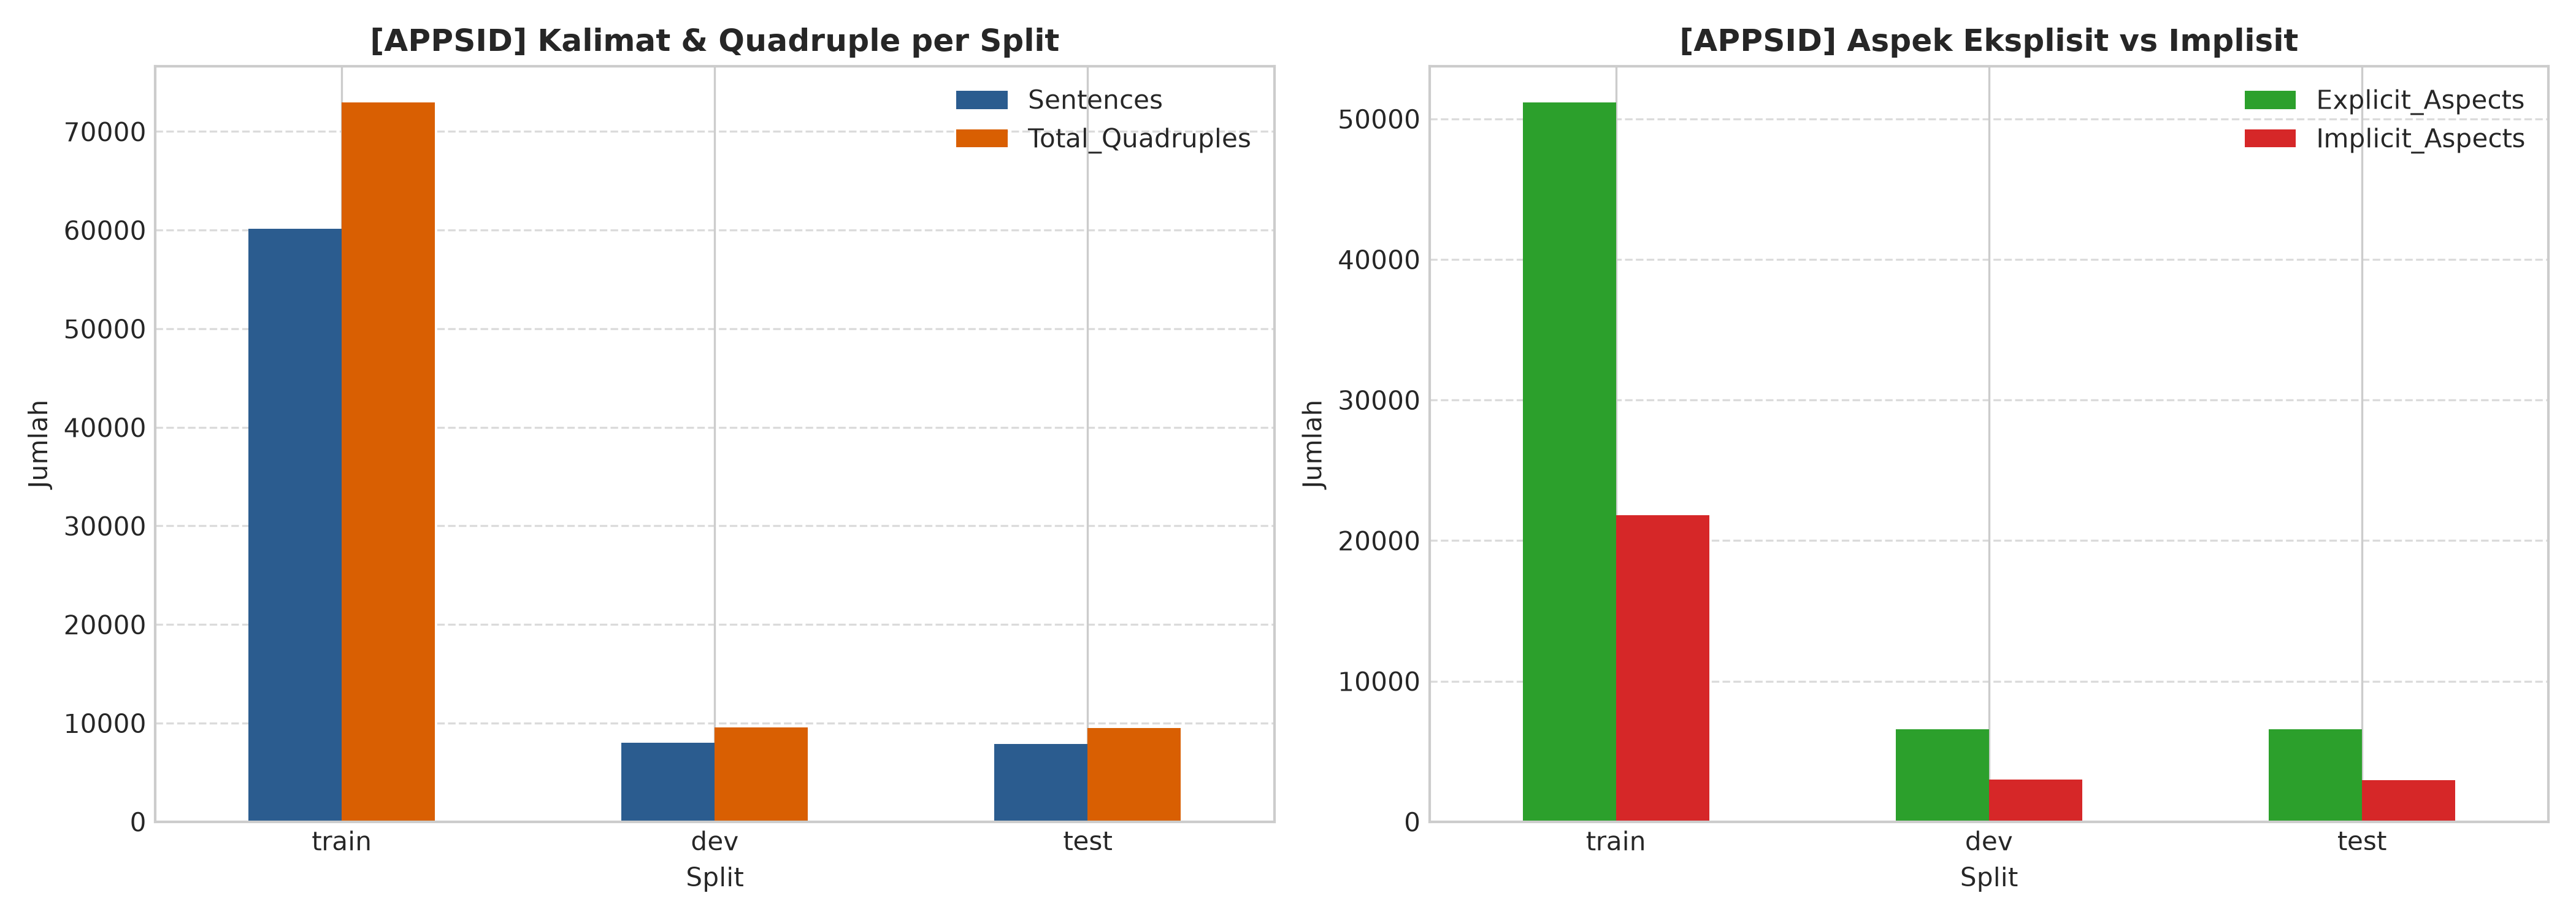

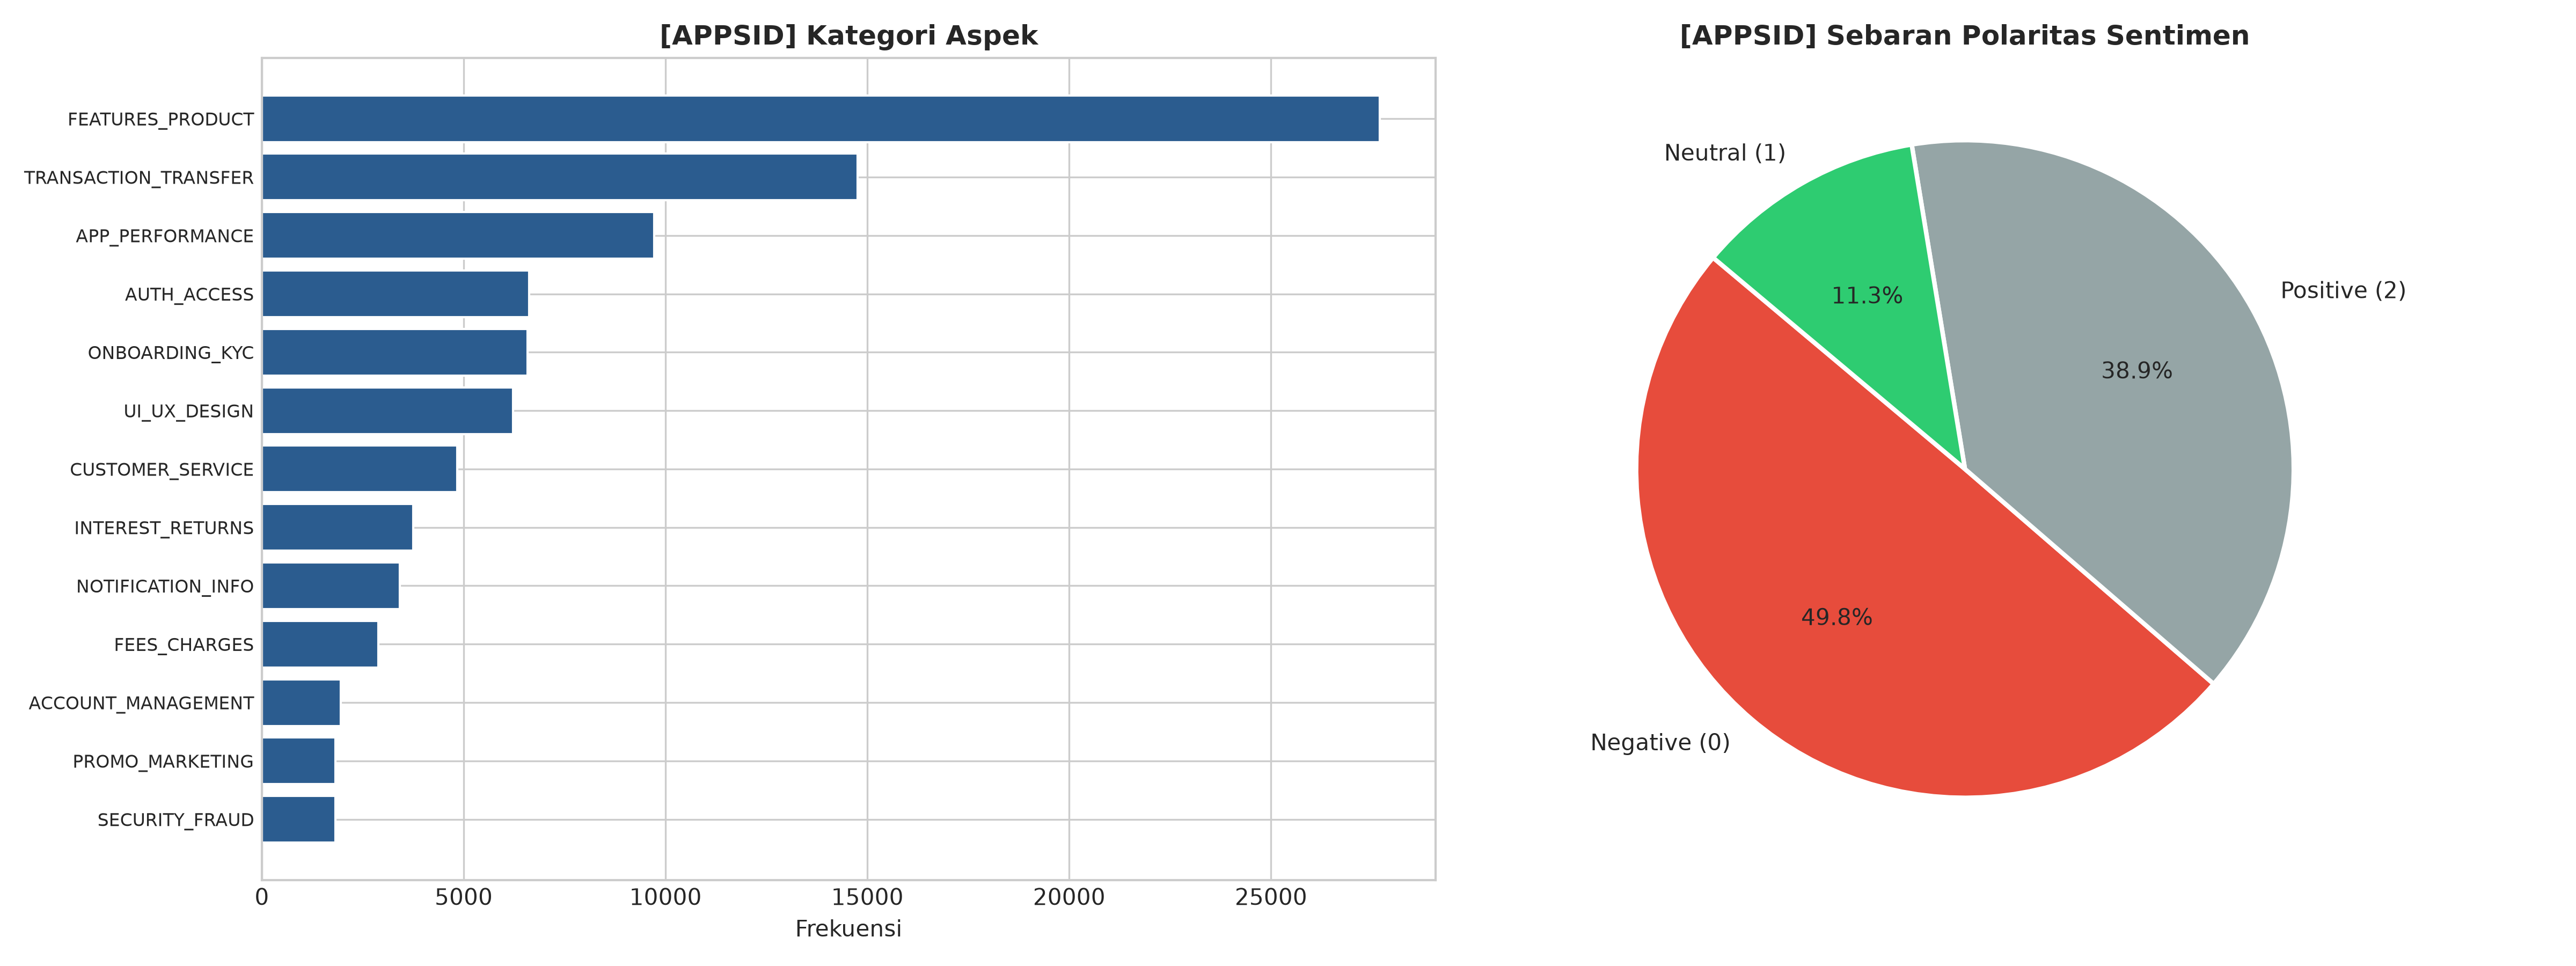

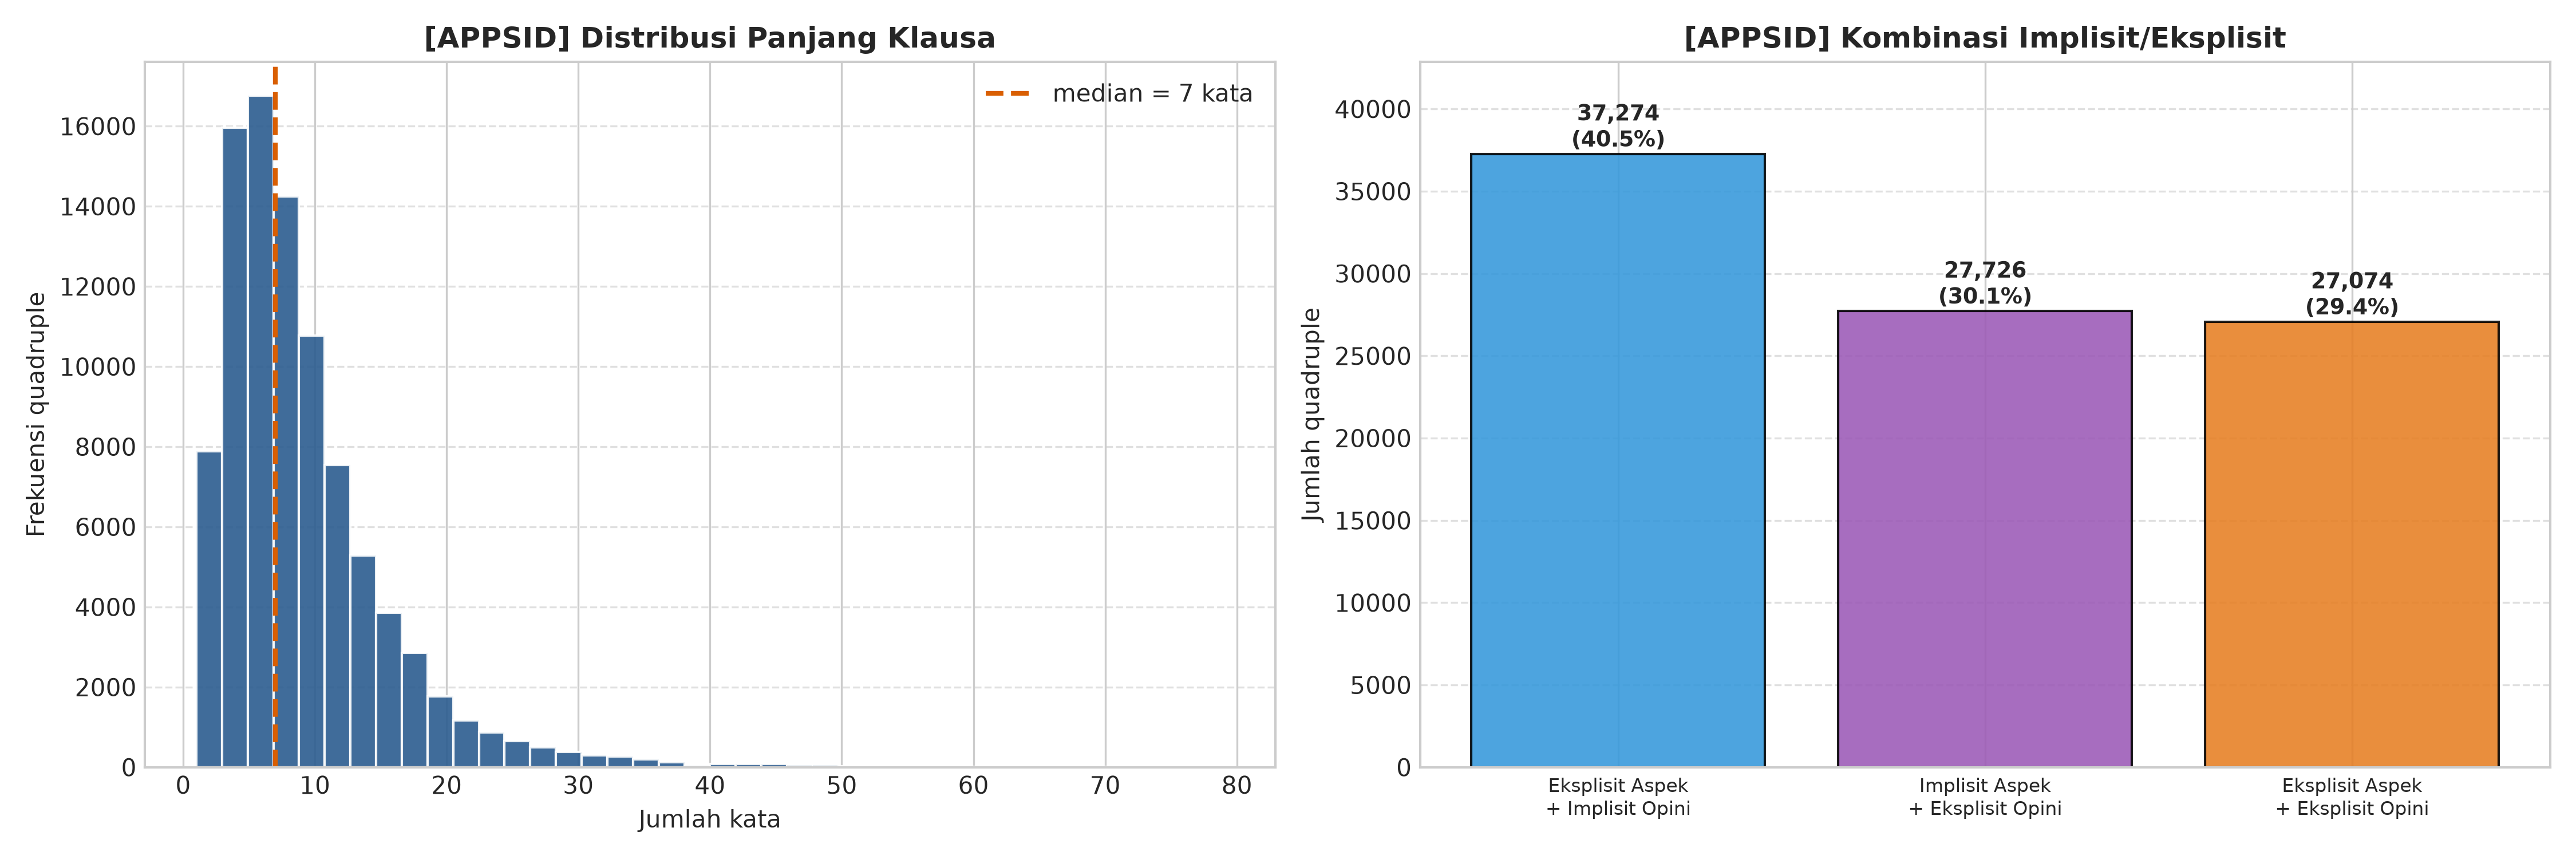

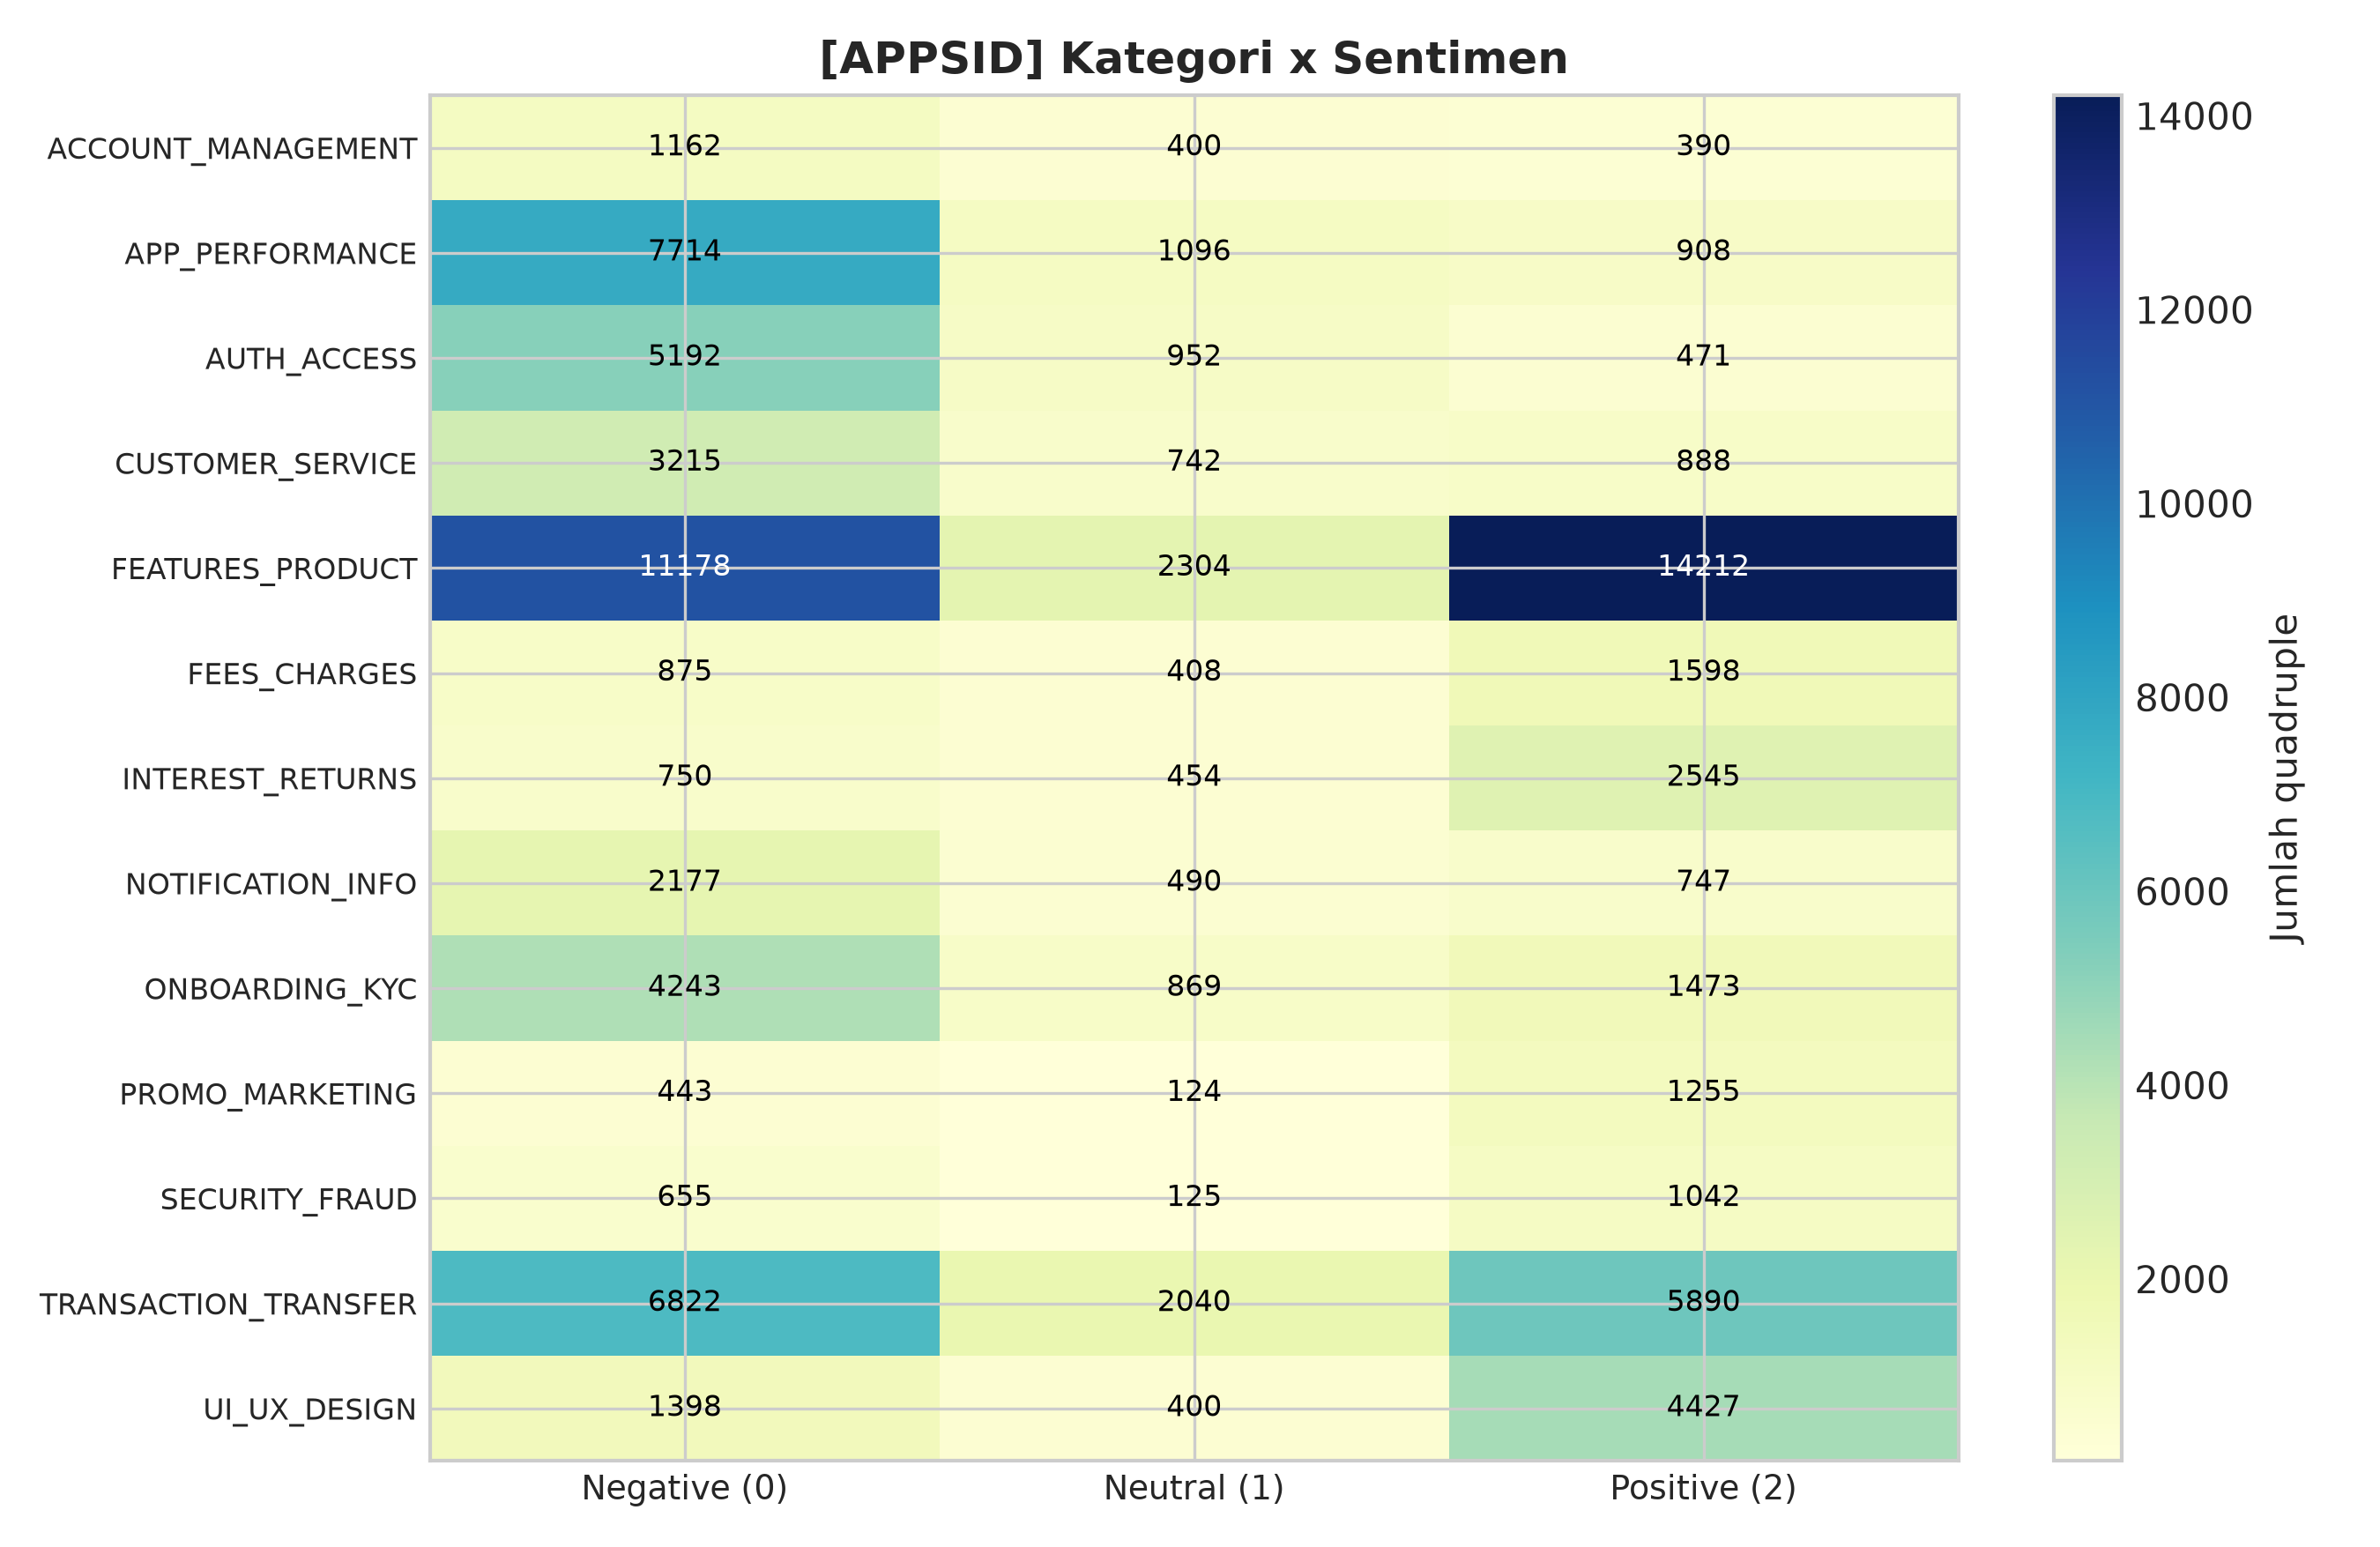

In [39]:

rep.section("2. Eksplorasi data")
if df_stats is None or df_stats.empty:
    print("⚠️ [Peringatan] Statistik EDA kosong: pastikan folder data/ tersedia.")
    rep.text("Statistik EDA kosong; folder `data/` tidak ditemukan.")
else:
    export_step_table(df_stats, name="master_01_statistik_dataset", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Statistik Dataset {DOMAIN.upper()} per Split")
    rep.table(df_stats, caption="Statistik per split")

    if 'df_records' in globals() and df_records is not None and not df_records.empty:
        n = len(df_records)
        df_ringkas = pd.DataFrame([{
            "Total_Quadruple": n,
            "Implicit_Aspect": int(df_records["Is_Implicit_Aspect"].sum()),
            "Implicit_Opinion": int(df_records["Is_Implicit_Opinion"].sum()),
            "Keduanya_Implicit": int((df_records["Is_Implicit_Aspect"] & df_records["Is_Implicit_Opinion"]).sum()),
            "Kategori_Unik": int(df_records["Category"].nunique()),
            "Panjang_Kalimat_Median": float(df_records["Text_Length"].median()),
        }])
        export_step_table(df_ringkas, name="master_02_ringkasan_eda", csv_dir=csv_dir, md_dir=md_dir,
                          title=f"Ringkasan EDA ({DOMAIN.upper()})")
        rep.table(df_ringkas, caption="Ringkasan EDA")

    from IPython.display import Image, display
    for fname, cap in [
        ("01_eda_dataset_distribution.png", "Komposisi dataset & explicit vs implicit"),
        ("02_eda_category_sentiment.png", "Kategori teratas & polaritas sentimen"),
        ("02b_eda_length_and_implicit_combo.png", "Panjang kalimat & kombinasi implicit"),
        ("02c_eda_category_sentiment_heatmap.png", "Heatmap kategori x sentimen"),
    ]:
        p = os.path.join(plots_dir, fname)
        if os.path.exists(p):
            display(Image(p))
            rep.image(p, cap)


In [40]:

tot_q = int(df_ringkas["Total_Quadruple"].values[0]) if ('df_ringkas' in globals() and not df_ringkas.empty) else 0
update_mcp_manifest("EDA_COMPLETED", 2, {"total_quadruples": tot_q})
save_pipeline_state()
print("✅ EDA selesai dan status disimpan ke pipeline_state.pkl.")

✅ EDA selesai dan status disimpan ke pipeline_state.pkl.


### 4b. Diagnostik Lokasi Dataset & Tokenized Data

In [41]:
# Diagnostik Struktur Folder Drive, Dataset, BERT Cache & Sesi Output
drive_audit_report = inspect_acos_drive_structure(base_project_dir=base_project_dir, domain=DOMAIN, verbose=True)


🔍 DIAGNOSTIK STRUKTUR FOLDER & ARTEFAK ACOS
📁 Root Direktori Proyek : /shared-docker/ACOS
🖥️  Lingkungan Runtime   : Lokal (Drive Mount: Tidak Aktif)

📂 Status Folder Utama:
   - Extract-Classify-ACOS : ✅ Ada (/shared-docker/ACOS/Extract-Classify-ACOS)
   - tokenized_data        : ✅ Ada (/shared-docker/ACOS/Extract-Classify-ACOS/tokenized_data)
   - data                  : ✅ Ada (/shared-docker/ACOS/data)
   - bert_cache            : ✅ Ada (/shared-docker/ACOS/bert_base_uncased)
   - Output                : ✅ Ada (/shared-docker/ACOS/Output)
   - results               : ❌ Belum Ada (/shared-docker/ACOS/Output/results)

📊 Status Dataset:
   - Restaurant-ACOS : ✅ Ada [train: rest16_quad_train.tsv (175.6 KB), dev: rest16_quad_dev.tsv (17.6 KB), test: rest16_quad_test.tsv (65.6 KB)]
   - Laptop-ACOS     : ✅ Ada [train: laptop_quad_train.tsv (351.0 KB), dev: laptop_quad_dev.tsv (38.0 KB), test: laptop_quad_test.tsv (95.5 KB)]

🧠 Pretrained BERT Cache: ✅ Lengkap (420.3 MB) di /shared-docker/

### 4c. Adapter Checkpoint IndoBERT

Menyiapkan `bert_cache_dir` berisi `config.json`, `pytorch_model.bin`, dan
`vocab.txt` IndoBERT, dengan state_dict yang sudah **direkey**: setiap key
diberi prefiks `bert.` agar cocok dengan `start_prefix=''` yang dipakai loader
legacy pada kelas yang punya atribut `self.bert`.

Sel ini harus berjalan **sebelum** gerbang data 4d, bukan sesudahnya: generator
`tokenized_data` memakai vocab IndoBERT, jadi gate `tokenized` tidak punya
tokenizer sebelum sel ini selesai.

Idempoten lewat penanda `_rekey.json` di folder yang sama. Penanda itu bukan
kenyamanan: menjalankan rekey dua kali menghasilkan `bert.bert.embeddings...`,
dan hasilnya sama buruknya dengan tidak merekey sama sekali.

Laporan vocab akan menunjukkan `config.vocab_size = 50000` sementara `vocab.txt`
berisi 30.521 token. Itu memang begitu untuk `indobert-base-p1` — matriks
embedding-nya benar-benar 50.000 baris dan id 30.521+ tidak pernah terpakai.
Jangan pernah memakai `config.vocab_size` sebagai jumlah token.

In [42]:
require_vars("step_stage", "acos_ckpt", "bert_cache_dir", "BACKBONE")

with step_stage("4c. Adapter checkpoint IndoBERT (rekey prefiks bert.)", 5) as st:
    if not acos_taxonomy.is_id_domain(DOMAIN):
        st.step(f"DOMAIN='{DOMAIN}' — memakai bert-base-uncased apa adanya, "
                f"adapter dilewati")
        backbone_report = {"dilewati": True}
    else:
        st.step(f"Backbone: {BACKBONE} → {acos_ckpt.BACKBONES[BACKBONE]['hf_id']}")
        st.step(f"Target   : {bert_cache_dir}")
        backbone_report = acos_ckpt.prepare_backbone(BACKBONE, bert_cache_dir)

        _rk = backbone_report["rekey"]
        if _rk.get("dilewati"):
            st.step(f"Rekey dilewati — {_rk['dilewati']}")
        else:
            st.step(f"Rekey: {_rk['n_diberi_prefiks']} dari {_rk['n_key']} key "
                    f"diberi prefiks 'bert.'")
        st.note(f"key sebelum: {_rk.get('key_sebelum')}")
        st.note(f"key sesudah: {_rk.get('key_sesudah')}")

        _v = backbone_report["vocab"]
        st.step(f"config.vocab_size={_v.get('config_vocab_size')} | "
                f"vocab.txt={_v.get('vocab_lines')} token | "
                f"hidden={_v.get('hidden_size')} × {_v.get('num_hidden_layers')} layer")
        if not _v.get("konsisten", True):
            st.note(f"⚠️ selisih {_v.get('selisih')} — normal untuk indobert-base-p1; "
                    f"rujuk vocab.txt, JANGAN config.vocab_size")

        df_backbone = pd.DataFrame([{
            "Backbone": BACKBONE,
            "HF_ID": acos_ckpt.BACKBONES[BACKBONE]["hf_id"],
            "Key_Total": _rk.get("n_key"),
            "Key_Diberi_Prefiks": _rk.get("n_diberi_prefiks"),
            "Key_Berprefiks_bert": _rk.get("n_key_berprefiks_bert"),
            "Config_Vocab_Size": _v.get("config_vocab_size"),
            "Vocab_Txt_Token": _v.get("vocab_lines"),
            "Hidden_Size": _v.get("hidden_size"),
            "Layer": _v.get("num_hidden_layers"),
        }])
        export_step_table(df_backbone, name="master_00_backbone_indobert",
                          csv_dir=csv_dir, md_dir=md_dir,
                          title="Adapter Checkpoint IndoBERT")
        rep.section("1b. Backbone & gerbang data")
        rep.table(df_backbone, caption="Backbone & hasil rekey")

        with open(os.path.join(session_dirs["logs"], "backbone_report.json"),
                  "w", encoding="utf-8") as jf:
            json.dump(backbone_report, jf, indent=2, ensure_ascii=False, default=str)
        st.step("backbone_report.json tersimpan; Gate 1 numerik menyusul di sel 5d2")

▶️  4c. Adapter checkpoint IndoBERT (rekey prefiks bert.)
   [1/5]    0.0s  Backbone: indobert → indobenchmark/indobert-base-p1
   [2/5]    0.0s  Target   : /shared-docker/ACOS/ACOS-IndoBERT/backbones/indobert_base_p1
   [3/5]    0.0s  Rekey dilewati — penanda _rekey.json sudah ada
        key sebelum: ['embeddings.word_embeddings.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight']
        key sesudah: ['bert.embeddings.word_embeddings.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight']
   [4/5]    0.0s  config.vocab_size=50000 | vocab.txt=30521 token | hidden=768 × 12 layer
        ⚠️ selisih 19479 — normal untuk indobert-base-p1; rujuk vocab.txt, JANGAN config.vocab_size
=== Adapter Checkpoint IndoBERT (1 baris) ===


,Backbone,HF_ID,Key_Total,Key_Diberi_Prefiks,Key_Berprefiks_bert,Config_Vocab_Size,Vocab_Txt_Token,Hidden_Size,Layer
0,indobert,indobenchmark/indobert-base-p1,199,199,199,50000,30521,768,12


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_00_backbone_indobert.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_00_backbone_indobert.md
   [5/5]    0.0s  backbone_report.json tersimpan; Gate 1 numerik menyusul di sel 5d2
✅ 4c. Adapter checkpoint IndoBERT (rekey prefiks bert.) — selesai dalam 0.0s



### 4d. Gerbang Data Indonesia (wajib sebelum training)

Lima gerbang, semuanya torch-free, dijalankan berurutan. Kalau ada yang merah sel
ini melempar exception alih-alih melanjutkan — setiap kegagalan di sini tidak
terlihat dari kurva loss maupun metrik training.

| Gate | Yang diperiksa | Kalau gagal |
|---|---|---|
| `taxonomy` | 13 kategori di kode == `label_maps.json`, **urutan sama** | indeks head Step 2 bergeser, seluruh prediksi kategori salah |
| `dataset` | berkas sumber ada; `review_id` train/dev/test saling lepas | kebocoran data, angka test terlalu tinggi |
| `acos_build` | `appsid_quad_*.tsv` terbentuk; tiap span menunjuk token nyata | span rusak jadi label `O`, aspek hilang tanpa pesan |
| `tokenized` | retokenisasi WordPiece tidak menghilangkan satu tuple pun | data training menyusut senyap |
| `gate2_english` | regenerasi data Inggris **identik** dengan `tokenized_data/` di repo | konvensi offset generator salah; ini satu-satunya bukti eksternalnya |

`tokenized` memakai vocab IndoBERT dari sel 4c, jadi 4c harus sudah selesai.

`gate2_english` memberi toleransi satu kalimat pada `rest16_train_pair.tsv`.
Itu cacat data upstream: `rest16_quad_train.tsv` baris 451 memuat span opini
lebar-nol `3,3`, dan berkas repo memetakan baris itu tidak konsisten antara
`*_quad_bert.tsv` (`3,4`) dan `*_pair.tsv` (`3,5`, plus satu pasangan hilang).
Generator mengikuti berkas quad, yang dipakai Step 1.

In [43]:
require_vars("step_stage", "acos_selftest", "acos_taxonomy", "DOMAIN")

# Set True untuk membangun ulang berkas ACOS & tokenized_data dari nol.
FORCE_REBUILD_ID_DATA = False

with step_stage("4d. Gerbang data Indonesia (5 gate torch-free)", 6) as st:
    if not acos_taxonomy.is_id_domain(DOMAIN):
        st.step(f"DOMAIN='{DOMAIN}' bukan domain Indonesia — seluruh gate dilewati")
        st.note("Notebook berjalan sebagai kontrol Inggris; sel 4c & 5d2 juga "
                "melewati dirinya sendiri.")
        id_gate_results = {}
    else:
        if not os.path.exists(os.path.join(bert_cache_dir, "vocab.txt")):
            raise RuntimeError(
                f"vocab.txt belum ada di {bert_cache_dir}. Jalankan sel 4c "
                f"(adapter checkpoint IndoBERT) lebih dulu — generator "
                f"tokenized_data memakai vocab itu.")

        # default_paths() menurunkan seluruh path dari dua root; yang ditimpa di
        # sini hanya bert_cache_dir (nama folder tergantung BACKBONE) dan
        # work_dir (keluaran gate 2 disimpan di folder sesi, bukan build/).
        _paths = acos_selftest.default_paths(indo_root, acos_root)
        _paths["bert_cache_dir"] = bert_cache_dir
        _paths["work_dir"] = os.path.join(session_dirs["logs"], "gates")
        st.step(f"Sumber data   : {_paths['data_root']}")
        st.step(f"Vocab IndoBERT: {_paths['bert_cache_dir']}")
        st.note(f"tokenized_data → {_paths['tokenized_dir']}")
        st.note(f"upstream (baca) → {_paths['extract_dir']}")

        # Gate 2 membandingkan dengan berkas Inggris di repo, jadi butuh vocab
        # bert-base-uncased. Diunduh di sini kalau belum ada; ukurannya 232 KB
        # (hanya vocab.txt, bukan pytorch_model.bin).
        if not os.path.exists(os.path.join(_paths["en_vocab_dir"], "vocab.txt")):
            os.makedirs(_paths["en_vocab_dir"], exist_ok=True)
            import urllib.request
            urllib.request.urlretrieve(
                "https://huggingface.co/bert-base-uncased/resolve/main/vocab.txt",
                os.path.join(_paths["en_vocab_dir"], "vocab.txt"))
            st.note("vocab.txt bert-base-uncased diunduh untuk gate 2")

        id_gate_results = acos_selftest.run_gates(
            paths=_paths, only=acos_selftest.TORCH_FREE_GATES,
            rebuild=FORCE_REBUILD_ID_DATA, raise_on_fail=True, verbose=True)
        st.step(f"{len(id_gate_results)} gate dijalankan, semuanya hijau")

        _b = id_gate_results["acos_build"]["detail"]["per_split"]
        _t = id_gate_results["tokenized"]["detail"]["per_split"]
        df_id_gates = pd.DataFrame([
            {"Split": s,
             "Baris_ACOS": _b[s].get("baris", 0),
             "Quad_ACOS": _b[s].get("quad", 0),
             "Quad_Tokenized": _t[s].get("quad", 0),
             "Quad_Hilang": _t[s].get("quad_hilang", 0),
             "Aspek_Eksplisit": _t[s].get("aspek_eksplisit", 0),
             "Aspek_Implisit": _t[s].get("aspek_implisit", 0),
             "Opini_Eksplisit": _t[s].get("opini_eksplisit", 0),
             "Opini_Implisit": _t[s].get("opini_implisit", 0)}
            for s in ("train", "dev", "test") if s in _b and s in _t])
        export_step_table(df_id_gates, name="master_00b_gerbang_data_id",
                          csv_dir=csv_dir, md_dir=md_dir,
                          title="Gerbang Data Indonesia (Apps-ACOS)")
        rep.table(df_id_gates, caption="Konversi & retokenisasi per split")
        st.step("Tabel master_00b ditulis")

        _gate_json = os.path.join(session_dirs["logs"], "id_gates.json")
        with open(_gate_json, "w", encoding="utf-8") as jf:
            json.dump({k: {"ok": v["ok"], "detail": v["detail"]}
                       for k, v in id_gate_results.items()},
                      jf, indent=2, ensure_ascii=False, default=str)
        st.step(f"Hasil gate → {_gate_json}")
        update_mcp_manifest("ID_DATA_GATES_PASSED", 1,
                            {"n_gate": len(id_gate_results),
                             "num_labels_step2": acos_taxonomy.num_labels_step2()})

▶️  4d. Gerbang data Indonesia (5 gate torch-free)
   [1/6]    0.0s  Sumber data   : /shared-docker/ACOS/ACOS-IndoBERT/data
   [2/6]    0.0s  Vocab IndoBERT: /shared-docker/ACOS/ACOS-IndoBERT/backbones/indobert_base_p1
        tokenized_data → /shared-docker/ACOS/ACOS-IndoBERT/tokenized_data
        upstream (baca) → /shared-docker/ACOS/Extract-Classify-ACOS
✅ gate taxonomy
✅ gate dataset
✅ gate acos_build
✅ gate tokenized
✅ gate gate2_english
   [3/6]    0.9s  5 gate dijalankan, semuanya hijau
=== Gerbang Data Indonesia (Apps-ACOS) (3 baris) ===


,Split,Baris_ACOS,Quad_ACOS,Quad_Tokenized,Quad_Hilang,Aspek_Eksplisit,Aspek_Implisit,Opini_Eksplisit,Opini_Implisit
0,train,60159,72973,72973,0,51184,21789,43271,29702
1,dev,8027,9587,9587,0,6588,2999,5836,3751
2,test,7891,9514,9514,0,6576,2938,5693,3821


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_00b_gerbang_data_id.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_00b_gerbang_data_id.md
   [4/6]    0.9s  Tabel master_00b ditulis
   [5/6]    0.9s  Hasil gate → /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs/id_gates.json
✅ 4d. Gerbang data Indonesia (5 gate torch-free) — selesai dalam 0.9s



## 5. Step 1: Aspect & Opinion Co-Extraction (BERT-CRF)
Tahap ini dipecah menjadi enam sel (5a-5f) agar setiap bagian punya progres dan durasi sendiri,
sehingga kegagalan atau kelambatan bisa dilacak ke satu tahap saja. Jalankan berurutan.

| Sel | Isi | Aman diulang |
|---|---|---|
| 5a | Import, tokenizer, label map, resolusi path checkpoint | ya |
| 5b | Deteksi cache (sesi aktif + sesi lama), keputusan latih/lewati | ya |
| 5c | Data evaluasi + ground truth (`eval_gold_1`) | ya |
| 5d | Instansiasi model, data training, optimizer | ya (mengalokasi ulang VRAM) |
| 5e | Loop training per epoch + checkpoint terbaik | tidak (melatih ulang) |
| 5f | Plot, tabel laporan, manifest, simpan state | ya |

Sel 5c-5e melewati dirinya sendiri secara otomatis saat `STEP1_SKIP_TRAINING` bernilai `True`.
Set `FORCE_RETRAIN_STEP1 = True` di sel 5a untuk memaksa training ulang.

In [44]:
from modeling import BertForQuadABSA
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes
from eval_metrics import pred_eval
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from tqdm.auto import tqdm
import time


In [45]:
require_vars("step_stage", "session_dirs", "bert_cache_dir", "DOMAIN")

from modeling import BertForQuadABSA
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes
from eval_metrics import pred_eval
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from tqdm.auto import tqdm

# Toggle Melatih Ulang (Set True jika ingin melatih ulang dari awal)
FORCE_RETRAIN_STEP1 = False

with step_stage("5a. Inisialisasi Step 1: tokenizer, patch metrik, taksonomi ID, label, path", 7) as st:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            _vram_txt = f"VRAM bebas {torch.cuda.mem_get_info()[0] / 1024 ** 3:.2f} GB"
        except Exception:  # mem_get_info tidak ada di torch lama
            _vram_txt = (f"VRAM total "
                         f"{torch.cuda.get_device_properties(0).total_memory / 1024 ** 3:.2f} GB")
        st.step(f"GPU siap: {torch.cuda.get_device_name(0)} | {_vram_txt}")
    else:
        st.step("Mode CPU aktif (CUDA tidak tersedia) — training akan jauh lebih lambat")

    tokenizer = BertTokenizer.from_pretrained(bert_cache_dir, do_lower_case=True)
    st.step(f"Tokenizer dimuat: {len(tokenizer.vocab):,} entri vocab dari {bert_cache_dir}")

    _em1 = patch_eval_metrics_counts()
    st.step("eval_metrics dipatch: measureQuad & measureQuad_imp kini mengembalikan "
            "tp/fp/fn (+ agregat semua slot difficulty)")

    # Domain Indonesia: get_labels() upstream hanya mengenal 'rest*' dan 'laptop';
    # domain lain membiarkan daftar kategori None lalu meledak di `for cate in l`.
    # Patch runtime menambah cabangnya tanpa menyentuh berkas upstream, sehingga
    # jalur Inggris tetap utuh sebagai kontrol.
    _lab_patch = acos_taxonomy.patch_processor_labels(processors)
    st.step(f"Taksonomi Indonesia: {_lab_patch}")

    processor_step1 = processors["quad"]()
    label_list_step1 = processor_step1.get_labels(DOMAIN)
    num_labels_step1 = len(label_list_step1[1])
    label_map_seq = {label: i for i, label in enumerate(label_list_step1[1])}
    st.step(f"Label sekuens ({num_labels_step1}): {label_list_step1[1]}")

    step1_ckpt = session_dirs["step1_checkpoint"]
    step1_bin = os.path.join(step1_ckpt, "pytorch_model.bin")
    step1_csv = os.path.join(session_dirs["csv"], "step1_training_history.csv")
    pred_file = os.path.join(session_dirs["logs"], "pred4pipeline.txt")
    step1_progress_json = os.path.join(session_dirs["logs"], "step1_progress.json")
    os.makedirs(step1_ckpt, exist_ok=True)
    st.step(f"Checkpoint  : {step1_ckpt}")
    st.step(f"Prediksi    : {pred_file} | FORCE_RETRAIN_STEP1={FORCE_RETRAIN_STEP1} | "
            f"epoch target={NUM_EPOCHS}")

▶️  5a. Inisialisasi Step 1: tokenizer, patch metrik, taksonomi ID, label, path
   [1/7]    0.0s  GPU siap: AMD Instinct MI300X VF | VRAM bebas 184.65 GB
   [2/7]    0.0s  Tokenizer dimuat: 30,521 entri vocab dari /shared-docker/ACOS/ACOS-IndoBERT/backbones/indobert_base_p1
   [3/7]    0.0s  eval_metrics dipatch: measureQuad & measureQuad_imp kini mengembalikan tp/fp/fn (+ agregat semua slot difficulty)
   [4/7]    0.0s  Taksonomi Indonesia: {'patched': True, 'domain': 'appsid', 'num_labels_step1': 6, 'num_labels_step2': 39}
   [5/7]    0.0s  Label sekuens (6): ['[CLS]', 'O', 'I-A', 'B-A', 'I-O', 'B-O']
   [6/7]    0.0s  Checkpoint  : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/checkpoints/step1_best
   [7/7]    0.0s  Prediksi    : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs/pred4pipeline.txt | FORCE_RETRAIN_STEP1=False | epoch target=50
✅ 5a. Inisialisasi Step 1: tokenizer, patch metrik, taksonomi ID, label, path — selesai dalam 0.0s



### 5b. Deteksi Cache Step 1
Memeriksa artefak sesi aktif, lalu menarik checkpoint dari sesi lama bila perlu.
Hasilnya adalah `STEP1_SKIP_TRAINING`, satu-satunya penentu apakah sel 5c-5e berjalan.

In [46]:
require_vars("step_stage", "step1_bin", "pred_file", "step1_csv", "FORCE_RETRAIN_STEP1")

with step_stage("5b. Deteksi cache Step 1 (sesi aktif lalu sesi lama)", 4) as st:
    step1_already_done = os.path.exists(step1_bin) and os.path.exists(pred_file)
    st.step("Sesi aktif — model: {} | pred4pipeline: {}".format(
        f"{os.path.getsize(step1_bin) / 1024 ** 2:.1f} MB" if os.path.exists(step1_bin) else "belum ada",
        f"{sum(1 for _ in open(pred_file, encoding='utf-8'))} baris" if os.path.exists(pred_file) else "belum ada"))

    if step1_already_done:
        st.step("Pencarian sesi lama dilewati (artefak sesi aktif sudah lengkap)")
    else:
        found_bin = auto_find_file("pytorch_model.bin", must_contain="step1_best", search_roots=[
            results_base if 'results_base' in globals() else "",
            "/content/drive/MyDrive/ACOS/Output/results",
            os.path.join(base_project_dir, "Output", "results"),
        ])
        if found_bin and "step1_best" in found_bin:
            src_dir = os.path.dirname(found_bin)
            st.step(f"Checkpoint sesi sebelumnya ditemukan: {src_dir}")
            for fn in ["pytorch_model.bin", "config.json", "vocab.txt"]:
                fp = os.path.join(src_dir, fn)
                if os.path.exists(fp):
                    shutil.copy(fp, os.path.join(step1_ckpt, fn))
                    st.note(f"↪ {fn} ({os.path.getsize(fp) / 1024 ** 2:.1f} MB) disalin ke sesi aktif")
            found_pred = auto_find_file("pred4pipeline.txt")
            if found_pred:
                shutil.copy(found_pred, pred_file)
                st.note(f"↪ pred4pipeline.txt disalin dari {found_pred}")
            found_csv = auto_find_file("step1_training_history.csv")
            if found_csv:
                shutil.copy(found_csv, step1_csv)
                st.note(f"↪ step1_training_history.csv disalin dari {found_csv}")
            step1_already_done = os.path.exists(step1_bin) and os.path.exists(pred_file)
        else:
            st.step("Tidak ada checkpoint step1_best di sesi mana pun")

    STEP1_SKIP_TRAINING = (not FORCE_RETRAIN_STEP1) and step1_already_done
    st.step("Keputusan: " + ("CACHE HIT → sel 5c-5e dilewati"
                             if STEP1_SKIP_TRAINING else
                             f"TRAINING dijalankan ({NUM_EPOCHS} epoch)"))

    if STEP1_SKIP_TRAINING:
        print(f"⏩ [CACHE HIT] Model Step 1 : {step1_ckpt}")
        print(f"⏩ [CACHE HIT] Prediksi     : {pred_file}")
        if os.path.exists(step1_csv):
            df_s1_saved = pd.read_csv(step1_csv)
            step1_history = df_s1_saved.to_dict('records')
            _row_c1, best_step1_f1, best1_epoch = best_epoch_row(step1_history)
            best1_epoch = best1_epoch or NUM_EPOCHS
            st.step(f"Riwayat tersimpan: {len(df_s1_saved)} epoch, terbaik epoch {best1_epoch}")
            if len(df_s1_saved) < NUM_EPOCHS:
                st.note(f"⚠️ Riwayat hanya {len(df_s1_saved)}/{NUM_EPOCHS} epoch — checkpoint ini "
                        f"berasal dari run yang terhenti. Set FORCE_RETRAIN_STEP1=True bila "
                        f"ingin melatih penuh.")
        else:
            step1_history = []
            best_step1_f1 = 0.0
            best1_epoch = NUM_EPOCHS
            st.step("Riwayat CSV tidak ada — metrik per epoch tidak bisa dilaporkan")
# ── Resume Epoch: cek apakah training Step 1 terhenti di tengah jalan ────────
step1_resume_json = os.path.join(session_dirs["logs"], "step1_resume.json")
STEP1_RESUME_EPOCH = 0  # epoch terakhir yang selesai (0 = belum ada / baru)

if (not STEP1_SKIP_TRAINING) and (not FORCE_RETRAIN_STEP1):
    if not os.path.exists(step1_resume_json):
        _found_resume = auto_find_file("step1_resume.json", search_roots=[
            results_base if 'results_base' in globals() else "",
            "/content/drive/MyDrive/ACOS/Output/results",
            os.path.join(base_project_dir, "Output", "results"),
        ])
        if _found_resume and os.path.exists(_found_resume):
            try:
                _rj_prev = json.load(open(_found_resume, encoding="utf-8"))
                _last_prev = int(_rj_prev.get("last_completed_epoch", 0))
                _prev_session_root = os.path.dirname(os.path.dirname(_found_resume))
                _prev_epoch_dir = os.path.join(_prev_session_root, "checkpoints", f"step1_epoch_{_last_prev}")
                if os.path.isdir(_prev_epoch_dir):
                    _tgt_epoch_dir = os.path.join(session_dirs["checkpoints"], f"step1_epoch_{_last_prev}")
                    os.makedirs(_tgt_epoch_dir, exist_ok=True)
                    for _f in os.listdir(_prev_epoch_dir):
                        shutil.copy(os.path.join(_prev_epoch_dir, _f), os.path.join(_tgt_epoch_dir, _f))
                    shutil.copy(_found_resume, step1_resume_json)
                    print(f"↪ [RESUME] Menyalin resume checkpoint dari sesi lama: epoch {_last_prev}")
            except Exception as _e_copy:
                print(f"⚠️ Gagal menyalin resume dari sesi lama: {_e_copy}")

    if os.path.exists(step1_resume_json):
        try:
            _rj = json.load(open(step1_resume_json, encoding="utf-8"))
            _last = int(_rj.get("last_completed_epoch", 0))
            _total = int(_rj.get("total_epochs", NUM_EPOCHS))
            _epoch_ckpt_check = os.path.join(
                session_dirs["checkpoints"], f"step1_epoch_{_last}")
            _epoch_bin_check  = os.path.join(_epoch_ckpt_check, "pytorch_model.bin")
            if _total != NUM_EPOCHS:
                print(f"⚠️  [RESUME] NUM_EPOCHS berubah ({_total}→{NUM_EPOCHS}). "
                      f"Resume diabaikan — training dari awal.")
            elif _last > 0 and _last < NUM_EPOCHS and os.path.exists(_epoch_bin_check):
                STEP1_RESUME_EPOCH = _last
                print(f"♻️  [RESUME] Step 1 terhenti di epoch {_last}/{NUM_EPOCHS}. "
                      f"Akan dilanjutkan dari epoch {_last + 1}.")
            elif _last >= NUM_EPOCHS:
                print(f"✅ [RESUME] step1_resume.json menunjukkan training sudah "
                      f"selesai ({_last}/{NUM_EPOCHS} epoch).")
        except Exception as _re:
            print(f"⚠️  Tidak bisa membaca step1_resume.json: {_re}. Training dari awal.")

elif STEP1_SKIP_TRAINING:
    if os.path.exists(step1_resume_json):
        try:
            _rj_info = json.load(open(step1_resume_json, encoding="utf-8"))
            _ep_info = _rj_info.get("last_completed_epoch", "?")
            print(f"ℹ️  step1_resume.json ada (epoch {_ep_info}/{NUM_EPOCHS}) "
                  f"— diabaikan karena cache hit sudah lengkap.")
        except Exception:
            pass

if STEP1_RESUME_EPOCH > 0:
    STEP1_SKIP_TRAINING = False  # paksa jalankan training (lanjut dari epoch berikutnya)
    print(f"   → STEP1_SKIP_TRAINING di-override: training akan lanjut dari "
          f"epoch {STEP1_RESUME_EPOCH + 1}.")

▶️  5b. Deteksi cache Step 1 (sesi aktif lalu sesi lama)
   [1/4]    0.0s  Sesi aktif — model: 477.1 MB | pred4pipeline: 7386 baris
   [2/4]    0.0s  Pencarian sesi lama dilewati (artefak sesi aktif sudah lengkap)
   [3/4]    0.0s  Keputusan: CACHE HIT → sel 5c-5e dilewati
⏩ [CACHE HIT] Model Step 1 : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/checkpoints/step1_best
⏩ [CACHE HIT] Prediksi     : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs/pred4pipeline.txt
   [4/4]    0.0s  Riwayat tersimpan: 3 epoch, terbaik epoch 3
        ⚠️ Riwayat hanya 3/50 epoch — checkpoint ini berasal dari run yang terhenti. Set FORCE_RETRAIN_STEP1=True bila ingin melatih penuh.
✅ 5b. Deteksi cache Step 1 (sesi aktif lalu sesi lama) — selesai dalam 0.0s

ℹ️  step1_resume.json ada (epoch 3/50) — diabaikan karena cache hit sudah lengkap.


### 5c. Data Evaluasi & Ground Truth
Membangun `eval_loader_1` dan `eval_gold_1`. `eval_gold_1` memakai `aspect_input_ids` hasil
fitur, bukan id token mentah; memakai id mentah menggeser teks `pred4pipeline.txt` satu token
dan mengosongkan kalimat satu kata.

In [47]:
require_vars("step_stage", "STEP1_SKIP_TRAINING", "label_map_seq", "tokenizer")

if STEP1_SKIP_TRAINING:
    print("⏩ 5c dilewati — memakai artefak Step 1 dari cache (lihat sel 5b).")
else:
    with step_stage("5c. Data evaluasi test + ground truth", 5) as st:
        eval_examples_1 = processor_step1.get_dev_examples(tokenized_base, DOMAIN)
        st.step(f"{len(eval_examples_1):,} contoh test dibaca dari "
                f"tokenized_data/{DOMAIN}_test_quad_bert.tsv")

        eval_features_1 = features_step1(eval_examples_1, label_list_step1, MAX_SEQ_LENGTH,
                                         tokenizer, output_modes["quad"], "quad")
        st.step(f"{len(eval_features_1):,} fitur dibentuk (max_seq_length={MAX_SEQ_LENGTH})")

        ev_ids = torch.tensor([f.aspect_input_ids for f in eval_features_1], dtype=torch.long)
        ev_mask = torch.tensor([f.aspect_input_mask for f in eval_features_1], dtype=torch.long)
        ev_seg = torch.tensor([f.aspect_segment_ids for f in eval_features_1], dtype=torch.long)
        ev_lbl = torch.tensor([f.aspect_ids for f in eval_features_1], dtype=torch.long)
        ev_imp_a = torch.tensor([f.exist_imp_aspect for f in eval_features_1], dtype=torch.long)
        ev_imp_o = torch.tensor([f.exist_imp_opinion for f in eval_features_1], dtype=torch.long)
        ev_len = torch.tensor([f.tokens_len for f in eval_features_1], dtype=torch.long)
        eval_data_1 = TensorDataset(ev_len, ev_ids, ev_mask, ev_lbl, ev_seg, ev_imp_a, ev_imp_o)

        pin_mem = torch.cuda.is_available()
        num_work = 0 if sys.platform.startswith('win') else 2
        eval_loader_1 = DataLoader(
            eval_data_1, sampler=SequentialSampler(eval_data_1),
            batch_size=16, pin_memory=pin_mem, num_workers=num_work
        )
        st.step(f"eval_loader_1 siap: {len(eval_loader_1)} batch × 16 "
                f"(pin_memory={pin_mem}, workers={num_work})")

        # Ground truth: input_text wajib memakai aspect_input_ids hasil feature
        # ([CLS] .. [CLS] + zero-pad). pred_eval menulis pred4pipeline.txt dari
        # ids_to_token[1:tokens_len-1]; id token mentah menggeser teks satu token.
        gold_tsv = os.path.join(tokenized_base, "tokenized_data", f"{DOMAIN}_test_quad_bert.tsv")
        with open(gold_tsv, "r", encoding="utf-8") as f:
            gold_lines = f.readlines()

        eval_gold_labels = []
        n_imp_a = n_imp_o = 0
        for line in tqdm(gold_lines, desc="   Parsing gold quad", unit="baris", leave=False):
            line = line.strip().split("\t")
            aspect_labels = [label_map_seq['O'] for _ in range(MAX_SEQ_LENGTH)]
            cur_imp_a, cur_imp_o = 0, 0
            for quad in line[1:]:
                cur_aspect, cur_opinion = quad.split(' ')[0], quad.split(' ')[-1]
                a_st, a_ed = int(cur_aspect.split(',')[0]), int(cur_aspect.split(',')[1])
                if a_ed != -1:
                    aspect_labels[a_st] = label_map_seq['B-A']
                    for i in range(a_st + 1, a_ed):
                        aspect_labels[i] = label_map_seq['I-A']
                else:
                    cur_imp_a = 1
                o_st, o_ed = int(cur_opinion.split(',')[0]), int(cur_opinion.split(',')[1])
                if o_ed != -1:
                    aspect_labels[o_st] = label_map_seq['B-O']
                    for i in range(o_st + 1, o_ed):
                        aspect_labels[i] = label_map_seq['I-O']
                else:
                    cur_imp_o = 1
            eval_gold_labels += [aspect_labels, cur_imp_a, cur_imp_o]
            n_imp_a += cur_imp_a
            n_imp_o += cur_imp_o
        st.step(f"Gold terbentuk untuk {len(gold_lines):,} kalimat "
                f"(implicit aspect: {n_imp_a}, implicit opinion: {n_imp_o})")

        eval_gold_1 = [ev_ids.numpy().tolist(), eval_gold_labels]
        assert len(eval_gold_labels) == 3 * len(eval_features_1), (
            f"Gold ({len(eval_gold_labels) // 3} kalimat) tidak sejajar dengan fitur "
            f"({len(eval_features_1)}). pred_eval akan salah memetakan prediksi.")
        st.step("eval_gold_1 sejajar dengan eval_loader_1 — siap dipakai pred_eval")

⏩ 5c dilewati — memakai artefak Step 1 dari cache (lihat sel 5b).


### 5d. Model, Data Training & Optimizer
Mengalokasikan VRAM untuk `BertForQuadABSA` dan menyiapkan `BertAdam`.
Jalankan ulang sel ini bila ingin mereset bobot ke pretrained sebelum melatih lagi.

In [48]:
require_vars("step_stage", "STEP1_SKIP_TRAINING")

if STEP1_SKIP_TRAINING:
    print("⏩ 5d dilewati — model dan optimizer tidak diperlukan saat cache hit.")
else:
    require_vars("eval_loader_1", "eval_gold_1")
    with step_stage("5d. Model BERT-CRF, data training, optimizer", 5) as st:
        model_step1 = BertForQuadABSA.from_pretrained(
            bert_cache_dir, num_labels=num_labels_step1).to(device)
        _n_par = sum(p.numel() for p in model_step1.parameters())
        _vram = torch.cuda.memory_allocated(device) / 1024 ** 2 if torch.cuda.is_available() else 0.0
        st.step(f"Model dimuat ke {device}: {_n_par / 1e6:.1f} M parameter, "
                f"VRAM terpakai {_vram:.0f} MB")

        train_examples_1 = processor_step1.get_train_examples(tokenized_base, DOMAIN)
        st.step(f"{len(train_examples_1):,} contoh training dibaca")

        train_features_1 = features_step1(train_examples_1, label_list_step1, MAX_SEQ_LENGTH,
                                          tokenizer, output_modes["quad"], "quad")
        tr_data_1 = TensorDataset(
            torch.tensor([f.tokens_len for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_input_ids for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_input_mask for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_ids for f in train_features_1], dtype=torch.long),
            torch.tensor([f.aspect_segment_ids for f in train_features_1], dtype=torch.long),
            torch.tensor([f.exist_imp_aspect for f in train_features_1], dtype=torch.long),
            torch.tensor([f.exist_imp_opinion for f in train_features_1], dtype=torch.long)
        )
        train_loader_1 = DataLoader(
            tr_data_1, sampler=RandomSampler(tr_data_1),
            batch_size=STEP1_BATCH_SIZE, pin_memory=pin_mem, num_workers=num_work
        )
        st.step(f"train_loader_1 siap: {len(train_loader_1)} batch × {STEP1_BATCH_SIZE}")

        num_train_steps_1 = len(train_loader_1) * NUM_EPOCHS
        param_opt = list(model_step1.named_parameters())
        no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
        opt_grouped = [
            {'params': [p for n, p in param_opt if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
            {'params': [p for n, p in param_opt if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
        ]
        optimizer_1 = BertAdam(opt_grouped, lr=STEP1_LR, warmup=0.1, t_total=num_train_steps_1)
        st.step(f"BertAdam siap: lr={STEP1_LR}, warmup=0.1, t_total={num_train_steps_1:,} step")

        class ArgsH:
            def __init__(self):
                self.output_dir = session_dirs["logs"]
                self.max_seq_length = MAX_SEQ_LENGTH

        args_h = ArgsH()
        import logging
        logger = logging.getLogger("Step1")
        st.step(f"args_h siap — pred_eval akan menulis pred4pipeline.txt ke {args_h.output_dir}")

⏩ 5d dilewati — model dan optimizer tidak diperlukan saat cache hit.


### 5d2. Gate 1 — Bobot Encoder Benar-Benar Termuat

Gate paling penting di seluruh notebook. Sel ini membandingkan tiga tensor
encoder di model yang **sudah dimuat** dengan tensor yang sama di checkpoint di
disk, memakai `torch.equal`, bukan sekadar memeriksa nama key.

Tensor yang diperiksa: embedding kata, `layer.0` query, dan `layer.11` output —
layer pertama dan terakhir supaya kegagalan sebagian juga tertangkap.

Kalau gate ini merah, semua yang di bawahnya percuma: encoder terinisialisasi
acak dan angka F1 yang keluar mengukur kemampuan head belajar dari
representasi acak. Karena logging `missing_keys` upstream di-comment out, tidak
ada gejala lain yang muncul.

In [49]:
require_vars("step_stage", "acos_ckpt", "bert_cache_dir")

with step_stage("5d2. Gate 1: bobot IndoBERT benar-benar termuat", 4) as st:
    if STEP1_SKIP_TRAINING:
        st.step("Step 1 memakai cache — model belum dimuat, gate dilewati")
        st.note("Gate 1 hanya bermakna pada model yang baru di-from_pretrained. "
                "Set FORCE_RETRAIN_STEP1=True bila ingin memverifikasi ulang.")
        gate1_report = {"dilewati": True}
    elif not acos_taxonomy.is_id_domain(DOMAIN):
        st.step(f"DOMAIN='{DOMAIN}' — checkpoint Inggris sudah berprefiks bert., "
                f"gate tetap dijalankan sebagai kontrol")
        gate1_report = acos_ckpt.gate_weights_loaded(model_step1, bert_cache_dir)
    else:
        require_vars("model_step1")
        gate1_report = acos_ckpt.gate_weights_loaded(model_step1, bert_cache_dir)

    if not gate1_report.get("dilewati"):
        for _name, _r in gate1_report["tensor"].items():
            _short = _name.replace("bert.encoder.layer.", "layer").replace(
                "bert.embeddings.", "emb.")
            if _r["status"] == "LULUS":
                st.step(f"✅ {_short} — identik (mean {_r['mean_model']:+.6f})")
            else:
                st.step(f"❌ {_short} — {_r.get('alasan', 'tidak cocok')}")
        st.step(f"Key bert.* di model={gate1_report['n_key_bert_model']}, "
                f"di checkpoint={gate1_report['n_key_bert_checkpoint']}, "
                f"tanpa padanan={gate1_report['n_key_model_tanpa_padanan']}")

        df_gate1 = pd.DataFrame([
            {"Tensor": k.replace("bert.", ""), "Status": v["status"],
             "Bentuk": str(v.get("bentuk", "")),
             "Mean_Checkpoint": v.get("mean_checkpoint"),
             "Mean_Model": v.get("mean_model")}
            for k, v in gate1_report["tensor"].items()])
        export_step_table(df_gate1, name="master_00c_gate1_bobot_encoder",
                          csv_dir=csv_dir, md_dir=md_dir,
                          title="Gate 1 — Verifikasi Bobot Encoder")
        rep.table(df_gate1, caption="Gate 1: bobot encoder vs checkpoint")

        with open(os.path.join(session_dirs["logs"], "gate1_weights.json"),
                  "w", encoding="utf-8") as jf:
            json.dump(gate1_report, jf, indent=2, ensure_ascii=False, default=str)

        if not gate1_report["ok"]:
            raise RuntimeError(
                "GATE 1 GAGAL: bobot encoder di model tidak sama dengan checkpoint. "
                "Encoder kemungkinan terinisialisasi acak (modeling.py:745 memakai "
                "start_prefix='' karena kelas punya self.bert, sehingga key tanpa "
                "prefiks 'bert.' tidak pernah termuat). Jalankan ulang sel 4c dengan "
                "acos_ckpt.prepare_backbone(BACKBONE, bert_cache_dir, force_rekey=True).")
        st.step("Gate 1 LULUS — fine-tuning berjalan di atas bobot IndoBERT terlatih")

▶️  5d2. Gate 1: bobot IndoBERT benar-benar termuat
   [1/4]    0.0s  Step 1 memakai cache — model belum dimuat, gate dilewati
        Gate 1 hanya bermakna pada model yang baru di-from_pretrained. Set FORCE_RETRAIN_STEP1=True bila ingin memverifikasi ulang.
✅ 5d2. Gate 1: bobot IndoBERT benar-benar termuat — selesai dalam 0.0s



### 5e. Loop Training Step 1
Progres berjalan di tiga tingkat: bar epoch (ETA total), bar batch (loss berjalan), dan
ringkasan satu baris per epoch. Setiap epoch juga menulis `csv/step1_training_history.csv`,
`logs/step1_progress.json`, dan `session_manifest.json`, jadi progres tetap terbaca dari
berkas kalau tab Colab tertutup.

In [50]:
require_vars("step_stage", "STEP1_SKIP_TRAINING")

if STEP1_SKIP_TRAINING:
    print("⏩ 5e dilewati — training Step 1 tidak dijalankan (cache hit).")
    print(f"   Micro-F1 terbaik tersimpan: {best_step1_f1 * 100:.2f}% (epoch {best1_epoch})")
else:
    require_vars("model_step1", "optimizer_1", "train_loader_1", "eval_loader_1")
    with step_stage(f"5e. Training Step 1 BERT-CRF — {NUM_EPOCHS} epoch pada {device}",
                    NUM_EPOCHS) as st:
        # ── Resume State ─────────────────────────────────────────────────────
        step1_resume_json = os.path.join(session_dirs["logs"], "step1_resume.json")
        start_epoch    = 1
        best_step1_f1  = 0.0
        best1_epoch    = 1
        step1_history  = []
        epochs_since_best_1 = 0  # Counter untuk early stopping
        early_stopped_step1 = False  # Flag apakah training berhenti karena early stopping

        _resume_ep = globals().get("STEP1_RESUME_EPOCH", 0)
        if _resume_ep > 0 and not FORCE_RETRAIN_STEP1:
            _epoch_ckpt_r = os.path.join(
                session_dirs["checkpoints"], f"step1_epoch_{_resume_ep}")
            _model_path_r = os.path.join(_epoch_ckpt_r, "pytorch_model.bin")
            _opt_path_r   = os.path.join(_epoch_ckpt_r, "optimizer.pt")
            try:
                model_step1.load_state_dict(
                    torch.load(_model_path_r, map_location=device))
                st.note(f"✅ Bobot model direstorasi dari epoch {_resume_ep}")
                if os.path.exists(_opt_path_r):
                    optimizer_1.load_state_dict(
                        torch.load(_opt_path_r, map_location="cpu"))
                    st.note(f"✅ Optimizer state direstorasi dari epoch {_resume_ep}")
                else:
                    st.note(f"⚠️  optimizer.pt tidak ada — optimizer mulai baru "
                            f"(bobot model tetap dari epoch {_resume_ep})")
                _rj_r = json.load(open(step1_resume_json, encoding="utf-8"))
                step1_history = _rj_r.get("history", [])
                best_step1_f1 = float(_rj_r.get("best_micro_f1", 0.0))
                best1_epoch   = int(_rj_r.get("best_epoch", 1))
                start_epoch   = _resume_ep + 1
                st.step(f"♻️  Resume dari epoch {_resume_ep} → mulai epoch {start_epoch} "
                        f"| best F1 sejauh ini: {best_step1_f1 * 100:.2f}% "
                        f"(epoch {best1_epoch})")
            except Exception as _load_err:
                st.note(f"❌ Gagal load resume checkpoint: {_load_err}. "
                        f"Training dimulai dari awal (epoch 1).")
                start_epoch   = 1
                best_step1_f1 = 0.0
                best1_epoch   = 1
                step1_history = []
        else:
            st.step("Memulai training baru dari epoch 1")
        # ─────────────────────────────────────────────────────────────────────

        epoch_bar = tqdm(range(start_epoch, NUM_EPOCHS + 1), desc="Step 1 epoch",
                         unit="epoch", initial=start_epoch - 1, total=NUM_EPOCHS)
        for epoch in epoch_bar:
            _epoch_t0_1 = time.time()
            _saved_best_1 = False
            _save_dur_1 = 0.0
            model_step1.train()
            t_loss = 0.0
            batch_bar = tqdm(train_loader_1, desc=f"  epoch {epoch}/{NUM_EPOCHS}",
                             unit="batch", leave=False)
            for step, batch in enumerate(batch_bar, 1):
                batch = tuple(t.to(device) for t in batch)
                _len, _ids, _mask, _lbls, _seg, _imp_a, _imp_o = batch
                out1 = model_step1(aspect_input_ids=_ids, aspect_labels=_lbls,
                                   aspect_token_type_ids=_seg, aspect_attention_mask=_mask,
                                   exist_imp_aspect=_imp_a, exist_imp_opinion=_imp_o)
                loss, _ = unpack_model_output(out1)
                loss.backward()
                optimizer_1.step()
                optimizer_1.zero_grad()
                t_loss += loss.item()
                if step % 10 == 0 or step == len(train_loader_1):
                    batch_bar.set_postfix(loss=f"{t_loss / step:.4f}")
            batch_bar.close()

            avg_loss = t_loss / len(train_loader_1)
            model_step1.eval()
            print(f"   Epoch {epoch:02d}: evaluasi test set ({len(eval_loader_1)} batch)...",
                  flush=True)
            val_res = pred_eval(epoch, args_h, logger, tokenizer, model_step1, eval_loader_1,
                                eval_gold_1, label_list_step1, device, "quad", eval_type='test')
            val_f1 = val_res.get('micro-F1', 0.0)
            # tp/fp/fn tersedia karena patch_eval_metrics_counts() di sel 5a.
            val_tp = float(val_res.get('tp', float('nan')))
            val_fp = float(val_res.get('fp', float('nan')))
            val_fn = float(val_res.get('fn', float('nan')))

            peak_vram = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0
            st.step(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | TP {val_tp:.0f} FP {val_fp:.0f} "
                    f"FN {val_fn:.0f} | P {val_res.get('precision', 0.0) * 100:.2f}% "
                    f"| R {val_res.get('recall', 0.0) * 100:.2f}% "
                    f"| F1 {val_f1 * 100:.2f}% | peak VRAM {peak_vram:.0f} MB")

            step1_history.append({
                "epoch": epoch, "loss": avg_loss,
                "tp": val_tp, "fp": val_fp, "fn": val_fn,
                "precision": val_res.get('precision', 0.0),
                "recall": val_res.get('recall', 0.0),
                "micro-F1": val_f1,
                "peak_vram_mb": round(peak_vram, 2)
            })

            if val_f1 > best_step1_f1:
                best_step1_f1 = val_f1
                best1_epoch = epoch
                epochs_since_best_1 = 0  # Reset counter early stopping
                _save_t0_1 = time.time()
                torch.save(model_step1.state_dict(), step1_bin)
                model_step1.config.to_json_file(os.path.join(step1_ckpt, "config.json"))
                tokenizer.save_vocabulary(step1_ckpt)
                _save_dur_1 = time.time() - _save_t0_1
                _saved_best_1 = True
                _save_ts_1 = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                _gpu_marker = "🚀 [LARGE GPU FAST SAVE]" if globals().get("GPU_BENCHMARK_INFO", {}).get("is_large_gpu") else "💾 [SAVE]"
                st.note(f"{_gpu_marker} Checkpoint terbaik Step 1 disimpan pada {_save_ts_1} ({_save_dur_1:.3f}s, F1: {val_f1 * 100:.2f}%) → {step1_ckpt}")
                if "sync_to_gdrive" in globals():
                    sync_to_gdrive(step1_ckpt, "checkpoints/step1_best")
            else:
                epochs_since_best_1 += 1  # Increment counter early stopping

            # ── Rolling epoch checkpoint (resume per-epoch) ───────────────────
            _epoch_ckpt_dir = os.path.join(
                session_dirs["checkpoints"], f"step1_epoch_{epoch}")
            os.makedirs(_epoch_ckpt_dir, exist_ok=True)
            torch.save(model_step1.state_dict(),
                       os.path.join(_epoch_ckpt_dir, "pytorch_model.bin"))
            torch.save(optimizer_1.state_dict(),
                       os.path.join(_epoch_ckpt_dir, "optimizer.pt"))
            st.note(f"💾 Rolling checkpoint epoch {epoch} disimpan")

            # Hapus rolling checkpoint epoch sebelumnya (hemat storage)
            _prev_epoch_dir = os.path.join(
                session_dirs["checkpoints"], f"step1_epoch_{epoch - 1}")
            if epoch > start_epoch and os.path.isdir(_prev_epoch_dir):
                shutil.rmtree(_prev_epoch_dir, ignore_errors=True)
                st.note(f"🗑️  Rolling checkpoint epoch {epoch - 1} dihapus")

            # ── Catat metrik & durasi eksekusi ke ExecutionTracker ────────────
            _epoch_dur_1 = time.time() - _epoch_t0_1
            if "execution_tracker" in globals() and execution_tracker is not None:
                execution_tracker.record_epoch(
                    step_name="Step 1 (BERT-CRF)",
                    epoch=epoch,
                    duration_sec=_epoch_dur_1,
                    train_loss=avg_loss,
                    precision=val_res.get('precision', 0.0),
                    recall=val_res.get('recall', 0.0),
                    f1=val_f1,
                    peak_vram_mb=peak_vram,
                    checkpoint_saved=_saved_best_1,
                    save_duration_sec=_save_dur_1,
                    save_path=step1_ckpt if _saved_best_1 else None
                )

            # ── Early stopping check ──────────────────────────────────────────
            if (PATIENCE > 0 and epoch >= MIN_EPOCHS_BEFORE_STOP and 
                epochs_since_best_1 >= PATIENCE):
                st.note(f"⏹️ Early stopping: F1 tidak membaik selama {PATIENCE} epoch "
                        f"(terbaik di epoch {best1_epoch}, F1 {best_step1_f1 * 100:.2f}%)")
                early_stopped_step1 = True
                break
            # ─────────────────────────────────────────────────────────────────

            # Update resume JSON setiap akhir epoch
            with open(step1_resume_json, "w", encoding="utf-8") as _rjfw:
                json.dump({
                    "last_completed_epoch": epoch,
                    "total_epochs": NUM_EPOCHS,
                    "best_micro_f1": best_step1_f1,
                    "best_epoch": best1_epoch,
                    "history": step1_history,
                    "early_stopped": early_stopped_step1,
                    "stopped_at_epoch": epoch if early_stopped_step1 else None,
                    "saved_at": datetime.now().isoformat(),
                }, _rjfw, indent=2)
            # ─────────────────────────────────────────────────────────────────

            # Jejak progres yang bertahan meski runtime terputus di tengah training.
            pd.DataFrame(step1_history).to_csv(step1_csv, index=False, encoding="utf-8")
            write_stage_progress(step1_progress_json, stage="STEP1_TRAINING",
                                 epoch=epoch, total_epochs=NUM_EPOCHS,
                                 last_loss=avg_loss, last_tp=val_tp, last_fp=val_fp,
                                 last_fn=val_fn, last_micro_f1=val_f1,
                                 best_micro_f1=best_step1_f1,
                                 best_epoch=best1_epoch,
                                 peak_vram_mb=round(peak_vram, 2))
            update_mcp_manifest("STEP1_TRAINING", 3, {
                "step1_epoch_progress": f"{epoch}/{NUM_EPOCHS}",
                "step1_best_micro_f1": float(best_step1_f1 * 100),
                "step1_best_epoch": best1_epoch,
            })
            epoch_bar.set_postfix(best_f1=f"{best_step1_f1 * 100:.2f}%", loss=f"{avg_loss:.4f}")
        epoch_bar.close()

        # Hapus rolling checkpoint setelah training selesai penuh
        _last_rolling_dir = os.path.join(
            session_dirs["checkpoints"], f"step1_epoch_{NUM_EPOCHS}")
        if os.path.isdir(_last_rolling_dir):
            shutil.rmtree(_last_rolling_dir, ignore_errors=True)
            st.note(f"🗑️  Rolling checkpoint epoch final dihapus (training selesai penuh)")

        if early_stopped_step1:
            print(f"⏹️ Training berhenti (early stopping) di epoch {epoch}. "
                  f"Micro-F1 terbaik {best_step1_f1 * 100:.2f}% pada epoch {best1_epoch}.", 
                  flush=True)
        else:
            print(f"🏁 Training selesai. Micro-F1 terbaik {best_step1_f1 * 100:.2f}% "
                  f"pada epoch {best1_epoch}.", flush=True)

# Ringkasan satu berkas untuk kedua cabang (training maupun cache hit).
step1_run_json = os.path.join(session_dirs["logs"], "step1_run_result.json")
_best_row1, _best_f1_1, _best_ep1 = best_epoch_row(globals().get("step1_history", []))
with open(step1_run_json, "w", encoding="utf-8") as _jf:
    json.dump({
        "mode": "cache_hit" if STEP1_SKIP_TRAINING else "trained",
        "domain": DOMAIN,
        "total_epochs_target": NUM_EPOCHS,
        "epochs_recorded": len(globals().get("step1_history", [])),
        "best_epoch": _best_ep1 or best1_epoch,
        "best_micro_f1": _best_f1_1,
        "early_stopped": globals().get("early_stopped_step1", False),
        "stopped_at_epoch": epoch if globals().get("early_stopped_step1", False) else None,
        "best_micro_f1_pct": round(_best_f1_1 * 100, 2),
        "best_row": _best_row1,
        "history": globals().get("step1_history", []),
        "checkpoint": step1_ckpt,
        "csv": step1_csv,
        "saved_at": datetime.now().isoformat(),
    }, _jf, indent=2)
print(f"🧾 Ringkasan run Step 1 (termasuk TP/FP/FN per epoch) → {step1_run_json}")


⏩ 5e dilewati — training Step 1 tidak dijalankan (cache hit).
   Micro-F1 terbaik tersimpan: 97.19% (epoch 3)
🧾 Ringkasan run Step 1 (termasuk TP/FP/FN per epoch) → /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs/step1_run_result.json


### 5f. Plot, Tabel & Penyimpanan State Step 1
Sel pelaporan: aman dijalankan ulang, baik setelah training maupun setelah cache hit.

▶️  5f. Plot, tabel laporan, manifest & state Step 1
📈 Saved training plot: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/plots/03_step1_training_loss_f1_curve.png
   [1/5]    0.4s  Plot & CSV riwayat ditulis (3 epoch)
=== Riwayat Training Step 1 (APPSID) (3 baris) ===


,epoch,loss,TP,FP,FN,Precision_%,Recall_%,Micro_F1_%,peak_vram_mb
0,1,2.147553,16106.0,1079.0,667.0,93.72,96.02,94.86,5307.94
1,2,0.590762,16299.0,707.0,474.0,95.84,97.17,96.50,5307.94
2,3,0.390953,16456.0,635.0,317.0,96.28,98.11,97.19,5307.94


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_03_step1_riwayat.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_03_step1_riwayat.md
   [2/5]    0.4s  Tabel master_03_step1_riwayat diekspor (3 baris, kolom hitungan: TP, FP, FN)
   [3/5]    0.4s  Micro-F1 terbaik 97.19% (epoch 3)


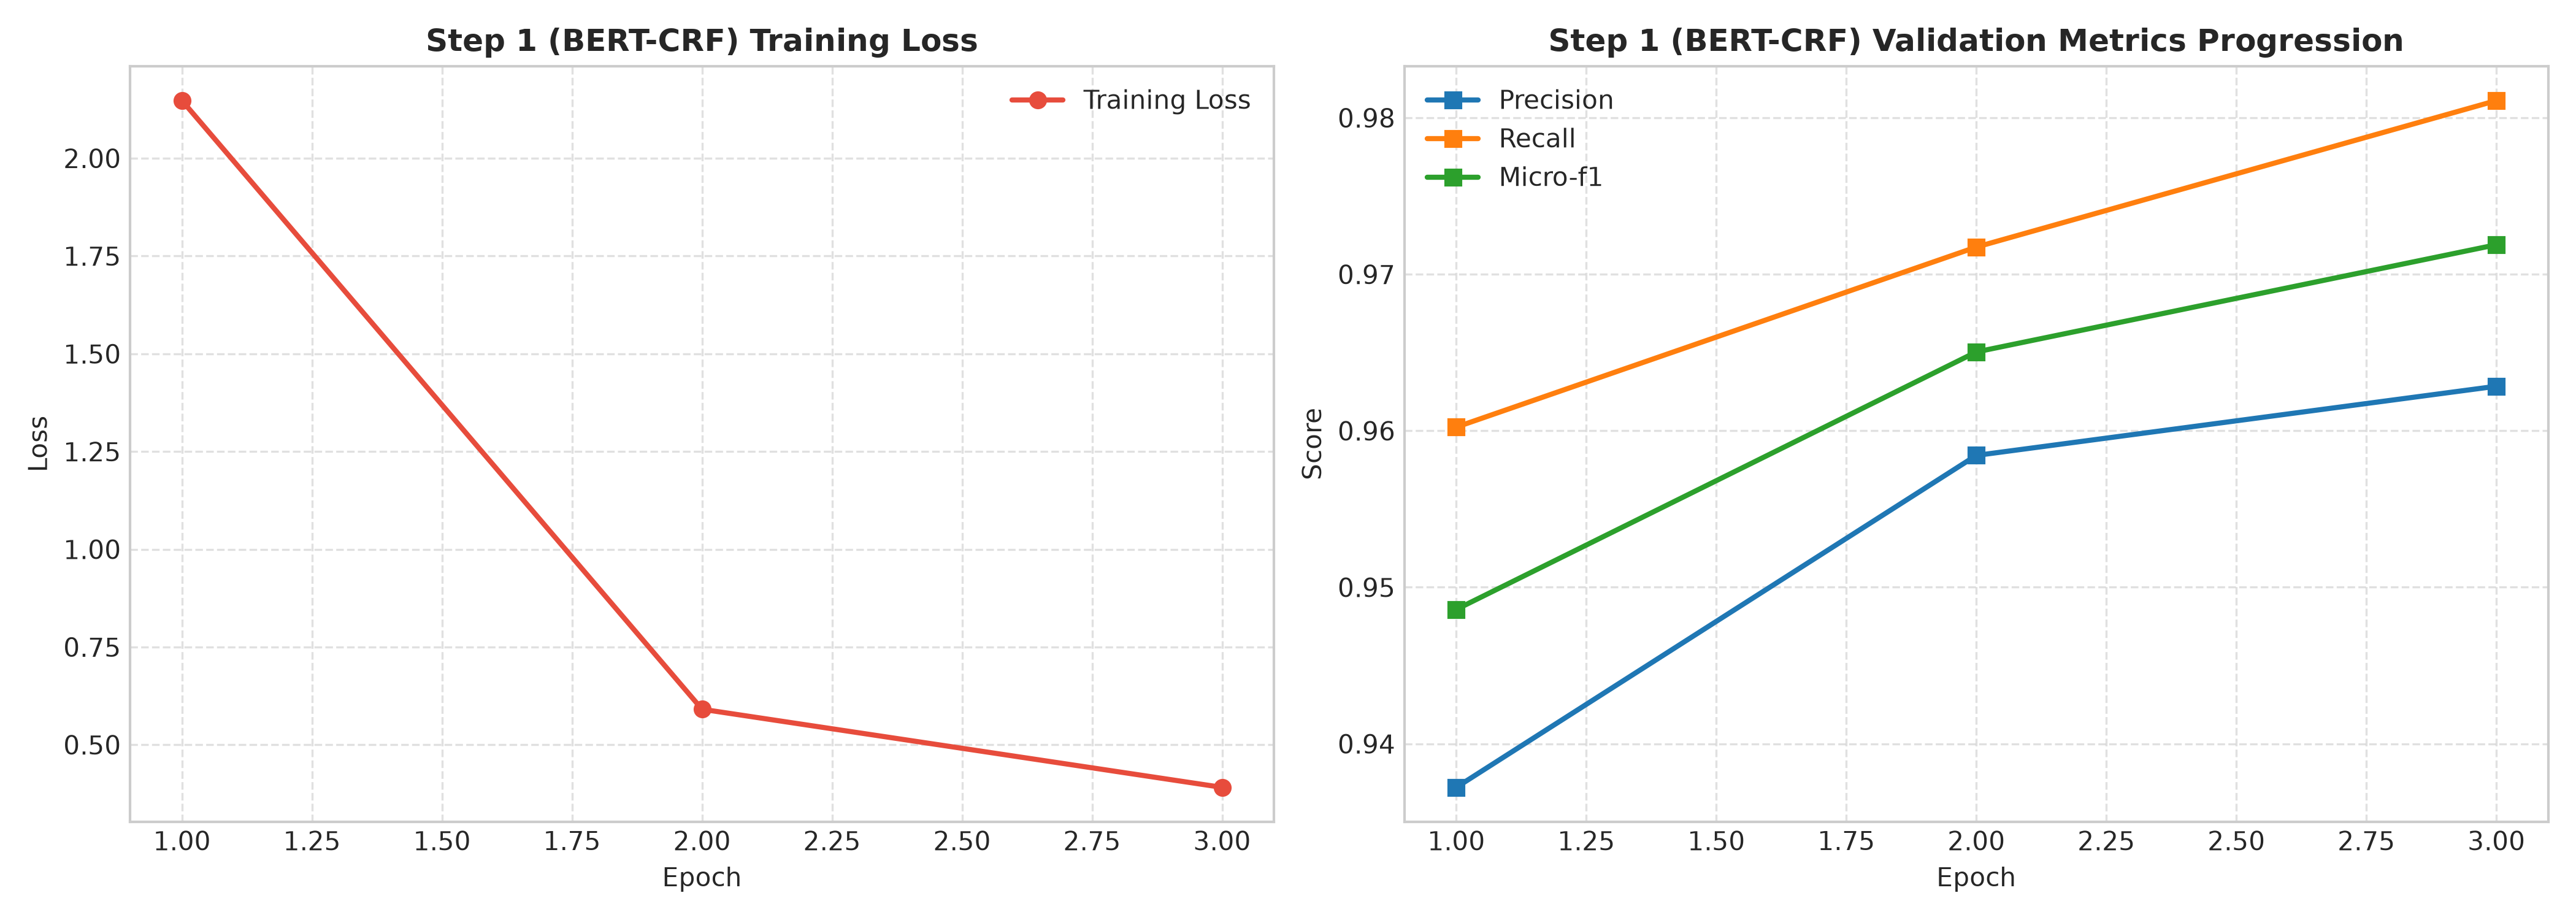

   [4/5]    0.4s  session_manifest.json → STEP1_COMPLETED
   [5/5]    0.4s  pipeline_state.pkl diperbarui | pred4pipeline.txt: ada
   [6/5]    0.5s  📊 Laporan waktu eksekusi & GPU Step 1 diekspor: CSV, Excel (.xlsx), Markdown (.md)
✅ 5f. Plot, tabel laporan, manifest & state Step 1 — selesai dalam 0.5s



In [51]:
require_vars("step_stage", "step1_history", "best_step1_f1", "best1_epoch")

with step_stage("5f. Plot, tabel laporan, manifest & state Step 1", 5) as st:
    _p1 = os.path.join(plots_dir, "03_step1_training_loss_f1_curve.png")
    if step1_history:
        plot_training_history(
            step1_history, task_name="Step 1 (BERT-CRF)",
            output_plot_path=_p1,
            output_csv_path=step1_csv
        )
        st.step(f"Plot & CSV riwayat ditulis ({len(step1_history)} epoch)")
    else:
        st.step("Riwayat kosong — plot dilewati")

    rep.section("3. Step 1: ekstraksi aspect & opinion")
    df_s1_tabel = history_display_frame(step1_history)
    if not df_s1_tabel.empty:
        _kolom_hitung = [c for c in ("TP", "FP", "FN") if c in df_s1_tabel.columns]
        export_step_table(df_s1_tabel, name="master_03_step1_riwayat", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Riwayat Training Step 1 ({DOMAIN.upper()})",
                          notes=("Metrik dihitung pada test set tiap epoch. "
                                 + ("TP/FP/FN adalah hitungan mentah span aspect/opinion; "
                                    "Precision/Recall/Micro-F1 dalam persen."
                                    if _kolom_hitung else
                                    "Kolom TP/FP/FN tidak ada — sel 5a belum dijalankan "
                                    "pada run yang menghasilkan riwayat ini.")),
                          max_rows_md=NUM_EPOCHS)
        rep.table(df_s1_tabel, max_rows=NUM_EPOCHS, caption="Metrik step 1 per epoch")
        st.step(f"Tabel master_03_step1_riwayat diekspor ({len(df_s1_tabel)} baris, "
                f"kolom hitungan: {', '.join(_kolom_hitung) or 'tidak ada'})")

        _row1, _f1_1, _ep1 = best_epoch_row(step1_history)
        rep.kv({
            "epoch_terbaik": _ep1 or best1_epoch,
            "micro-F1_terbaik": f"{_f1_1 * 100:.2f}%",
            "TP_FP_FN_epoch_terbaik": (
                f"{_row1.get('tp', float('nan')):.0f} / {_row1.get('fp', float('nan')):.0f} / "
                f"{_row1.get('fn', float('nan')):.0f}" if "tp" in _row1 else "tidak tercatat"),
            "checkpoint": step1_ckpt,
        })
        st.step(f"Micro-F1 terbaik {_f1_1 * 100:.2f}% (epoch {_ep1 or best1_epoch})")
    else:
        st.step("Tabel riwayat dilewati (tidak ada metrik per epoch)")

    if os.path.exists(_p1):
        from IPython.display import Image, display
        display(Image(_p1))
        rep.image(_p1, "Kurva training step 1")

    update_mcp_manifest("STEP1_COMPLETED", 3, {
        "step1_best_micro_f1": float(best_step1_f1 * 100 if best_step1_f1 <= 1.0 else best_step1_f1),
        "step1_checkpoint": step1_ckpt
    })
    st.step("session_manifest.json → STEP1_COMPLETED")

    save_pipeline_state({"best_step1_f1": best_step1_f1, "best_step1_epoch": best1_epoch})
    st.step(f"pipeline_state.pkl diperbarui | pred4pipeline.txt: "
            f"{'ada' if os.path.exists(pred_file) else 'BELUM ADA'}")

    # ── Ekspor Rekap Waktu Eksekusi, Profil GPU & Detail Epoch Step 1 (CSV, Excel, Markdown) ──
    if "execution_tracker" in globals() and execution_tracker is not None:
        _rep_dir_1 = os.path.join(session_dirs["root"], "execution_reports")
        _s1_files = execution_tracker.export_summary(
            output_dir=_rep_dir_1,
            session_name=f"ACOS_{DOMAIN.upper()}_Step1",
            gdrive_sync=True
        )
        st.step(f"📊 Laporan waktu eksekusi & GPU Step 1 diekspor: CSV, Excel (.xlsx), Markdown (.md)")


## 6. Smart State Checkpoint Saver (`pipeline_state.pkl`)

In [52]:
# Simpan status variabel pipeline ke file pickle untuk pemulihan cepat.
# Menyimpan parameter konfigurasi, direktori, model status, dan artefak runtime.
checkpoint_state_path = save_pipeline_state()

print(f"✅ Pipeline State (expanded) berhasil disimpan ke: {checkpoint_state_path}")
print(f"   Checkpoint Step 1 : {session_dirs['step1_checkpoint']}")
print(f"   Prediksi File     : {os.path.join(session_dirs['logs'], 'pred4pipeline.txt')}")
print("ℹ️ Jika runtime Colab terputus, jalankan sel pemulihan (6b & 6c) di bawah ini untuk melanjutkan langsung ke Step 2.")

✅ Pipeline State (expanded) berhasil disimpan ke: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/pipeline_state.pkl
   Checkpoint Step 1 : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/checkpoints/step1_best
   Prediksi File     : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs/pred4pipeline.txt
ℹ️ Jika runtime Colab terputus, jalankan sel pemulihan (6b & 6c) di bawah ini untuk melanjutkan langsung ke Step 2.


### 6b. Smart State Recovery (Gunakan Sel Ini Jika Kernel Reconnect / Restart)

In [53]:
# Sel Pemulihan Cerdas: Otomatis mendeteksi sesi aktif terakhir.
# Memulihkan BUKAN hanya config/path, tapi juga seluruh artefak runtime yang tersimpan.
def auto_find_latest_state(search_bases, domain="rest16"):
    """Mencari berkas state pipeline_state.pkl dengan validasi domain."""
    if isinstance(search_bases, str):
        search_bases = [search_bases]

    # 1. Cek pointer langsung
    for sb in search_bases:
        if not sb or not os.path.isdir(sb):
            continue
        pointer = os.path.join(sb, f"latest_pipeline_state_{domain}.pkl")
        if os.path.exists(pointer):
            return pointer

    # 2. Cari mendalam
    candidates = []
    for sb in search_bases:
        if not sb or not os.path.exists(sb):
            continue
        for root, dirs, files in os.walk(sb):
            if "pipeline_state.pkl" in files:
                p = os.path.join(root, "pipeline_state.pkl")
                norm = p.replace(os.sep, "/")
                if domain and f"/{domain}_" not in norm and f"_{domain}/" not in norm and f"/{domain}/" not in norm:
                    try:
                        with open(p, "rb") as f:
                            s = pickle.load(f)
                        if s.get("DOMAIN") != domain:
                            continue
                    except Exception:
                        continue
                candidates.append((os.path.getmtime(p), p))
    if candidates:
        candidates.sort(reverse=True)
        return candidates[0][1]
    return None


In [54]:

# Prioritas path state
candidate_state_roots = [
    results_base if 'results_base' in globals() else "",
    os.path.join(base_project_dir, "Output", "results") if 'base_project_dir' in globals() else "",
    os.path.join(base_project_dir, "results") if 'base_project_dir' in globals() else "",
    "/content/drive/MyDrive/ACOS/Output/results",
    "/content/drive/MyDrive/ACOS/results",
    "/content/drive/MyDrive/ACOS-ASLI/Output/results",
    "/content/drive/MyDrive/ACOS-ASLI/results",
]

target_state_path = None
if 'checkpoint_state_path' in globals() and os.path.exists(checkpoint_state_path):
    target_state_path = checkpoint_state_path
else:
    target_state_path = auto_find_latest_state(candidate_state_roots, domain=DOMAIN if 'DOMAIN' in globals() else "rest16")

if target_state_path and os.path.exists(target_state_path):
    with open(target_state_path, "rb") as f:
        pipe_state = pickle.load(f)

    DOMAIN = pipe_state.get("DOMAIN", "rest16")
    BACKBONE = pipe_state.get("BACKBONE", "bert-en")
    indo_root = pipe_state.get("indo_root", base_project_dir)
    tokenized_dir = pipe_state.get("tokenized_dir") or os.path.join(indo_root, "tokenized_data")
    base_project_dir = pipe_state.get("base_project_dir", base_project_dir if 'base_project_dir' in globals() else ".")
    extract_dir = pipe_state.get("extract_dir", os.path.join(base_project_dir, "Extract-Classify-ACOS"))
    bert_cache_dir = pipe_state.get("bert_cache_dir", os.path.join(pipe_state.get("indo_root", base_project_dir), "backbones",
                                     _backbone_dirname(pipe_state.get("BACKBONE"))))
    session_dirs = pipe_state.get("session_dirs", session_dirs if 'session_dirs' in globals() else {})
    MAX_SEQ_LENGTH = pipe_state.get("MAX_SEQ_LENGTH", 128)
    NUM_EPOCHS = pipe_state.get("NUM_EPOCHS", 15)
    STEP2_BATCH_SIZE = pipe_state.get("STEP2_BATCH_SIZE", 16)
    STEP2_LR = pipe_state.get("STEP2_LR", 5e-5)
    SEED = pipe_state.get("SEED", 42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pulihkan artefak runtime yang tersimpan
    rt = pipe_state.get("runtime", {}) or {}
    label_list_step1 = rt.get("label_list_step1")
    label_list_step2 = rt.get("label_list_step2")
    label_map_seq    = rt.get("label_map_seq")
    num_labels_step1 = rt.get("num_labels_step1")
    num_labels_step2 = rt.get("num_labels_step2")
    best_step1_f1    = rt.get("best_step1_f1")
    best_step1_epoch = rt.get("best_step1_epoch")
    best_step2_f1    = rt.get("best_step2_f1")
    best_step2_epoch = rt.get("best_step2_epoch")
    pakai_1st        = rt.get("pakai_1st")
    df_pairs         = rt.get("df_pairs")
    _args_h0         = rt.get("args_h")

    completed_stages = pipe_state.get("completed_stages", [])

    # Bangun ulang objek args_h agar sel evaluasi/inferensi tetap berfungsi
    import types as _types
    if _args_h0 and _args_h0.get("output_dir"):
        _ah = _types.SimpleNamespace()
        _ah.output_dir = _args_h0.get("output_dir", session_dirs.get("logs", ""))
        _ah.max_seq_length = _args_h0.get("max_seq_length", MAX_SEQ_LENGTH)
        args_h = _ah

    print(f"✅ Berhasil memulihkan state dari: {target_state_path}")
    print(f"📁 Session Dir : {session_dirs.get('root')}")
    print(f"📌 DOMAIN      : {DOMAIN} | Device: {device}")
    print(f"   Tahapan selesai : {completed_stages}")
    _recovered_from_state = True
else:
    print(f"ℹ️ Berkas state belum ditemukan (Lanjutkan eksekusi normal dari sel atas).")
    _recovered_from_state = False

✅ Berhasil memulihkan state dari: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/pipeline_state.pkl
📁 Session Dir : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX
📌 DOMAIN      : appsid | Device: cuda
   Tahapan selesai : ['EDA', 'STEP1', 'PAIRS', 'STEP2', 'EVAL']


### 6c. Jaminan Objek Runtime (Fallback Load Otomatis)

Sel ini menjalankan `ensure_objects()`: jika ada variabel runtime yang belum tersedia di memori (mis. kernel restart dan Anda hanya menjalankan sebagian sel), fungsi ini akan mencari hasilnya dari penyimpanan sebelumnya — yaitu *state* yang direstorasi (`pipeline_state.pkl`) atau file JSON label yang tersimpan — sehingga sel-sel lanjutan tidak pernah kehilangan variabel yang dibutuhkan di tengah jalan.

In [55]:
# Jaminan Objek Runtime (FALLBACK "cari hasil dari penyimpanan lama").
# Jika variabel runtime belum ada di memori (mis. kernel restart & hanya jalankan
# sebagian sel), fungsi ini memuatnya ulang dari: (a) state yang sudah direstorasi,
# (b) JSON label tersimpan, atau (c) inisialisasi ulang.
def ensure_objects():
    """Pastikan tokenizer, label lists, num_labels, args_h tersedia di globals.
    Sumber: state yang direstorasi -> JSON label tersimpan -> fallback konstruksi."""
    import types as _t
    g = globals()

    # 1) Tokenizer
    if "tokenizer" not in g or g["tokenizer"] is None:
        if "bert_cache_dir" not in g:
            g["bert_cache_dir"] = os.path.join(
                g.get("indo_root") or g.get("base_project_dir", "."),
                "backbones", _backbone_dirname(g.get("BACKBONE")))
        if os.path.exists(os.path.join(g["bert_cache_dir"], "vocab.txt")):
            from bert_utils.tokenization import BertTokenizer
            g["tokenizer"] = BertTokenizer.from_pretrained(
                g["bert_cache_dir"], do_lower_case=True)
            print("   🔁 Tokenizer dimuat ulang dari bert_cache_dir.")
        else:
            raise RuntimeError("Tokenizer belum ada & vocab.txt tidak ditemukan. "
                               "Jalankan sel konfigurasi (cell 6) dulu.")

    # 2) args_h
    if "args_h" not in g or g["args_h"] is None:
        _ah = _t.SimpleNamespace()
        _ah.output_dir = g.setdefault("session_dirs", {}).get("logs", "./logs")
        _ah.max_seq_length = g.get("MAX_SEQ_LENGTH", 128)
        g["args_h"] = _ah
        print("   🔁 args_h dibangun ulang dari state.")

    # Domain Indonesia harus dipatch DI SINI juga, bukan hanya di sel 5a.
    # ensure_objects() dipanggil dari sel 7a, 8a, 8c, 9a dan 10; setelah restart
    # kernel salah satu dari sel itu bisa jadi yang pertama berjalan, dan
    # CategorySentiProcessor.get_labels("appsid") tanpa patch mengembalikan
    # `l = None` lalu meledak di `for cate in l` — TypeError yang jauh dari
    # penyebabnya. QuadProcessor tidak terpengaruh (ia mengabaikan domain_type),
    # jadi gejalanya hanya muncul di Step 2.
    if str(g.get("DOMAIN", "")).lower().startswith("apps"):
        try:
            import acos_id.taxonomy as _tax
        except ModuleNotFoundError:
            raise RuntimeError(
                "DOMAIN Indonesia tetapi paket acos_id belum ada di sys.path. "
                "Jalankan sel 1s lebih dulu.")
        from run_classifier_dataset_utils import processors as _procs
        _tax.patch_processor_labels(_procs)

    # 3) Label lists & num_labels (cari dari JSON tersimpan jika belum ada)
    csv_dir = g.setdefault("session_dirs", {}).get("csv")
    for _key, _jname in [("label_list_step1", "labels_step1"),
                         ("label_list_step2", "labels_step2")]:
        if (_key not in g or g[_key] is None) and csv_dir:
            _p = os.path.join(csv_dir, _jname + ".json")
            if os.path.exists(_p):
                with open(_p, "r", encoding="utf-8") as _jf:
                    g[_key] = json.load(_jf)
                print(f"   🔁 {_key} dimuat ulang dari {_jname}.json.")

    # Fallback dari processor jika masih None
    if g.get("label_list_step1") is None:
        from run_classifier_dataset_utils import processors
        processor_step1 = processors["quad"]()
        g["label_list_step1"] = processor_step1.get_labels(g.get("DOMAIN", "rest16"))
    if g.get("label_list_step2") is None:
        from run_classifier_dataset_utils import processors
        processor_step2 = processors["categorysenti"]()
        g["label_list_step2"] = processor_step2.get_labels(g.get("DOMAIN", "rest16"))

    if g.get("label_list_step1") is not None and "num_labels_step1" not in g:
        g["num_labels_step1"] = len(g["label_list_step1"][1])
    if g.get("label_list_step2") is not None and "num_labels_step2" not in g:
        g["num_labels_step2"] = len(g["label_list_step2"][0])

    # 4) Sumber kandidat pasangan (default: prediksi step 1 = pipeline penuh)
    if "pakai_1st" not in g:
        g["pakai_1st"] = True

    return g

ensure_objects()
print("🛡️ Objek runtime terverifikasi siap digunakan.")

   🔁 args_h dibangun ulang dari state.
   🔁 label_list_step2 dimuat ulang dari labels_step2.json.
🛡️ Objek runtime terverifikasi siap digunakan.


## 7. Jembatan Pasangan Kandidat (Step 1 → Step 2)

### 7a. Pembentukan / Pemuatan Pasangan
Membaca `pred4pipeline.txt` dan membentuk cross-product aspect × opinion. Tag dikenali
dari polanya, bukan posisi kolom tab, supaya tag seperti `a--1,-1` tidak menyelundup ke
kolom teks dan memicu KeyError saat tokenisasi Step 2.

In [56]:
ensure_objects()
require_vars("step_stage", "session_dirs", "extract_dir")

import codecs as cs
import re

with step_stage("7a. Pasangan kandidat Step 1 → Step 2", 4) as st:
    pred_file = os.path.join(session_dirs["logs"], "pred4pipeline.txt")
    target_tokenized_tsv = os.path.join(tokenized_base, "tokenized_data",
                                        f"{DOMAIN}_test_pair_1st.tsv")
    candidate_csv = os.path.join(session_dirs["csv"], "candidate_pairs_summary.csv")

    _in_mem = ('df_pairs' in globals() and df_pairs is not None
               and not df_pairs.empty and os.path.exists(target_tokenized_tsv))
    _on_disk = os.path.exists(candidate_csv) and os.path.exists(target_tokenized_tsv)

    if _in_mem:
        st.step(f"[CACHE HIT] {len(df_pairs):,} pasangan sudah ada di memori runtime")
    elif _on_disk:
        df_pairs = pd.read_csv(candidate_csv)
        st.step(f"[CACHE HIT] {len(df_pairs):,} pasangan dimuat dari {candidate_csv}")
    else:
        if not os.path.exists(pred_file):
            found_pred = auto_find_file("pred4pipeline.txt")
            if found_pred:
                os.makedirs(session_dirs["logs"], exist_ok=True)
                shutil.copy(found_pred, pred_file)
                st.step(f"pred4pipeline.txt disalin dari sesi sebelumnya: {found_pred}")
            else:
                raise FileNotFoundError(
                    f"pred4pipeline.txt tidak ada di {pred_file} maupun sesi lain. "
                    f"Jalankan Step 1 (sel 5a-5f) lebih dulu.")
        else:
            st.step(f"Sumber prediksi: {pred_file}")

        with cs.open(pred_file, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        st.step(f"{len(lines):,} baris prediksi dibaca")

        TAG_RE = re.compile(r'^(a|o)-(-?\d+,-?\d+)$')
        pair_records = []
        n_skip = 0
        os.makedirs(os.path.dirname(target_tokenized_tsv), exist_ok=True)
        with cs.open(target_tokenized_tsv, 'w', encoding='utf-8') as wf:
            for line in tqdm(lines, desc="   Membentuk pasangan", unit="baris", leave=False):
                asp, opi, text_parts = [], [], []
                for tok in line.strip().split():
                    m = TAG_RE.match(tok)
                    if m:
                        (asp if m.group(1) == 'a' else opi).append(m.group(2))
                    else:
                        text_parts.append(tok)
                if not text_parts:
                    n_skip += 1
                    continue
                text = ' '.join(text_parts)
                if not asp:
                    asp.append('-1,-1')
                if not opi:
                    opi.append('-1,-1')
                for pa in asp:
                    for po in opi:
                        wf.write(f"{text}####{pa} {po}\n")
                        pair_records.append({"Text": text, "Aspect_Span": pa,
                                             "Opinion_Span": po})

        df_pairs = pd.DataFrame(pair_records)
        df_pairs.to_csv(candidate_csv, index=False)
        st.step(f"{len(df_pairs):,} pasangan ditulis ke {target_tokenized_tsv}"
                + (f" ({n_skip} baris kosong dilewati)" if n_skip else ""))

    st.step(f"Siap untuk Step 2 | berkas pair: "
            f"{'ada' if os.path.exists(target_tokenized_tsv) else 'BELUM ADA'}")

▶️  7a. Pasangan kandidat Step 1 → Step 2
   [1/4]    0.0s  [CACHE HIT] 10,991 pasangan dimuat dari /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/candidate_pairs_summary.csv
   [2/4]    0.0s  Siap untuk Step 2 | berkas pair: ada
✅ 7a. Pasangan kandidat Step 1 → Step 2 — selesai dalam 0.0s



### 7b. Distribusi Tipe Pasangan
Sel pelaporan: tabel implicit/explicit, plot batang, dan penyimpanan state. Aman diulang.

▶️  7b. Laporan distribusi pasangan kandidat
   [1/4]    0.0s  10,991 pasangan dalam 4 tipe: Explicit-Implicit 41.49%, Explicit-Explicit 32.75%, Implicit-Explicit 25.6%, Implicit-Implicit 0.15%
=== Distribusi Tipe Pasangan Kandidat (APPSID) (4 baris) ===


,Tipe_Pasangan,Jumlah,Persen
0,Explicit-Implicit,4560,41.49
1,Explicit-Explicit,3600,32.75
2,Implicit-Explicit,2814,25.60
3,Implicit-Implicit,17,0.15


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_04_tipe_pasangan.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_04_tipe_pasangan.md
=== Preview 20 Pasangan Kandidat (APPSID) (20 baris) ===


,Text,Aspect_Span,Opinion_Span,Is_Implicit_Aspect,Is_Implicit_Opinion,Pair_Type
0,saldo aku 100 ribu,"0,1","-1,-1",False,True,Explicit-Implicit
1,kok tidak bisa transfer,"3,4","1,3",False,False,Explicit-Explicit
2,saya tidak bisa transaksi apa dh,"3,4","1,3",False,False,Explicit-Explicit
3,chat ke customer service tidak membantu,"2,4","5,6",False,False,Explicit-Explicit
4,tampilan serta sistemnya juga keren,"0,1","4,5",False,False,Explicit-Explicit
5,bisa dapat hadiah gratis transfer ke bank mana...,"2,3","3,4",False,False,Explicit-Explicit
6,bisa dapat hadiah gratis transfer ke bank mana...,"2,3","12,13",False,False,Explicit-Explicit
7,bisa dapat hadiah gratis transfer ke bank mana...,"2,3","17,18",False,False,Explicit-Explicit
8,bisa dapat hadiah gratis transfer ke bank mana...,"2,3","29,31",False,False,Explicit-Explicit
9,bisa dapat hadiah gratis transfer ke bank mana...,"2,3","-1,-1",False,True,Explicit-Implicit


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_05_preview_pasangan.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_05_preview_pasangan.md
   [2/4]    0.0s  Tabel master_04 & master_05 diekspor


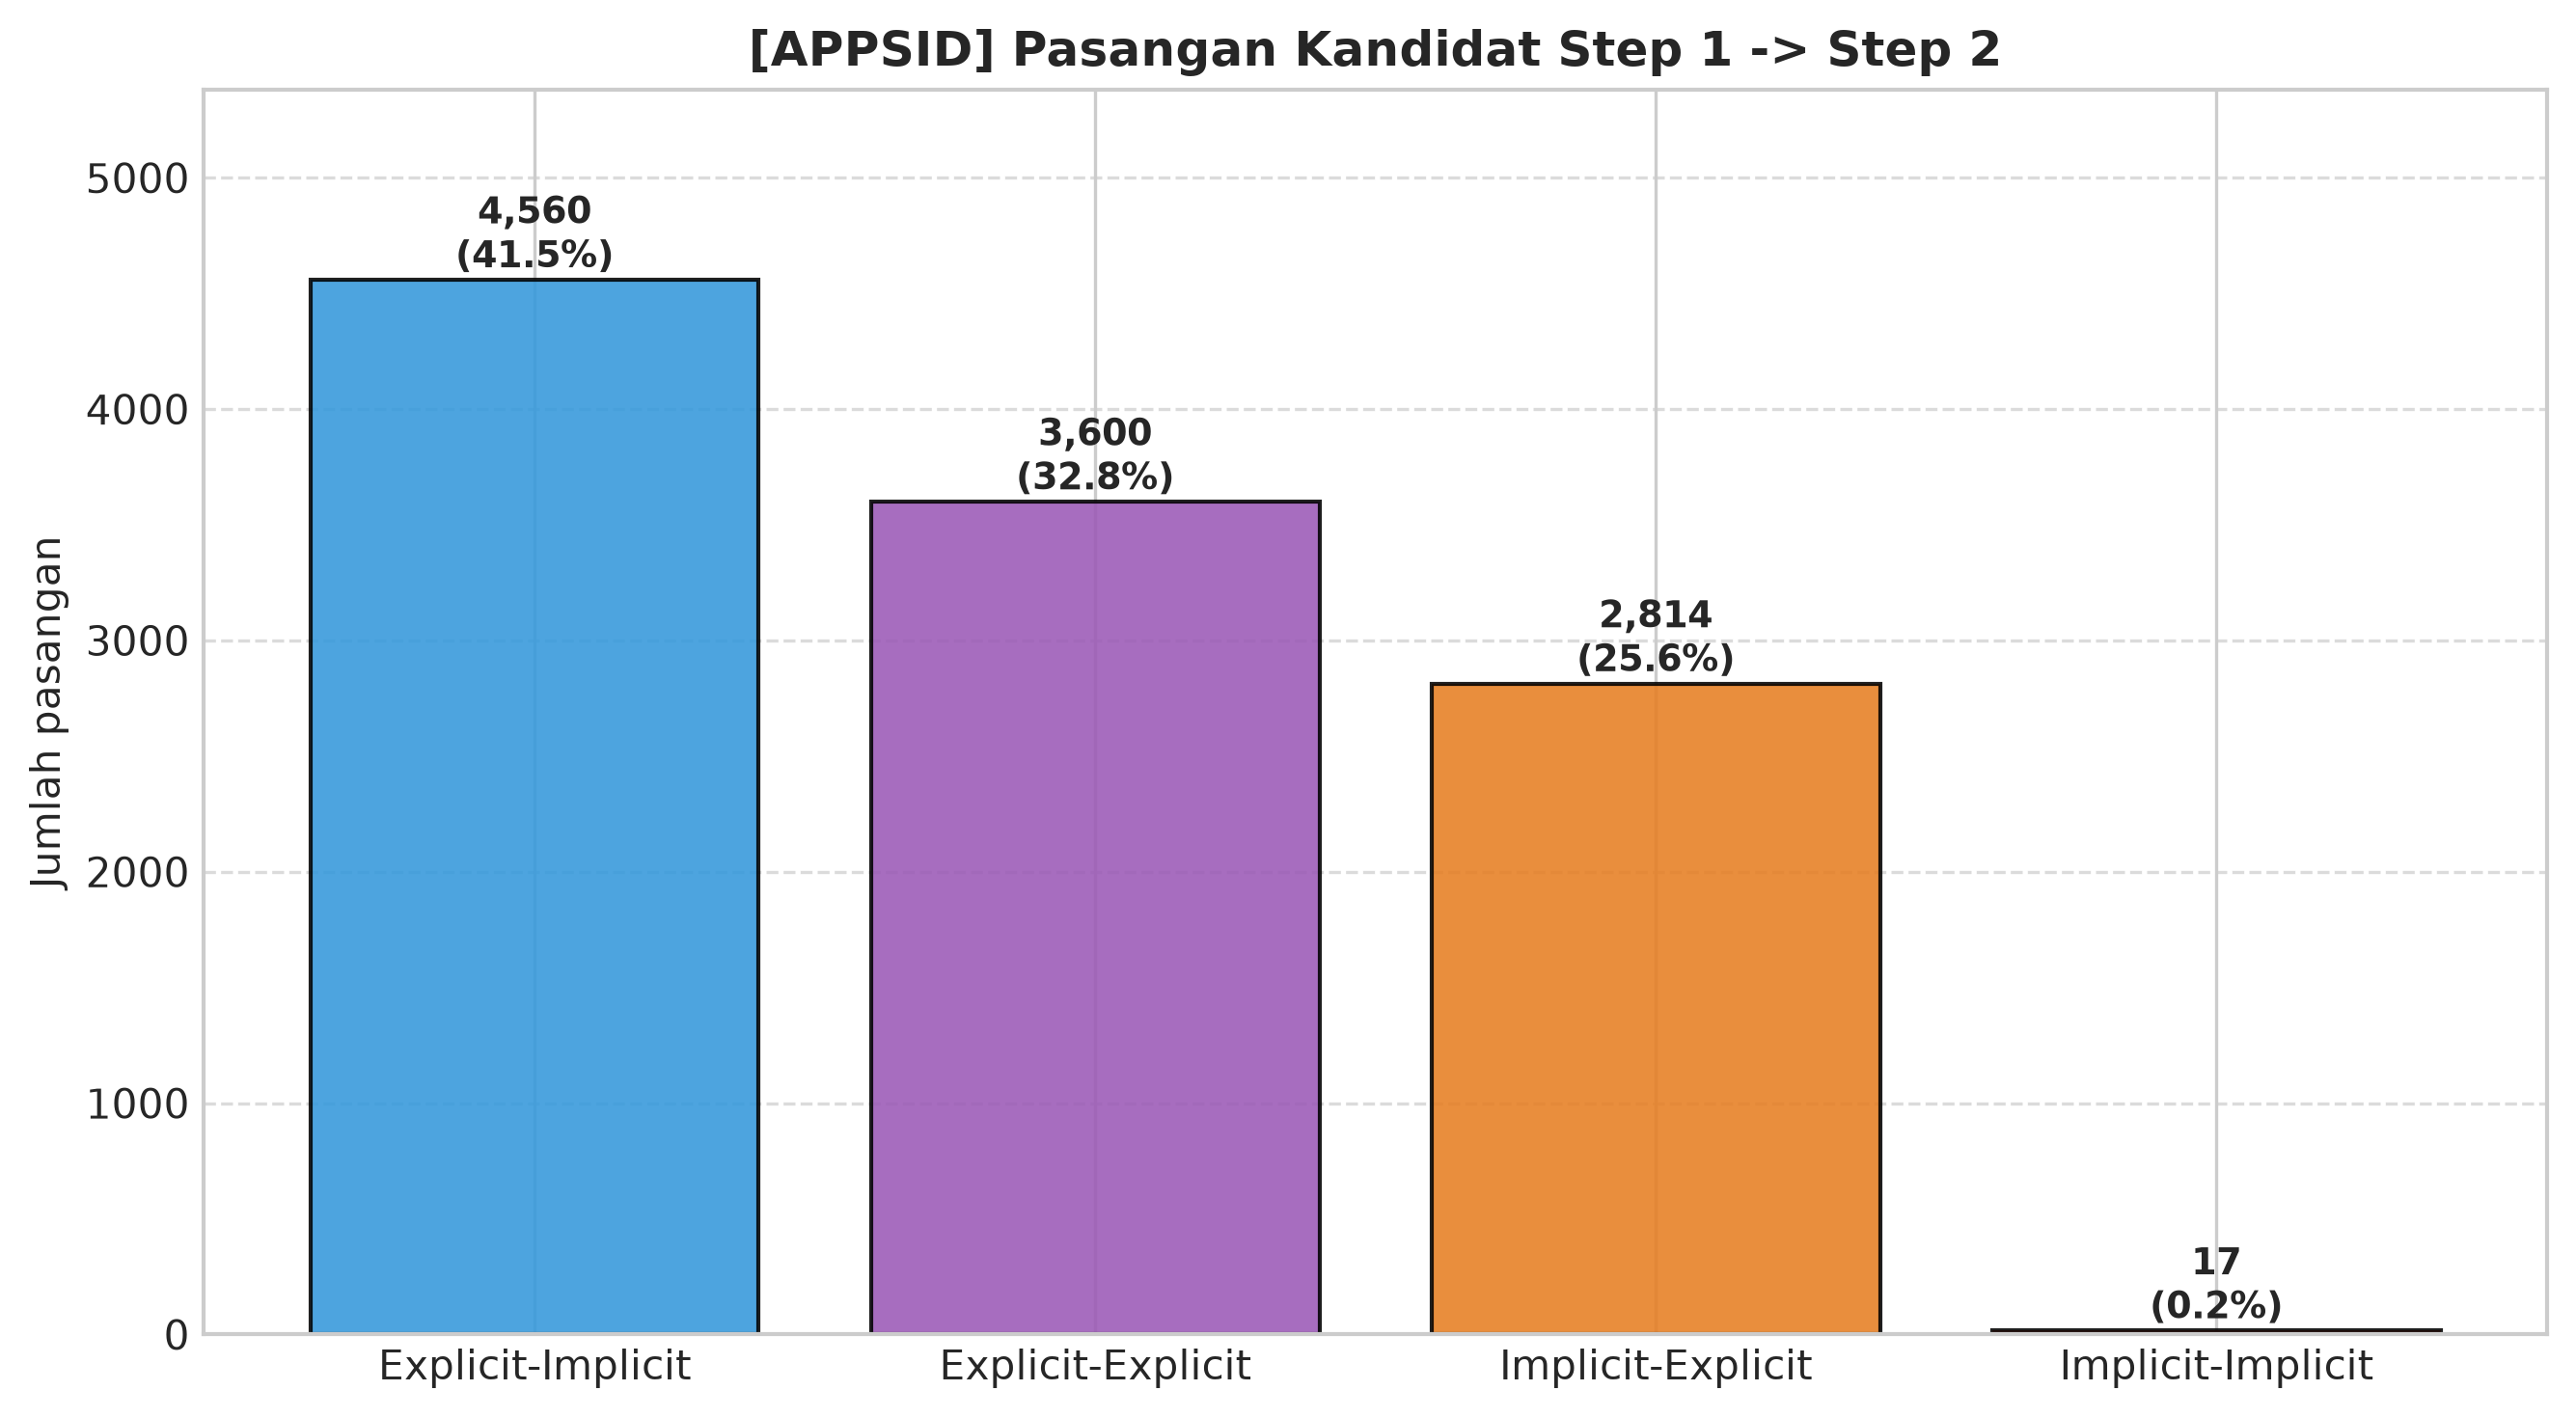

   [3/4]    0.4s  Plot disimpan: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/plots/04_candidate_pairs_distribution.png
   [4/4]    0.4s  Manifest → CANDIDATE_PAIRS_GENERATED, pipeline_state.pkl diperbarui
✅ 7b. Laporan distribusi pasangan kandidat — selesai dalam 0.4s



In [57]:
require_vars("step_stage", "df_pairs")

with step_stage("7b. Laporan distribusi pasangan kandidat", 4) as st:
    rep.section("4. Jembatan: pasangan kandidat")
    if df_pairs.empty:
        rep.text("Tidak ada pasangan kandidat yang terbentuk.")
        st.step("df_pairs kosong — tabel dan plot dilewati")
    else:
        df_pairs["Is_Implicit_Aspect"] = df_pairs["Aspect_Span"] == "-1,-1"
        df_pairs["Is_Implicit_Opinion"] = df_pairs["Opinion_Span"] == "-1,-1"
        df_pairs["Pair_Type"] = (
            df_pairs["Is_Implicit_Aspect"].map({True: "Implicit", False: "Explicit"}) + "-"
            + df_pairs["Is_Implicit_Opinion"].map({True: "Implicit", False: "Explicit"})
        )
        n_pair = len(df_pairs)
        df_tipe = df_pairs["Pair_Type"].value_counts().rename_axis(
            "Tipe_Pasangan").reset_index(name="Jumlah")
        df_tipe["Persen"] = (df_tipe["Jumlah"] / n_pair * 100).round(2)
        st.step(f"{n_pair:,} pasangan dalam {len(df_tipe)} tipe: "
                + ", ".join(f"{r.Tipe_Pasangan} {r.Persen}%" for r in df_tipe.itertuples()))

        export_step_table(df_tipe, name="master_04_tipe_pasangan", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Distribusi Tipe Pasangan Kandidat ({DOMAIN.upper()})",
                          notes=f"Total {n_pair} pasangan dari cross-product aspect x opinion.")
        rep.table(df_tipe, caption="Tipe pasangan")
        export_step_table(df_pairs.head(20), name="master_05_preview_pasangan",
                          csv_dir=csv_dir, md_dir=md_dir,
                          title=f"Preview 20 Pasangan Kandidat ({DOMAIN.upper()})",
                          max_rows_md=20)
        st.step("Tabel master_04 & master_05 diekspor")

        plt.figure(figsize=(9, 5))
        _w = ["#3498db", "#9b59b6", "#e67e22", "#e74c3c"][:len(df_tipe)]
        _b = plt.bar(df_tipe["Tipe_Pasangan"], df_tipe["Jumlah"], color=_w,
                     edgecolor="black", alpha=0.88)
        for b, v in zip(_b, df_tipe["Jumlah"]):
            plt.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / n_pair * 100:.1f}%)",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
        plt.title(f"[{DOMAIN.upper()}] Pasangan Kandidat Step 1 -> Step 2",
                  fontsize=12, fontweight="bold")
        plt.ylabel("Jumlah pasangan")
        plt.margins(y=0.18)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        _pp = os.path.join(plots_dir, "04_candidate_pairs_distribution.png")
        plt.savefig(_pp, dpi=300)
        plt.show()
        plt.close()
        rep.image(_pp, "Distribusi tipe pasangan kandidat")
        st.step(f"Plot disimpan: {_pp}")

    update_mcp_manifest("CANDIDATE_PAIRS_GENERATED", 4,
                        {"candidate_pairs_count": len(df_pairs)})
    save_pipeline_state({"df_pairs": df_pairs})
    st.step("Manifest → CANDIDATE_PAIRS_GENERATED, pipeline_state.pkl diperbarui")

## 8. Step 2: Klasifikasi Category & Sentiment (Bertahap)
Melatih `CategorySentiClassification` multi-label pada pasangan kandidat $(a, o)$.
Dipecah mengikuti pola Step 1 supaya setiap bagian bisa dilacak sendiri.

| Sel | Isi | Aman diulang |
|---|---|---|
| 8a | Import, patch tokenizer, label, path checkpoint | ya |
| 8b | Deteksi cache Step 2 (sesi aktif + sesi lama) | ya |
| 8c | Data evaluasi pasangan + gold Step 2 | ya |
| 8d | Model, data training, optimizer | ya (mengalokasi ulang VRAM) |
| 8e | Loop training per epoch + checkpoint terbaik | tidak (melatih ulang) |
| 8f | Plot, tabel laporan, manifest, simpan state | ya |

Sel 8c-8e melewati dirinya sendiri saat `STEP2_SKIP_TRAINING` bernilai `True`.
Catatan: 8c tetap dijalankan meski cache hit bila `eval_loader_2` belum ada, karena
sel evaluasi final (9a) membutuhkannya.

### 8a. Inisialisasi Step 2

In [58]:
ensure_objects()
require_vars("step_stage", "session_dirs", "bert_cache_dir")

from modeling import CategorySentiClassification
from dataset_utils import read_pair_gold
from eval_metrics import pair_eval
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes
from tqdm.auto import tqdm
import logging

# Toggle Melatih Ulang Step 2 (Set True jika ingin memaksa melatih ulang)
FORCE_RETRAIN_STEP2 = False

with step_stage("8a. Inisialisasi Step 2: patch tokenizer, patch metrik, label, path", 6) as st:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        st.step(f"GPU cache dibersihkan | {torch.cuda.get_device_name(0)}")
    else:
        st.step("Mode CPU aktif (CUDA tidak tersedia)")

    # Token di luar vocab dipetakan ke [UNK] dan dilaporkan, bukan melempar
    # KeyError yang menghentikan seluruh epoch.
    _oov_seen = set()

    def patched_convert_tokens_to_ids(self, tokens):
        if tokens is None:
            return None
        if isinstance(tokens, str):
            try:
                return self.vocab[tokens]
            except KeyError:
                if tokens not in _oov_seen:
                    _oov_seen.add(tokens)
                    print(f"⚠️ Token di luar vocab: {ascii(tokens)}")
                return self.vocab.get('[UNK]', 100)
        ids = []
        for token in tokens:
            try:
                ids.append(self.vocab[token])
            except KeyError:
                _oov_seen.add(token)
                ids.append(self.vocab.get('[UNK]', 100))
        if len(ids) > self.max_len:
            logging.getLogger(__name__).warning(
                f"Seq len ({len(ids)}) > max ({self.max_len})")
        return ids

    BertTokenizer.convert_tokens_to_ids = patched_convert_tokens_to_ids
    st.step("BertTokenizer.convert_tokens_to_ids dipatch (OOV → [UNK], dicatat sekali)")

    # Patch evaluasi: measureQuad & measureQuad_imp ikut mengembalikan tp/fp/fn,
    # sekaligus defensif terhadap teks prediksi di luar gold (KeyError text_type)
    # dan memperbaiki return-di-luar-loop pada measureQuad_imp.
    _em2 = patch_eval_metrics_counts()
    st.step("eval_metrics dipatch: tp/fp/fn ikut dikembalikan, agregat semua slot "
            "difficulty, aman terhadap OOV/mismatched text")

    processor_step2 = processors["categorysenti"]()
    label_list_step2 = processor_step2.get_labels(DOMAIN)
    num_labels_step2 = len(label_list_step2[0])
    st.step(f"Label category-sentiment: {num_labels_step2} kelas")

    step2_ckpt = session_dirs["step2_checkpoint"]
    step2_bin = os.path.join(step2_ckpt, "pytorch_model.bin")
    step2_csv = os.path.join(session_dirs["csv"], "step2_training_history.csv")
    step2_progress_json = os.path.join(session_dirs["logs"], "step2_progress.json")
    os.makedirs(step2_ckpt, exist_ok=True)
    st.step(f"Checkpoint : {step2_ckpt}")

    # args_h dan logger2 dibangun di sini, bukan di 8d, karena 8d dilewati saat
    # cache hit sementara sel 8e dan 9a tetap membutuhkannya.
    logger2 = logging.getLogger("Step2")
    if "args_h" not in globals() or globals()["args_h"] is None:
        import types as _t
        args_h = _t.SimpleNamespace(output_dir=session_dirs["logs"],
                                    max_seq_length=MAX_SEQ_LENGTH)
        st.step(f"args_h dibangun (Step 1 dilewati di sesi ini) → {args_h.output_dir}")
    else:
        st.step(f"args_h dipakai ulang dari Step 1 → {args_h.output_dir}")

    print(f"   FORCE_RETRAIN_STEP2={FORCE_RETRAIN_STEP2} | epoch target={NUM_EPOCHS} | "
          f"batch={STEP2_BATCH_SIZE} | lr={STEP2_LR}")

▶️  8a. Inisialisasi Step 2: patch tokenizer, patch metrik, label, path
   [1/6]    0.0s  GPU cache dibersihkan | AMD Instinct MI300X VF
   [2/6]    0.0s  BertTokenizer.convert_tokens_to_ids dipatch (OOV → [UNK], dicatat sekali)
   [3/6]    0.0s  eval_metrics dipatch: tp/fp/fn ikut dikembalikan, agregat semua slot difficulty, aman terhadap OOV/mismatched text
   [4/6]    0.0s  Label category-sentiment: 39 kelas
   [5/6]    0.0s  Checkpoint : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/checkpoints/step2_best
   [6/6]    0.0s  args_h dipakai ulang dari Step 1 → /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs
   FORCE_RETRAIN_STEP2=False | epoch target=50 | batch=16 | lr=5e-05
✅ 8a. Inisialisasi Step 2: patch tokenizer, patch metrik, label, path — selesai dalam 0.0s



### 8b. Deteksi Cache Step 2
Menentukan `STEP2_SKIP_TRAINING`, satu-satunya penentu apakah sel 8d-8e melatih model.

In [59]:
require_vars("step_stage", "step2_bin", "step2_csv", "FORCE_RETRAIN_STEP2")

with step_stage("8b. Deteksi cache Step 2 (sesi aktif lalu sesi lama)", 4) as st:
    step2_already_done = os.path.exists(step2_bin)
    st.step("Sesi aktif — model: " + (
        f"{os.path.getsize(step2_bin) / 1024 ** 2:.1f} MB" if step2_already_done
        else "belum ada"))

    if step2_already_done:
        st.step("Pencarian sesi lama dilewati (checkpoint sesi aktif sudah ada)")
    else:
        found_bin2 = auto_find_file("pytorch_model.bin", must_contain="step2_best",
                                    search_roots=[
                                        results_base if 'results_base' in globals() else "",
                                        "/content/drive/MyDrive/ACOS/Output/results",
                                        os.path.join(base_project_dir, "Output", "results"),
                                    ])
        if found_bin2 and "step2_best" in found_bin2:
            src_dir2 = os.path.dirname(found_bin2)
            st.step(f"Checkpoint sesi sebelumnya ditemukan: {src_dir2}")
            for fn in ["pytorch_model.bin", "config.json", "vocab.txt"]:
                fp = os.path.join(src_dir2, fn)
                if os.path.exists(fp):
                    shutil.copy(fp, os.path.join(step2_ckpt, fn))
                    st.note(f"↪ {fn} ({os.path.getsize(fp) / 1024 ** 2:.1f} MB) disalin")
            found_csv2 = auto_find_file("step2_training_history.csv")
            if found_csv2:
                shutil.copy(found_csv2, step2_csv)
                st.note(f"↪ step2_training_history.csv disalin dari {found_csv2}")
            step2_already_done = os.path.exists(step2_bin)
        else:
            st.step("Tidak ada checkpoint step2_best di sesi mana pun")

    STEP2_SKIP_TRAINING = (not FORCE_RETRAIN_STEP2) and step2_already_done
    st.step("Keputusan: " + ("CACHE HIT → sel 8d-8e dilewati"
                             if STEP2_SKIP_TRAINING else
                             f"TRAINING dijalankan ({NUM_EPOCHS} epoch)"))

    if STEP2_SKIP_TRAINING:
        print(f"⏩ [CACHE HIT] Model Step 2 : {step2_ckpt}")
        if os.path.exists(step2_csv):
            df_s2_saved = pd.read_csv(step2_csv)
            step2_history = df_s2_saved.to_dict('records')
            _row_c2, best_step2_f1, best2_epoch = best_epoch_row(step2_history)
            best2_epoch = best2_epoch or NUM_EPOCHS
            _ada_hitungan = all(c in df_s2_saved.columns for c in ("tp", "fp", "fn"))
            st.step(f"Riwayat tersimpan: {len(df_s2_saved)} epoch, terbaik epoch {best2_epoch}"
                    + (" (TP/FP/FN tersedia)" if _ada_hitungan
                       else " (tanpa kolom TP/FP/FN — CSV dari run lama)"))
            if len(df_s2_saved) < NUM_EPOCHS:
                st.note(f"⚠️ Riwayat hanya {len(df_s2_saved)}/{NUM_EPOCHS} epoch — "
                        f"checkpoint dari run yang terhenti. Set FORCE_RETRAIN_STEP2=True "
                        f"bila ingin melatih penuh.")
        else:
            step2_history = []
            best_step2_f1 = 0.0
            best2_epoch = NUM_EPOCHS
            st.step("Riwayat CSV tidak ada — metrik per epoch tidak bisa dilaporkan")
# ── Resume Epoch: cek apakah training Step 2 terhenti di tengah jalan ────────
step2_resume_json = os.path.join(session_dirs["logs"], "step2_resume.json")
STEP2_RESUME_EPOCH = 0  # epoch terakhir yang selesai (0 = belum ada / baru)

if (not STEP2_SKIP_TRAINING) and (not FORCE_RETRAIN_STEP2):
    if not os.path.exists(step2_resume_json):
        _found_resume2 = auto_find_file("step2_resume.json", search_roots=[
            results_base if 'results_base' in globals() else "",
            "/content/drive/MyDrive/ACOS/Output/results",
            os.path.join(base_project_dir, "Output", "results"),
        ])
        if _found_resume2 and os.path.exists(_found_resume2):
            try:
                _rj2_prev = json.load(open(_found_resume2, encoding="utf-8"))
                _last2_prev = int(_rj2_prev.get("last_completed_epoch", 0))
                _prev_session_root2 = os.path.dirname(os.path.dirname(_found_resume2))
                _prev_epoch_dir2 = os.path.join(_prev_session_root2, "checkpoints", f"step2_epoch_{_last2_prev}")
                if os.path.isdir(_prev_epoch_dir2):
                    _tgt_epoch_dir2 = os.path.join(session_dirs["checkpoints"], f"step2_epoch_{_last2_prev}")
                    os.makedirs(_tgt_epoch_dir2, exist_ok=True)
                    for _f in os.listdir(_prev_epoch_dir2):
                        shutil.copy(os.path.join(_prev_epoch_dir2, _f), os.path.join(_tgt_epoch_dir2, _f))
                    shutil.copy(_found_resume2, step2_resume_json)
                    print(f"↪ [RESUME] Menyalin resume checkpoint Step 2 dari sesi lama: epoch {_last2_prev}")
            except Exception as _e_copy2:
                print(f"⚠️ Gagal menyalin resume Step 2 dari sesi lama: {_e_copy2}")

    if os.path.exists(step2_resume_json):
        try:
            _rj2 = json.load(open(step2_resume_json, encoding="utf-8"))
            _last2  = int(_rj2.get("last_completed_epoch", 0))
            _total2 = int(_rj2.get("total_epochs", NUM_EPOCHS))
            _epoch_ckpt_check2 = os.path.join(
                session_dirs["checkpoints"], f"step2_epoch_{_last2}")
            _epoch_bin_check2  = os.path.join(_epoch_ckpt_check2, "pytorch_model.bin")
            if _total2 != NUM_EPOCHS:
                print(f"⚠️  [RESUME] NUM_EPOCHS berubah ({_total2}→{NUM_EPOCHS}). "
                      f"Resume Step 2 diabaikan — training dari awal.")
            elif _last2 > 0 and _last2 < NUM_EPOCHS and os.path.exists(_epoch_bin_check2):
                STEP2_RESUME_EPOCH = _last2
                print(f"♻️  [RESUME] Step 2 terhenti di epoch {_last2}/{NUM_EPOCHS}. "
                      f"Akan dilanjutkan dari epoch {_last2 + 1}.")
            elif _last2 >= NUM_EPOCHS:
                print(f"✅ [RESUME] step2_resume.json menunjukkan training sudah "
                      f"selesai ({_last2}/{NUM_EPOCHS} epoch).")
        except Exception as _re2:
            print(f"⚠️  Tidak bisa membaca step2_resume.json: {_re2}. Training dari awal.")

elif STEP2_SKIP_TRAINING:
    if os.path.exists(step2_resume_json):
        try:
            _rj2_info = json.load(open(step2_resume_json, encoding="utf-8"))
            _ep2_info = _rj2_info.get("last_completed_epoch", "?")
            print(f"ℹ️  step2_resume.json ada (epoch {_ep2_info}/{NUM_EPOCHS}) "
                  f"— diabaikan karena cache hit sudah lengkap.")
        except Exception:
            pass

if STEP2_RESUME_EPOCH > 0:
    STEP2_SKIP_TRAINING = False  # paksa jalankan training (lanjut dari epoch berikutnya)
    print(f"   → STEP2_SKIP_TRAINING di-override: training akan lanjut dari "
          f"epoch {STEP2_RESUME_EPOCH + 1}.")

▶️  8b. Deteksi cache Step 2 (sesi aktif lalu sesi lama)
   [1/4]    0.0s  Sesi aktif — model: 475.0 MB
   [2/4]    0.0s  Pencarian sesi lama dilewati (checkpoint sesi aktif sudah ada)
   [3/4]    0.0s  Keputusan: CACHE HIT → sel 8d-8e dilewati
⏩ [CACHE HIT] Model Step 2 : /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/checkpoints/step2_best
   [4/4]    0.0s  Riwayat tersimpan: 8 epoch, terbaik epoch 3 (TP/FP/FN tersedia)
        ⚠️ Riwayat hanya 8/50 epoch — checkpoint dari run yang terhenti. Set FORCE_RETRAIN_STEP2=True bila ingin melatih penuh.
✅ 8b. Deteksi cache Step 2 (sesi aktif lalu sesi lama) — selesai dalam 0.0s

ℹ️  step2_resume.json ada (epoch 7/50) — diabaikan karena cache hit sudah lengkap.


### 8c. Data Evaluasi Pasangan & Gold Step 2
Berbeda dari 5c: sel ini **tetap berjalan saat cache hit** kalau `eval_loader_2` belum ada
di memori, karena evaluasi final (9a) memerlukannya. Sumber pasangan dilaporkan eksplisit —
`_test_pair_1st.tsv` berarti skor pipeline penuh, `_test_pair.tsv` berarti Step 2 terisolasi.

In [60]:
ensure_objects()
require_vars("step_stage", "processor_step2", "label_list_step2", "tokenizer")

_need_eval_loader = ("eval_loader_2" not in globals()) or ("eval_gold_2" not in globals())
if not _need_eval_loader:
    print("⏩ 8c dilewati — eval_loader_2 dan eval_gold_2 sudah ada di memori.")
else:
    with step_stage("8c. Data evaluasi pasangan + gold Step 2", 5) as st:
        tokenized_dir = os.path.join(tokenized_base, "tokenized_data")
        eval_pair_file, pakai_1st = resolve_eval_pair_file(tokenized_dir, DOMAIN,
                                                          prefer_1st=True)
        st.step(f"Sumber pasangan: {os.path.basename(eval_pair_file)} → "
                + ("prediksi step 1 (skor pipeline penuh)" if pakai_1st
                   else "gold pair (step 2 TERISOLASI, bukan skor pipeline)"))

        eval_examples_2 = pair_examples_from_file(processor_step2, eval_pair_file,
                                                 set_type="test")
        st.step(f"{len(eval_examples_2):,} contoh pasangan dibaca")

        eval_features_2 = features_step2(eval_examples_2, label_list_step2, MAX_SEQ_LENGTH,
                                         tokenizer, output_modes["categorysenti"])
        st.step(f"{len(eval_features_2):,} fitur dibentuk (max_seq_length={MAX_SEQ_LENGTH})")

        pin_mem = torch.cuda.is_available()
        num_work = 0 if sys.platform.startswith('win') else 2
        ev2_data = TensorDataset(
            torch.tensor([f.tokens_len for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_ids for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_mask for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.aspect_segment_ids for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.candidate_aspect for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.candidate_opinion for f in eval_features_2], dtype=torch.long),
            torch.tensor([f.label_id for f in eval_features_2], dtype=torch.float)
        )
        eval_loader_2 = DataLoader(ev2_data, sampler=SequentialSampler(ev2_data),
                                   batch_size=16, pin_memory=pin_mem, num_workers=num_work)
        st.step(f"eval_loader_2 siap: {len(eval_loader_2)} batch × 16")

        class ArgsProxy:
            def __init__(self):
                self.bert_model = bert_cache_dir
                self.do_lower_case = True

        gold_pair_tsv = os.path.join(tokenized_dir, f"{DOMAIN}_test_pair.tsv")
        with open(gold_pair_tsv, "r", encoding="utf-8") as f:
            eval_gold_2 = read_pair_gold(f.readlines(), ArgsProxy())
        st.step(f"Gold quadruple dibaca dari {os.path.basename(gold_pair_tsv)} "
                f"({len(eval_gold_2):,} entri)")

▶️  8c. Data evaluasi pasangan + gold Step 2
[data] Evaluasi memakai pasangan prediksi step 1: /shared-docker/ACOS/ACOS-IndoBERT/tokenized_data/appsid_test_pair_1st.tsv
   [1/5]    0.0s  Sumber pasangan: appsid_test_pair_1st.tsv → prediksi step 1 (skor pipeline penuh)
   [2/5]    0.0s  10,991 contoh pasangan dibaca
   [3/5]    0.4s  10,991 fitur dibentuk (max_seq_length=128)
   [4/5]    0.8s  eval_loader_2 siap: 687 batch × 16
   [5/5]    0.8s  Gold quadruple dibaca dari appsid_test_pair.tsv (2 entri)
✅ 8c. Data evaluasi pasangan + gold Step 2 — selesai dalam 0.8s



### 8d. Model, Data Training & Optimizer Step 2

In [61]:
require_vars("step_stage", "STEP2_SKIP_TRAINING")

if STEP2_SKIP_TRAINING:
    print("⏩ 8d dilewati — model dan optimizer tidak diperlukan saat cache hit.")
else:
    require_vars("eval_loader_2", "eval_gold_2", "num_labels_step2")
    with step_stage("8d. Model Category-Sentiment, data training, optimizer", 5) as st:
        model_step2 = CategorySentiClassification.from_pretrained(
            bert_cache_dir, num_labels=num_labels_step2).to(device)
        _n_par2 = sum(p.numel() for p in model_step2.parameters())
        _vram2 = torch.cuda.memory_allocated(device) / 1024 ** 2 if torch.cuda.is_available() else 0.0
        st.step(f"Model dimuat ke {device}: {_n_par2 / 1e6:.1f} M parameter, "
                f"VRAM terpakai {_vram2:.0f} MB")

        train_examples_2 = processor_step2.get_train_examples(tokenized_base, DOMAIN)
        st.step(f"{len(train_examples_2):,} contoh training dibaca")

        train_features_2 = features_step2(train_examples_2, label_list_step2, MAX_SEQ_LENGTH,
                                          tokenizer, output_modes["categorysenti"])
        tr2_data = TensorDataset(
            torch.tensor([f.tokens_len for f in train_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_ids for f in train_features_2], dtype=torch.long),
            torch.tensor([f.aspect_input_mask for f in train_features_2], dtype=torch.long),
            torch.tensor([f.aspect_segment_ids for f in train_features_2], dtype=torch.long),
            torch.tensor([f.candidate_aspect for f in train_features_2], dtype=torch.long),
            torch.tensor([f.candidate_opinion for f in train_features_2], dtype=torch.long),
            torch.tensor([f.label_id for f in train_features_2], dtype=torch.float)
        )
        train_loader_2 = DataLoader(tr2_data, sampler=RandomSampler(tr2_data),
                                    batch_size=STEP2_BATCH_SIZE, pin_memory=pin_mem,
                                    num_workers=num_work)
        st.step(f"train_loader_2 siap: {len(train_loader_2)} batch × {STEP2_BATCH_SIZE}")

        num_train_steps_2 = len(train_loader_2) * NUM_EPOCHS
        param_opt2 = list(model_step2.named_parameters())
        no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
        opt_grouped2 = [
            {'params': [p for n, p in param_opt2 if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
            {'params': [p for n, p in param_opt2 if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
        ]
        optimizer_2 = BertAdam(opt_grouped2, lr=STEP2_LR, warmup=0.1, t_total=num_train_steps_2)
        st.step(f"BertAdam siap: lr={STEP2_LR}, warmup=0.1, t_total={num_train_steps_2:,} step")
        st.step(f"logger2 & args_h dari sel 8a → {args_h.output_dir}")

⏩ 8d dilewati — model dan optimizer tidak diperlukan saat cache hit.


### 8e. Loop Training Step 2
Bar epoch dengan ETA, bar batch dengan loss berjalan, satu baris ringkasan per epoch.
Progres per epoch ditulis ke `csv/step2_training_history.csv`, `logs/step2_progress.json`,
dan `session_manifest.json`.

In [62]:
require_vars("step_stage", "STEP2_SKIP_TRAINING")

if STEP2_SKIP_TRAINING:
    print("⏩ 8e dilewati — training Step 2 tidak dijalankan (cache hit).")
    print(f"   Micro-F1 terbaik tersimpan: {best_step2_f1 * 100:.2f}% (epoch {best2_epoch})")
else:
    require_vars("model_step2", "optimizer_2", "train_loader_2", "eval_loader_2")
    with step_stage(f"8e. Training Step 2 Category-Sentiment — {NUM_EPOCHS} epoch pada {device}",
                    NUM_EPOCHS) as st:
        # ── Resume State ─────────────────────────────────────────────────────
        step2_resume_json = os.path.join(session_dirs["logs"], "step2_resume.json")
        start_epoch2   = 1
        best_step2_f1  = 0.0
        best2_epoch    = 1
        step2_history  = []
        epochs_since_best_2 = 0  # Counter untuk early stopping
        early_stopped_step2 = False  # Flag apakah training Step 2 berhenti karena early stopping

        _resume_ep2 = globals().get("STEP2_RESUME_EPOCH", 0)
        if _resume_ep2 > 0 and not FORCE_RETRAIN_STEP2:
            _epoch_ckpt_r2 = os.path.join(
                session_dirs["checkpoints"], f"step2_epoch_{_resume_ep2}")
            _model_path_r2 = os.path.join(_epoch_ckpt_r2, "pytorch_model.bin")
            _opt_path_r2   = os.path.join(_epoch_ckpt_r2, "optimizer.pt")
            try:
                model_step2.load_state_dict(
                    torch.load(_model_path_r2, map_location=device))
                st.note(f"✅ Bobot model Step 2 direstorasi dari epoch {_resume_ep2}")
                if os.path.exists(_opt_path_r2):
                    optimizer_2.load_state_dict(
                        torch.load(_opt_path_r2, map_location="cpu"))
                    st.note(f"✅ Optimizer state Step 2 direstorasi dari epoch {_resume_ep2}")
                else:
                    st.note(f"⚠️  optimizer.pt tidak ada — optimizer Step 2 mulai baru "
                            f"(bobot model tetap dari epoch {_resume_ep2})")
                _rj_r2 = json.load(open(step2_resume_json, encoding="utf-8"))
                step2_history = _rj_r2.get("history", [])
                best_step2_f1 = float(_rj_r2.get("best_micro_f1", 0.0))
                best2_epoch   = int(_rj_r2.get("best_epoch", 1))
                start_epoch2  = _resume_ep2 + 1
                st.step(f"♻️  Resume Step 2 dari epoch {_resume_ep2} → mulai epoch {start_epoch2} "
                        f"| best F1 sejauh ini: {best_step2_f1 * 100:.2f}% "
                        f"(epoch {best2_epoch})")
            except Exception as _load_err2:
                st.note(f"❌ Gagal load resume checkpoint Step 2: {_load_err2}. "
                        f"Training dimulai dari awal (epoch 1).")
                start_epoch2  = 1
                best_step2_f1 = 0.0
                best2_epoch   = 1
                step2_history = []
        else:
            st.step("Memulai training Step 2 baru dari epoch 1")
        # ─────────────────────────────────────────────────────────────────────

        epoch_bar = tqdm(range(start_epoch2, NUM_EPOCHS + 1), desc="Step 2 epoch",
                         unit="epoch", initial=start_epoch2 - 1, total=NUM_EPOCHS)
        for epoch in epoch_bar:
            _epoch_t0_2 = time.time()
            _saved_best_2 = False
            _save_dur_2 = 0.0
            model_step2.train()
            t_loss = 0.0
            batch_bar = tqdm(train_loader_2, desc=f"  epoch {epoch}/{NUM_EPOCHS}",
                             unit="batch", leave=False)
            for step, batch in enumerate(batch_bar, 1):
                batch = tuple(t.to(device) for t in batch)
                _len, _ids, _mask, _seg, _cand_a, _cand_o, _lbls = batch
                out2 = model_step2(tokenizer, epoch, aspect_input_ids=_ids,
                                   aspect_token_type_ids=_seg, aspect_attention_mask=_mask,
                                   candidate_aspect=_cand_a, candidate_opinion=_cand_o,
                                   label_id=_lbls)
                loss, _ = unpack_model_output(out2)
                loss.backward()
                optimizer_2.step()
                optimizer_2.zero_grad()
                t_loss += loss.item()
                if step % 10 == 0 or step == len(train_loader_2):
                    batch_bar.set_postfix(loss=f"{t_loss / step:.4f}")
            batch_bar.close()

            avg_loss = t_loss / len(train_loader_2)
            model_step2.eval()
            print(f"   Epoch {epoch:02d}: evaluasi pasangan ({len(eval_loader_2)} batch)...",
                  flush=True)
            val_res = pair_eval(epoch, args_h, logger2, tokenizer, model_step2, eval_loader_2,
                                eval_gold_2, label_list_step2, device, "categorysenti",
                                eval_type='test')
            val_f1 = val_res.get('micro-F1', 0.0)
            # tp/fp/fn tersedia karena patch_eval_metrics_counts() di sel 8a.
            val_tp = float(val_res.get('tp', float('nan')))
            val_fp = float(val_res.get('fp', float('nan')))
            val_fn = float(val_res.get('fn', float('nan')))
            peak_vram2 = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if torch.cuda.is_available() else 0.0

            st.step(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | TP {val_tp:.0f} FP {val_fp:.0f} "
                    f"FN {val_fn:.0f} | P {val_res.get('precision', 0.0) * 100:.2f}% "
                    f"| R {val_res.get('recall', 0.0) * 100:.2f}% "
                    f"| quadruple micro-F1 {val_f1 * 100:.2f}% | peak VRAM {peak_vram2:.0f} MB")

            step2_history.append({
                "epoch": epoch, "loss": avg_loss,
                "tp": val_tp, "fp": val_fp, "fn": val_fn,
                "precision": val_res.get('precision', 0.0),
                "recall": val_res.get('recall', 0.0),
                "micro-F1": val_f1,
                "peak_vram_mb": round(peak_vram2, 2)
            })

            if val_f1 > best_step2_f1 or epoch == 1 or not os.path.exists(step2_bin):
                if val_f1 > best_step2_f1:
                    best_step2_f1 = val_f1
                    best2_epoch = epoch
                    epochs_since_best_2 = 0  # Reset counter early stopping
                else:
                    epochs_since_best_2 += 1  # Increment counter early stopping
                _save_t0_2 = time.time()
                torch.save(model_step2.state_dict(), step2_bin)
                model_step2.config.to_json_file(os.path.join(step2_ckpt, "config.json"))
                tokenizer.save_vocabulary(step2_ckpt)
                _save_dur_2 = time.time() - _save_t0_2
                _saved_best_2 = True
                _save_ts_2 = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                _gpu_marker2 = "🚀 [LARGE GPU FAST SAVE]" if globals().get("GPU_BENCHMARK_INFO", {}).get("is_large_gpu") else "💾 [SAVE]"
                st.note(f"{_gpu_marker2} Checkpoint terbaik Step 2 disimpan pada {_save_ts_2} ({_save_dur_2:.3f}s, F1: {val_f1 * 100:.2f}%) → {step2_ckpt}")
                if "sync_to_gdrive" in globals():
                    sync_to_gdrive(step2_ckpt, "checkpoints/step2_best")
            else:
                epochs_since_best_2 += 1  # Increment counter early stopping

            # ── Rolling epoch checkpoint (resume per-epoch) ───────────────────
            _epoch_ckpt_dir2 = os.path.join(
                session_dirs["checkpoints"], f"step2_epoch_{epoch}")
            os.makedirs(_epoch_ckpt_dir2, exist_ok=True)
            torch.save(model_step2.state_dict(),
                       os.path.join(_epoch_ckpt_dir2, "pytorch_model.bin"))
            torch.save(optimizer_2.state_dict(),
                       os.path.join(_epoch_ckpt_dir2, "optimizer.pt"))
            st.note(f"💾 Rolling checkpoint Step 2 epoch {epoch} disimpan")

            # Hapus rolling checkpoint epoch sebelumnya (hemat storage)
            _prev_epoch_dir2 = os.path.join(
                session_dirs["checkpoints"], f"step2_epoch_{epoch - 1}")
            if epoch > start_epoch2 and os.path.isdir(_prev_epoch_dir2):
                shutil.rmtree(_prev_epoch_dir2, ignore_errors=True)
                st.note(f"🗑️  Rolling checkpoint Step 2 epoch {epoch - 1} dihapus")

            # ── Catat metrik & durasi eksekusi ke ExecutionTracker ────────────
            _epoch_dur_2 = time.time() - _epoch_t0_2
            if "execution_tracker" in globals() and execution_tracker is not None:
                execution_tracker.record_epoch(
                    step_name="Step 2 (Category-Sentiment)",
                    epoch=epoch,
                    duration_sec=_epoch_dur_2,
                    train_loss=avg_loss,
                    precision=val_res.get('precision', 0.0),
                    recall=val_res.get('recall', 0.0),
                    f1=val_f1,
                    peak_vram_mb=peak_vram2,
                    checkpoint_saved=_saved_best_2,
                    save_duration_sec=_save_dur_2,
                    save_path=step2_ckpt if _saved_best_2 else None
                )

            # ── Early stopping check ──────────────────────────────────────────
            if (PATIENCE > 0 and epoch >= MIN_EPOCHS_BEFORE_STOP and 
                epochs_since_best_2 >= PATIENCE):
                st.note(f"⏹️ Early stopping: F1 Step 2 tidak membaik selama {PATIENCE} epoch "
                        f"(terbaik di epoch {best2_epoch}, F1 {best_step2_f1 * 100:.2f}%)")
                early_stopped_step2 = True
                break
            # ─────────────────────────────────────────────────────────────────

            # Update resume JSON setiap akhir epoch
            with open(step2_resume_json, "w", encoding="utf-8") as _rjfw2:
                json.dump({
                    "last_completed_epoch": epoch,
                    "total_epochs": NUM_EPOCHS,
                    "best_micro_f1": best_step2_f1,
                    "best_epoch": best2_epoch,
                    "history": step2_history,
                    "early_stopped": early_stopped_step2,
                    "stopped_at_epoch": epoch if early_stopped_step2 else None,
                    "saved_at": datetime.now().isoformat(),
                }, _rjfw2, indent=2)
            # ─────────────────────────────────────────────────────────────────

            pd.DataFrame(step2_history).to_csv(step2_csv, index=False, encoding="utf-8")
            write_stage_progress(step2_progress_json, stage="STEP2_TRAINING", epoch=epoch,
                                 total_epochs=NUM_EPOCHS, last_loss=avg_loss,
                                 last_tp=val_tp, last_fp=val_fp, last_fn=val_fn,
                                 last_micro_f1=val_f1, best_micro_f1=best_step2_f1,
                                 best_epoch=best2_epoch,
                                 peak_vram_mb=round(peak_vram2, 2))
            update_mcp_manifest("STEP2_TRAINING", 5, {
                "step2_epoch_progress": f"{epoch}/{NUM_EPOCHS}",
                "step2_best_micro_f1": float(best_step2_f1 * 100),
                "step2_best_epoch": best2_epoch,
            })
            epoch_bar.set_postfix(best_f1=f"{best_step2_f1 * 100:.2f}%",
                                  loss=f"{avg_loss:.4f}")
        epoch_bar.close()

        # Hapus rolling checkpoint setelah training selesai penuh
        _last_rolling_dir2 = os.path.join(
            session_dirs["checkpoints"], f"step2_epoch_{NUM_EPOCHS}")
        if os.path.isdir(_last_rolling_dir2):
            shutil.rmtree(_last_rolling_dir2, ignore_errors=True)
            st.note(f"🗑️  Rolling checkpoint Step 2 epoch final dihapus (training selesai penuh)")

        if not os.path.exists(step2_bin):
            torch.save(model_step2.state_dict(), step2_bin)
            model_step2.config.to_json_file(os.path.join(step2_ckpt, "config.json"))
            tokenizer.save_vocabulary(step2_ckpt)
            st.note(f"💾 Checkpoint final Step 2 disimpan → {step2_ckpt}")

        if early_stopped_step2:
            print(f"⏹️ Training Step 2 berhenti (early stopping) di epoch {epoch}. "
                  f"Micro-F1 terbaik {best_step2_f1 * 100:.2f}% pada epoch {best2_epoch}.", 
                  flush=True)
        else:
            print(f"🏁 Training Step 2 selesai. Micro-F1 terbaik {best_step2_f1 * 100:.2f}% "
                  f"pada epoch {best2_epoch}.", flush=True)

# Ringkasan satu berkas untuk kedua cabang (training maupun cache hit).
step2_run_json = os.path.join(session_dirs["logs"], "step2_run_result.json")
_best_row2, _best_f1_2, _best_ep2 = best_epoch_row(globals().get("step2_history", []))
with open(step2_run_json, "w", encoding="utf-8") as _jf:
    json.dump({
        "mode": "cache_hit" if STEP2_SKIP_TRAINING else "trained",
        "domain": DOMAIN,
        "total_epochs_target": NUM_EPOCHS,
        "epochs_recorded": len(globals().get("step2_history", [])),
        "best_epoch": _best_ep2 or best2_epoch,
        "best_micro_f1": _best_f1_2,
        "best_micro_f1_pct": round(_best_f1_2 * 100, 2),
        "early_stopped": globals().get("early_stopped_step2", False),
        "stopped_at_epoch": epoch if globals().get("early_stopped_step2", False) else None,
        "best_row": _best_row2,
        "history": globals().get("step2_history", []),
        "checkpoint": step2_ckpt,
        "csv": step2_csv,
        "sumber_kandidat": "step1" if globals().get("pakai_1st", True) else "gold",
        "saved_at": datetime.now().isoformat(),
    }, _jf, indent=2)
print(f"🧾 Ringkasan run Step 2 (termasuk TP/FP/FN per epoch) → {step2_run_json}")


⏩ 8e dilewati — training Step 2 tidak dijalankan (cache hit).
   Micro-F1 terbaik tersimpan: 67.69% (epoch 3)
🧾 Ringkasan run Step 2 (termasuk TP/FP/FN per epoch) → /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs/step2_run_result.json


### 8f. Plot, Tabel & State Step 2

▶️  8f. Plot, tabel laporan, manifest & state Step 2
📈 Saved training plot: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/plots/04_step2_training_loss_f1_curve.png
   [1/5]    0.4s  Plot & CSV riwayat ditulis (8 epoch)
=== Riwayat Training Step 2 (APPSID) (8 baris) ===


,epoch,loss,TP,FP,FN,Precision_%,Recall_%,Micro_F1_%,peak_vram_mb
0,1,0.082118,6322.0,3822.0,2684.0,62.32,70.20,66.03,3451.9
1,2,0.021853,6624.0,3966.0,2382.0,62.55,73.55,67.61,3451.9
2,3,0.017599,6681.0,4052.0,2325.0,62.25,74.18,67.69,3451.9
3,4,0.015450,6613.0,3978.0,2393.0,62.44,73.43,67.49,3451.9
4,5,0.013731,6671.0,4174.0,2335.0,61.51,74.07,67.21,3451.9
5,6,0.012010,6635.0,4264.0,2371.0,60.88,73.67,66.67,3451.9
6,7,0.009965,6577.0,4185.0,2429.0,61.11,73.03,66.54,3451.9
7,8,0.008339,6710.0,4181.0,2296.0,61.61,74.51,67.45,3451.9


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_06_step2_riwayat.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_06_step2_riwayat.md
   [2/5]    0.4s  Tabel master_06_step2_riwayat diekspor (sumber kandidat: prediksi step 1, kolom hitungan: TP, FP, FN)
   [3/5]    0.4s  Micro-F1 terbaik 67.69% (epoch 3)


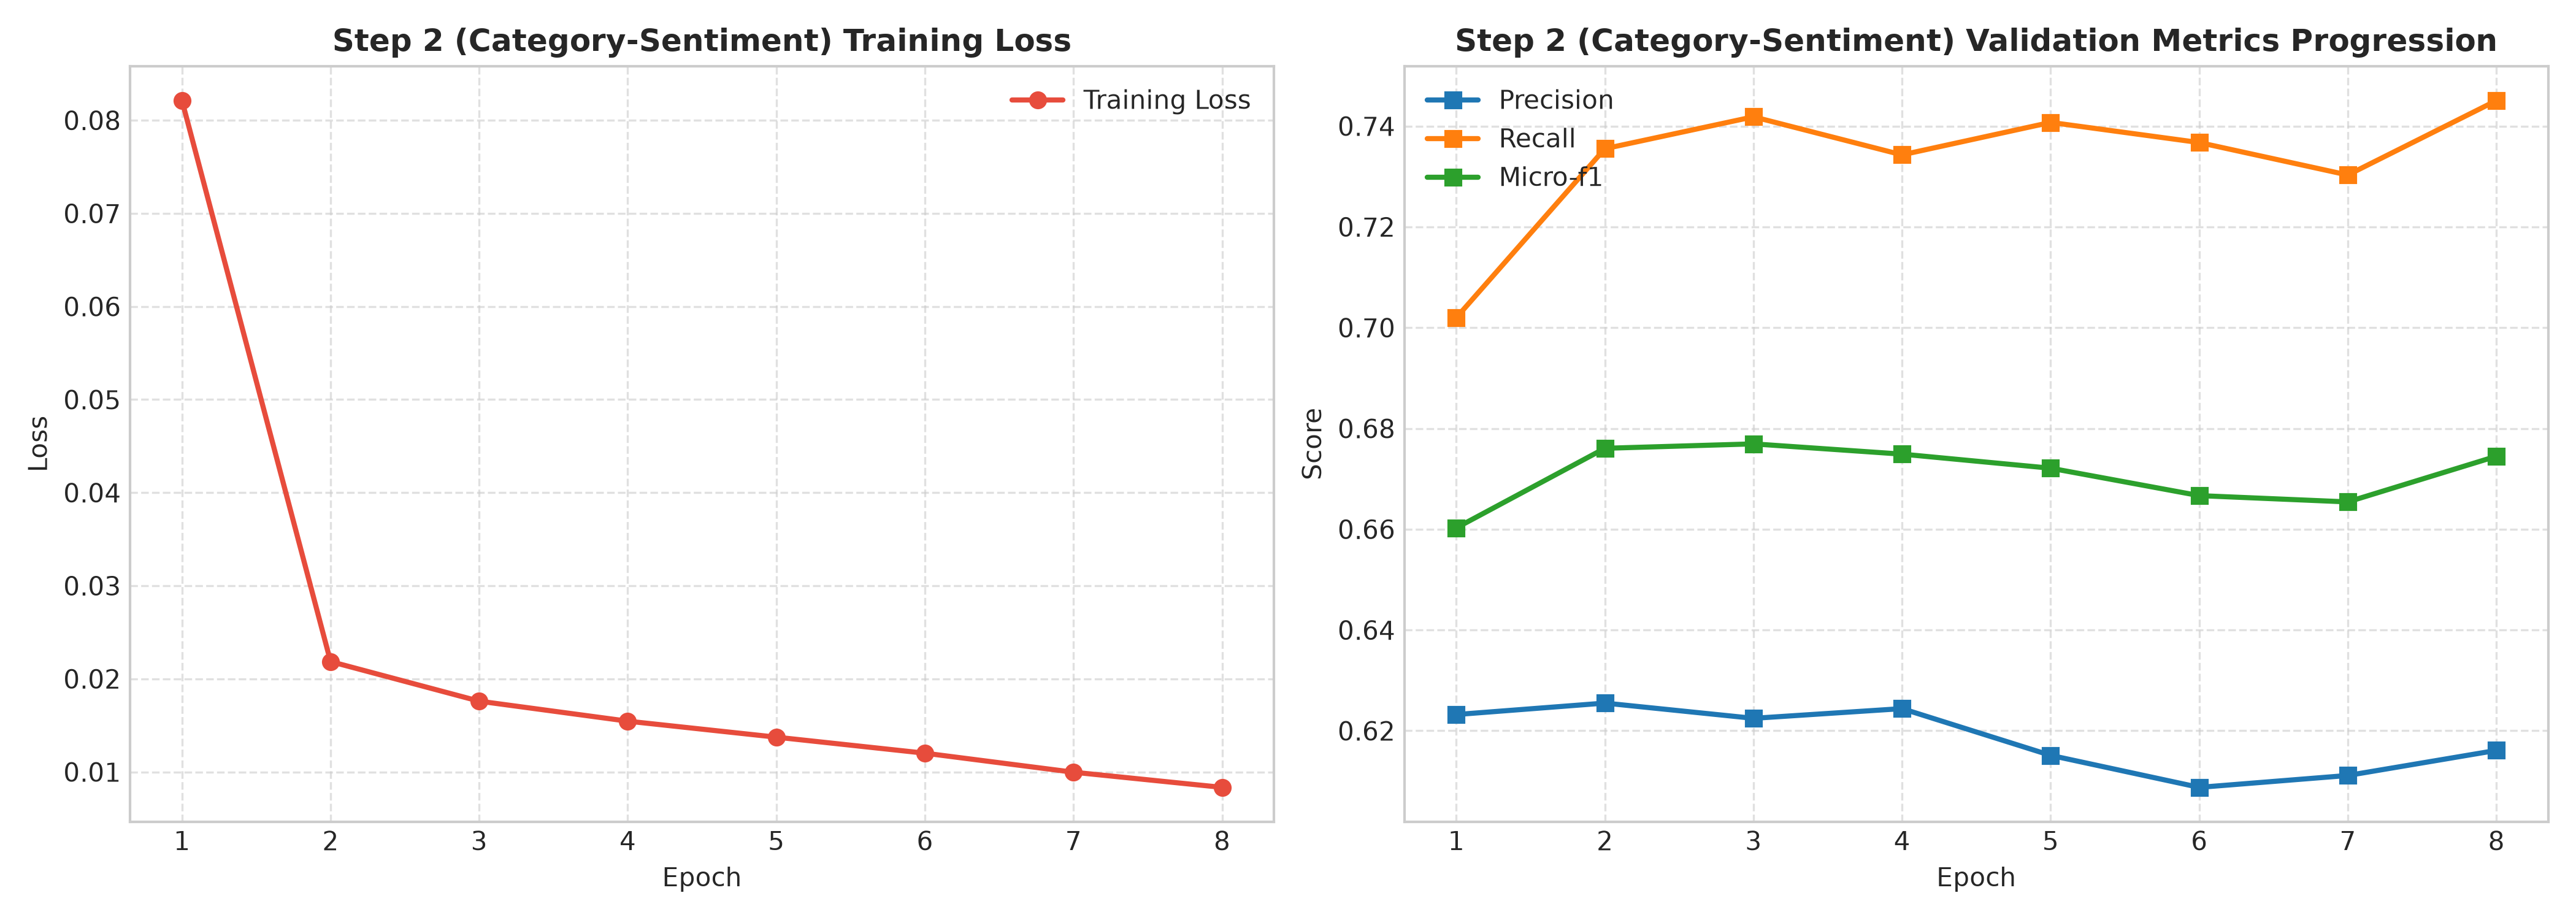

   [4/5]    0.4s  Manifest → STEP2_COMPLETED, pipeline_state.pkl diperbarui
   [5/5]    0.4s  📊 Laporan waktu eksekusi & GPU Step 2 diekspor: CSV, Excel (.xlsx), Markdown (.md)
✅ 8f. Plot, tabel laporan, manifest & state Step 2 — selesai dalam 0.4s



In [63]:
require_vars("step_stage", "step2_history", "best_step2_f1", "best2_epoch")

with step_stage("8f. Plot, tabel laporan, manifest & state Step 2", 5) as st:
    _p2 = os.path.join(plots_dir, "04_step2_training_loss_f1_curve.png")
    if step2_history:
        plot_training_history(
            step2_history, task_name="Step 2 (Category-Sentiment)",
            output_plot_path=_p2, output_csv_path=step2_csv
        )
        st.step(f"Plot & CSV riwayat ditulis ({len(step2_history)} epoch)")
    else:
        st.step("Riwayat kosong — plot dilewati")

    rep.section("5. Step 2: klasifikasi category & sentiment")
    df_s2_tabel = history_display_frame(step2_history)
    if not df_s2_tabel.empty:
        _kolom_hitung2 = [c for c in ("TP", "FP", "FN") if c in df_s2_tabel.columns]
        _src_txt = 'prediksi step 1' if globals().get('pakai_1st', True) else 'gold pair'
        export_step_table(df_s2_tabel, name="master_06_step2_riwayat", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Riwayat Training Step 2 ({DOMAIN.upper()})",
                          notes=("Metrik pada level quadruple lengkap. Sumber kandidat: "
                                 f"{_src_txt}. "
                                 + ("TP/FP/FN adalah hitungan mentah quadruple; "
                                    "Precision/Recall/Micro-F1 dalam persen."
                                    if _kolom_hitung2 else
                                    "Kolom TP/FP/FN tidak ada — riwayat berasal dari run "
                                    "sebelum patch metrik di sel 8a.")),
                          max_rows_md=NUM_EPOCHS)
        rep.table(df_s2_tabel, max_rows=NUM_EPOCHS, caption="Metrik step 2 per epoch")
        st.step(f"Tabel master_06_step2_riwayat diekspor (sumber kandidat: {_src_txt}, "
                f"kolom hitungan: {', '.join(_kolom_hitung2) or 'tidak ada'})")

        _row2, _f1_2, _ep2 = best_epoch_row(step2_history)
        rep.kv({
            "epoch_terbaik": _ep2 or best2_epoch,
            "micro-F1_terbaik": f"{_f1_2 * 100:.2f}%",
            "TP_FP_FN_epoch_terbaik": (
                f"{_row2.get('tp', float('nan')):.0f} / {_row2.get('fp', float('nan')):.0f} / "
                f"{_row2.get('fn', float('nan')):.0f}" if "tp" in _row2 else "tidak tercatat"),
            "checkpoint": step2_ckpt,
        })
        st.step(f"Micro-F1 terbaik {_f1_2 * 100:.2f}% (epoch {_ep2 or best2_epoch})")
    else:
        st.step("Tabel riwayat dilewati (tidak ada metrik per epoch)")

    if os.path.exists(_p2):
        from IPython.display import Image, display
        display(Image(_p2))
        rep.image(_p2, "Kurva training step 2")

    update_mcp_manifest("STEP2_COMPLETED", 5, {
        "step2_best_micro_f1": float(best_step2_f1 * 100 if best_step2_f1 <= 1.0 else best_step2_f1),
        "step2_checkpoint": step2_ckpt
    })
    save_pipeline_state({"best_step2_f1": best_step2_f1, "best_step2_epoch": best2_epoch})
    st.step("Manifest → STEP2_COMPLETED, pipeline_state.pkl diperbarui")

    # ── Ekspor Rekap Waktu Eksekusi, Profil GPU & Detail Epoch Step 2 (CSV, Excel, Markdown) ──
    if "execution_tracker" in globals() and execution_tracker is not None:
        _rep_dir_2 = os.path.join(session_dirs["root"], "execution_reports")
        _s2_files = execution_tracker.export_summary(
            output_dir=_rep_dir_2,
            session_name=f"ACOS_{DOMAIN.upper()}_Step2",
            gdrive_sync=True
        )
        st.step(f"📊 Laporan waktu eksekusi & GPU Step 2 diekspor: CSV, Excel (.xlsx), Markdown (.md)")


## 9. Evaluasi Final & Benchmark Sub-Task

### 9a. Evaluasi Quadruple dengan Checkpoint Terbaik
Memuat checkpoint Step 2 terbaik lalu menjalankan `pair_eval` sekali sambil menangkap
metrik per sub-task. **TP/FP/FN** ikut tersimpan — untuk metrik keseluruhan lewat patch
`measureQuad`, dan untuk tiap sub-task lewat `SubtaskMetricCapture`. Hasilnya di-cache ke
`logs/master_metrics.json`; set `FORCE_REEVAL = True` untuk mengevaluasi ulang.

In [64]:
ensure_objects()
require_vars("step_stage", "session_dirs")

# Evaluasi Final Memakai Checkpoint Model Step 2 Terbaik
FORCE_REEVAL = False

import logging
import eval_metrics as _em_final
from modeling import CategorySentiClassification
from eval_metrics import pair_eval
from colab_utils import SubtaskMetricCapture, plot_subtask_metrics

with step_stage("9a. Evaluasi final quadruple + metrik sub-task", 5) as st:
    metrics_json = os.path.join(session_dirs["logs"], "master_metrics.json")
    cached_metrics_available = os.path.exists(metrics_json)
    st.step(f"Cache metrik: {'ada' if cached_metrics_available else 'belum ada'} "
            f"({metrics_json}) | FORCE_REEVAL={FORCE_REEVAL}")

    if not FORCE_REEVAL and cached_metrics_available:
        with open(metrics_json, "r", encoding="utf-8") as jf:
            cached_all = json.load(jf)
        final_res = cached_all.get("overall", {})
        subtask_metrics = cached_all.get("subtasks", {})
        df_subtasks = pd.DataFrame([
            {"Subtask": k, "N_Elements": len(k.split()),
             "TP": v.get("tp", float("nan")), "FP": v.get("fp", float("nan")),
             "FN": v.get("fn", float("nan")),
             "Precision": v.get("precision", 0.0),
             "Recall": v.get("recall", 0.0), "Micro_F1": v.get("micro-F1", 0.0)}
            for k, v in subtask_metrics.items()
        ])
        st.step(f"[CACHE HIT] {len(final_res)} metrik keseluruhan, "
                f"{len(df_subtasks)} sub-task dimuat tanpa evaluasi ulang")
    else:
        if "eval_loader_2" not in globals() or "eval_gold_2" not in globals():
            raise RuntimeError(
                "Loader evaluasi Step 2 belum ada di memori dan master_metrics.json "
                "belum tersimpan. Jalankan sel 8c (dan 8a-8b) lebih dulu.")
        require_vars("args_h", "num_labels_step2", "label_list_step2")

        step2_ckpt_dir = session_dirs["step2_checkpoint"]
        os.makedirs(step2_ckpt_dir, exist_ok=True)
        step2_bin_path = os.path.join(step2_ckpt_dir, "pytorch_model.bin")

        # 1. Recovery langsung dari memori aktif (jika model_step2 baru saja dilatih di sel 8d/8e)
        if not os.path.exists(step2_bin_path) and "model_step2" in globals() and model_step2 is not None:
            torch.save(model_step2.state_dict(), step2_bin_path)
            if hasattr(model_step2, "config"):
                model_step2.config.to_json_file(os.path.join(step2_ckpt_dir, "config.json"))
            if "tokenizer" in globals() and tokenizer is not None:
                tokenizer.save_vocabulary(step2_ckpt_dir)
            st.note(f"💾 Checkpoint Step 2 berhasil disimpan dari model aktif di memori runtime → {step2_bin_path}")

        # 2. Fallback pencarian berkas lintas direktori sesi di Drive maupun lokal
        if not os.path.exists(step2_bin_path):
            _search_roots = [
                session_dirs.get("root", ""),
                results_base if 'results_base' in globals() else "",
                "/content/drive/MyDrive/ACOS/Output/results",
                "/content/drive/MyDrive/ACOS/results",
                "/content/drive/MyDrive/ACOS-ASLI/Output/results",
                "/content/drive/MyDrive/ACOS-ASLI/results",
                os.path.join(base_project_dir, "Output", "results") if 'base_project_dir' in globals() else "",
                os.path.join(base_project_dir, "results") if 'base_project_dir' in globals() else "",
            ]
            found_bin2 = auto_find_file("pytorch_model.bin", search_roots=_search_roots,
                                        must_contain="step2_best",
                                        domain=DOMAIN if 'DOMAIN' in globals() else None)
            if found_bin2 and os.path.exists(found_bin2):
                shutil.copy(found_bin2, step2_bin_path)
                src_dir2 = os.path.dirname(found_bin2)
                for fn in ["config.json", "vocab.txt"]:
                    fp = os.path.join(src_dir2, fn)
                    if os.path.exists(fp):
                        shutil.copy(fp, os.path.join(step2_ckpt_dir, fn))
                st.note(f"↪ Checkpoint Step 2 disalin dari {found_bin2}")

        # 3. Fallback darurat ke BERT pretrained cache jika checkpoint belum tersedia sama sekali
        if not os.path.exists(step2_bin_path):
            _bert_bin = os.path.join(bert_cache_dir, "pytorch_model.bin") if 'bert_cache_dir' in globals() else ""
            if _bert_bin and os.path.exists(_bert_bin):
                shutil.copy(_bert_bin, step2_bin_path)
                st.note(f"⚠️ Checkpoint Step 2 belum ada; menggunakan pretrained BERT cache sebagai fallback: {_bert_bin}")

        # 4. Pastikan file konfigurasi pendukung (config.json & vocab.txt) selalu ada
        for fn in ["config.json", "vocab.txt"]:
            dst_fp = os.path.join(step2_ckpt_dir, fn)
            if not os.path.exists(dst_fp) and 'bert_cache_dir' in globals():
                src_fp = os.path.join(bert_cache_dir, fn)
                if os.path.exists(src_fp):
                    shutil.copy(src_fp, dst_fp)

        if not os.path.exists(step2_bin_path):
            raise FileNotFoundError(
                f"Checkpoint Step 2 tidak ada di {step2_bin_path}. Jalankan sel 8e dulu.")
        st.step(f"Checkpoint dipakai: {step2_bin_path} "
                f"({os.path.getsize(step2_bin_path) / 1024 ** 2:.1f} MB)")

        model_step2_best = CategorySentiClassification.from_pretrained(
            session_dirs["step2_checkpoint"], num_labels=num_labels_step2).to(device)
        model_step2_best.eval()
        st.step(f"Model terbaik dimuat ke {device} dan diset ke mode eval")

        logger_final = logging.getLogger("Final_Eval")
        # Idempoten: 8a biasanya sudah memasangnya, tapi 9a bisa dijalankan
        # setelah restart kernel tanpa melewati 8a.
        patch_eval_metrics_counts()
        print(f"   Menjalankan pair_eval pada {len(eval_loader_2)} batch...", flush=True)
        with SubtaskMetricCapture(logger_final) as cap:
            final_res = pair_eval("final", args_h, logger_final, tokenizer, model_step2_best,
                                  eval_loader_2, eval_gold_2, label_list_step2, device,
                                  "categorysenti", eval_type="test")
        subtask_metrics = cap.to_dict()
        df_subtasks = cap.to_frame()
        _n_dgn_hitungan = sum(1 for v in subtask_metrics.values() if "tp" in v)
        st.step(f"pair_eval selesai: micro-F1 {final_res.get('micro-F1', 0.0) * 100:.2f}%, "
                f"{len(df_subtasks)} sub-task tertangkap "
                f"({_n_dgn_hitungan} dengan TP/FP/FN)")

        with open(metrics_json, "w", encoding="utf-8") as jf:
            json.dump({"overall": final_res, "subtasks": subtask_metrics,
                       "difficulty_breakdown": getattr(
                           _em_final, "LAST_DIFFICULTY_BREAKDOWN", []),
                       "step1_history": globals().get("step1_history", []),
                       "step2_history": globals().get("step2_history", []),
                       "sumber_kandidat": "step1" if globals().get("pakai_1st", True) else "gold",
                       "saved_at": datetime.now().isoformat()},
                      jf, indent=2)
        st.step(f"master_metrics.json tersimpan (TP/FP/FN keseluruhan + per sub-task): "
                f"{metrics_json}")

    print("\n🏆 Metrik Quadruple Akhir:")
    for k, v in final_res.items():
        if k in ("tp", "fp", "fn"):
            print(f"   {k.upper():15s}: {float(v):.0f}")
        else:
            print(f"   {k:15s}: {float(v) * 100:.2f}%")

▶️  9a. Evaluasi final quadruple + metrik sub-task
   [1/5]    0.0s  Cache metrik: ada (/shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/logs/master_metrics.json) | FORCE_REEVAL=False
   [2/5]    0.0s  [CACHE HIT] 6 metrik keseluruhan, 15 sub-task dimuat tanpa evaluasi ulang

🏆 Metrik Quadruple Akhir:
   precision      : 62.25%
   recall         : 74.18%
   micro-F1       : 67.69%
   TP             : 6681
   FP             : 4052
   FN             : 2325
✅ 9a. Evaluasi final quadruple + metrik sub-task — selesai dalam 0.0s



### 9b. Tabel & Plot Benchmark
Sel pelaporan murni: aman diulang tanpa menyentuh GPU. Tabel `master_07` memuat TP/FP/FN
sebagai hitungan mentah dan precision/recall/micro-F1 dalam persen; `master_08` menampilkan
kolom yang sama untuk tiap sub-task.

▶️  9b. Tabel & plot benchmark sub-task
=== Metrik Akhir Ekstraksi Quadruple (APPSID) (6 baris) ===


,Metrik,Jenis,Nilai,Tampil
0,precision,laju,0.622473,62.25%
1,recall,laju,0.741839,74.18%
2,micro-F1,laju,0.676934,67.69%
3,TP,hitungan,6681.000000,6681
4,FP,hitungan,4052.000000,4052
5,FN,hitungan,2325.000000,2325


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_07_metrik_quadruple_final.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_07_metrik_quadruple_final.md
   [1/5]    0.0s  Tabel master_07 diekspor | sumber kandidat: prediksi step 1 (skor pipeline penuh) | TP/FP/FN: ada
=== Metrik per Sub-Task (APPSID) - 15 kombinasi (15 baris) ===


,Subtask,N_Elements,TP,FP,FN,Precision,Recall,Micro_F1
0,category,1,16219.0,1063.0,1821.0,93.85,89.91,91.84
1,sentiment,1,13246.0,2125.0,2289.0,86.18,85.27,85.72
2,category sentiment,2,14226.0,3485.0,3863.0,80.32,78.64,79.47
3,aspect,1,17622.0,935.0,1895.0,94.96,90.29,92.57
4,category aspect,2,17217.0,1411.0,2300.0,92.43,88.22,90.27
5,sentiment aspect,2,15432.0,3616.0,4096.0,81.02,79.02,80.01
6,category sentiment aspect,3,15047.0,4072.0,4481.0,78.70,77.05,77.87
7,opinion,1,16579.0,933.0,1103.0,94.67,93.76,94.21
8,category opinion,2,16507.0,5194.0,2365.0,76.07,87.47,81.37
9,sentiment opinion,2,14751.0,3233.0,2931.0,82.02,83.42,82.72


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_08_metrik_subtask.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_08_metrik_subtask.md
   [2/5]    0.0s  Tabel master_08 diekspor (15 sub-task, hitungan: TP, FP, FN)


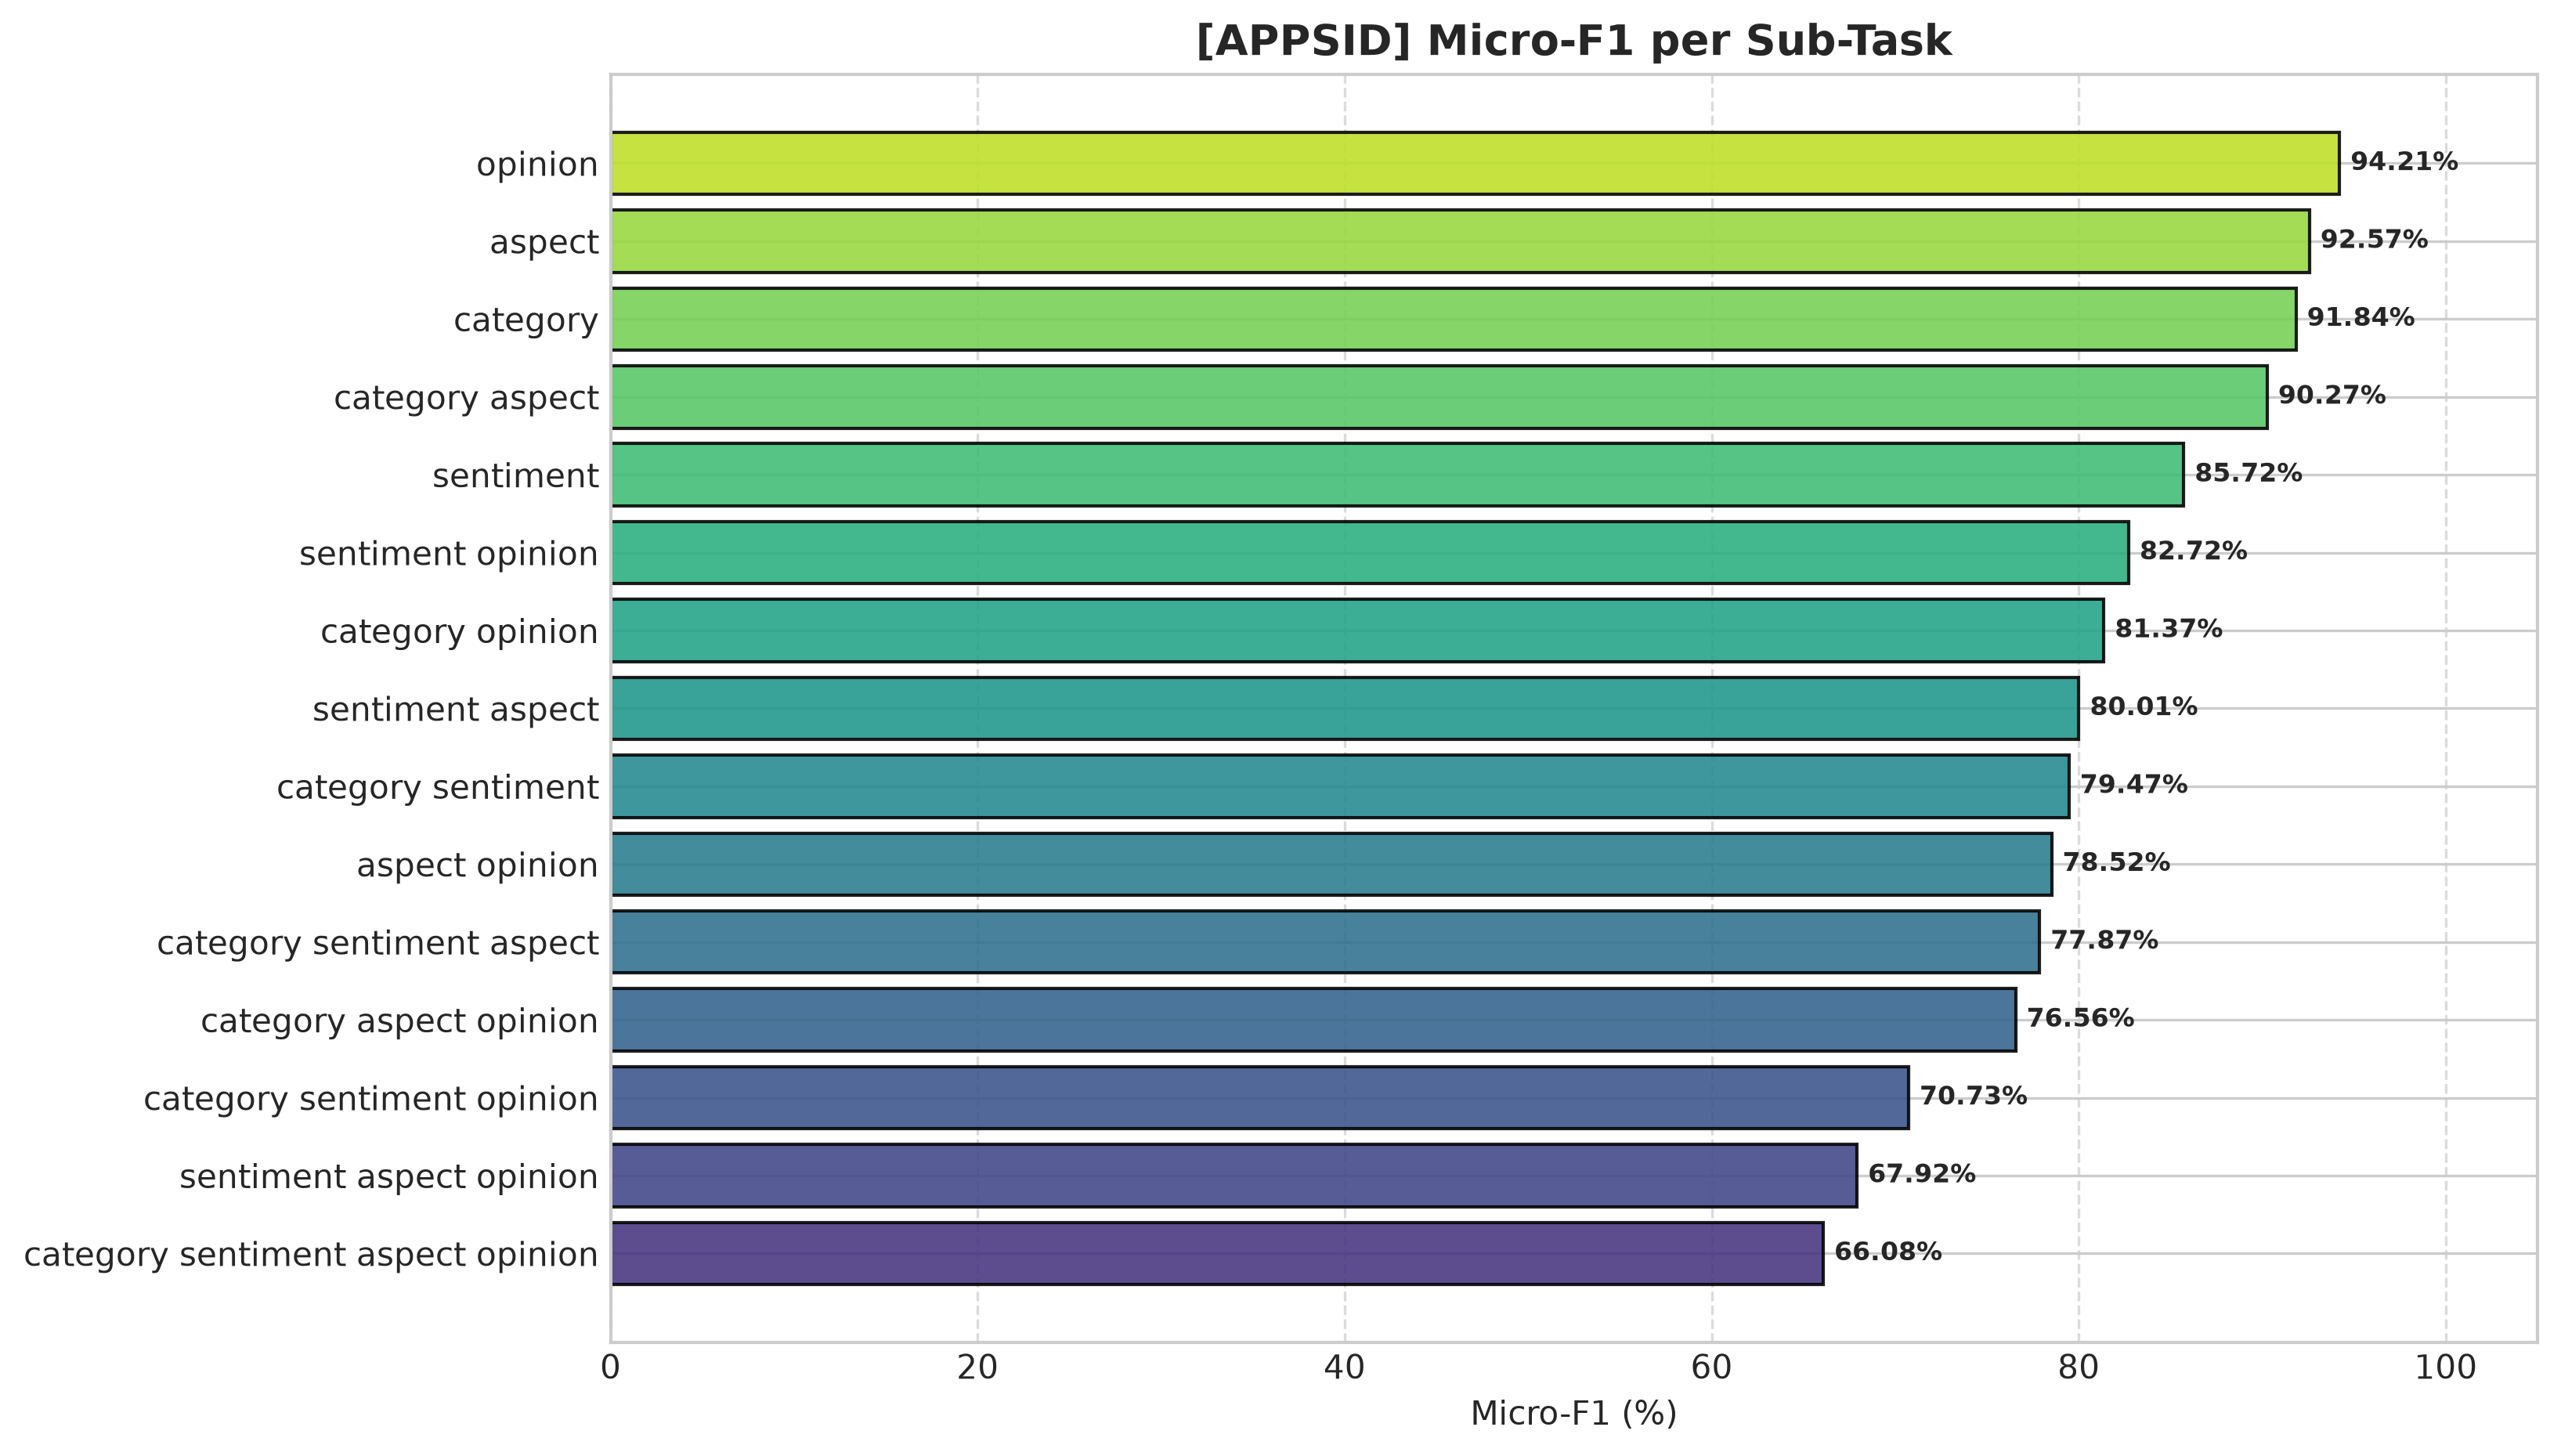

[plot] Disimpan: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/plots/05_benchmark_subtasks_f1.png
   [3/5]    0.7s  Plot benchmark disimpan: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/plots/05_benchmark_subtasks_f1.png
=== Micro-F1 Menurut Jumlah Elemen (APPSID) (4 baris) ===


,N_Elements,Jumlah_Subtask,Micro_F1_Rata2,Micro_F1_Min,Micro_F1_Maks,TP_Total,FP_Total,FN_Total
0,1,4,91.08,85.72,94.21,63666.0,5056.0,7108.0
1,2,6,82.06,78.52,90.27,95222.0,23852.0,17994.0
2,3,4,73.27,67.92,77.87,61116.0,28493.0,16340.0
3,4,1,66.08,66.08,66.08,14531.0,9920.0,4997.0


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_09_agregasi_elemen.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_09_agregasi_elemen.md
   [4/5]    0.7s  Agregasi per jumlah elemen diekspor (4 baris)
   [5/5]    0.7s  Manifest → FINAL_EVAL_COMPLETED, pipeline_state.pkl diperbarui
✅ 9b. Tabel & plot benchmark sub-task — selesai dalam 0.7s



In [65]:
require_vars("step_stage", "final_res", "df_subtasks")

with step_stage("9b. Tabel & plot benchmark sub-task", 5) as st:
    rep.section("6. Hasil akhir pipeline")
    df_overall = metrics_display_frame(final_res)
    _sumber = ('prediksi step 1 (skor pipeline penuh)' if globals().get('pakai_1st', True)
               else 'gold pair (step 2 terisolasi)')
    _ada_hitungan_final = "hitungan" in set(df_overall.get("Jenis", []))
    export_step_table(df_overall, name="master_07_metrik_quadruple_final",
                      csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Metrik Akhir Ekstraksi Quadruple ({DOMAIN.upper()})",
                      notes=(f"Sumber kandidat: {_sumber}. "
                             + ("Baris berjenis 'hitungan' (TP/FP/FN) adalah jumlah "
                                "quadruple, bukan persentase."
                                if _ada_hitungan_final else
                                "TP/FP/FN tidak tersedia — metrik ini dimuat dari cache "
                                "master_metrics.json sebelum patch sel 8a. Set "
                                "FORCE_REEVAL=True di sel 9a untuk menghitung ulang.")))
    rep.table(df_overall, caption="Metrik quadruple akhir")
    st.step(f"Tabel master_07 diekspor | sumber kandidat: {_sumber} | "
            f"TP/FP/FN: {'ada' if _ada_hitungan_final else 'tidak ada'}")

    if not df_subtasks.empty:
        df_sub_pct = df_subtasks.copy()
        for c in ["Precision", "Recall", "Micro_F1"]:
            if c in df_sub_pct.columns and df_sub_pct[c].max() <= 1.0:
                df_sub_pct[c] = (df_sub_pct[c] * 100).round(2)
        for c in ["TP", "FP", "FN"]:
            if c in df_sub_pct.columns:
                df_sub_pct[c] = pd.to_numeric(df_sub_pct[c], errors="coerce").round(0)
        _kolom_hitung_sub = [c for c in ("TP", "FP", "FN")
                             if c in df_sub_pct.columns and df_sub_pct[c].notna().any()]

        rep.section("7. Metrik per sub-task")
        export_step_table(df_sub_pct, name="master_08_metrik_subtask", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Metrik per Sub-Task ({DOMAIN.upper()}) - {len(df_sub_pct)} kombinasi",
                          notes=("Diambil dari keluaran pair_eval sesi ini, bukan angka manual. "
                                 + (f"Kolom hitungan mentah: {', '.join(_kolom_hitung_sub)}."
                                    if _kolom_hitung_sub else
                                    "TP/FP/FN kosong — sub-task ini ditangkap sebelum patch "
                                    "metrik aktif.")),
                          max_rows_md=20)
        rep.table(df_sub_pct, max_rows=20, caption="Metrik per sub-task")
        st.step(f"Tabel master_08 diekspor ({len(df_sub_pct)} sub-task, "
                f"hitungan: {', '.join(_kolom_hitung_sub) or 'tidak ada'})")

        _ps = os.path.join(plots_dir, "05_benchmark_subtasks_f1.png")
        plot_subtask_metrics(df_subtasks, _ps,
                             title=f"[{DOMAIN.upper()}] Micro-F1 per Sub-Task")
        rep.image(_ps, "Micro-F1 per sub-task")
        st.step(f"Plot benchmark disimpan: {_ps}")

        _agg_spec = {"Jumlah_Subtask": ("Subtask", "count"),
                     "Micro_F1_Rata2": ("Micro_F1", "mean"),
                     "Micro_F1_Min": ("Micro_F1", "min"),
                     "Micro_F1_Maks": ("Micro_F1", "max")}
        for _c, _label in (("TP", "TP_Total"), ("FP", "FP_Total"), ("FN", "FN_Total")):
            if _c in df_subtasks.columns and df_subtasks[_c].notna().any():
                _agg_spec[_label] = (_c, "sum")
        df_agg = df_subtasks.groupby("N_Elements").agg(**_agg_spec).reset_index()
        for c in ["Micro_F1_Rata2", "Micro_F1_Min", "Micro_F1_Maks"]:
            if df_agg[c].max() <= 1.0:
                df_agg[c] = (df_agg[c] * 100).round(2)
        for c in ["TP_Total", "FP_Total", "FN_Total"]:
            if c in df_agg.columns:
                df_agg[c] = df_agg[c].round(0)
        export_step_table(df_agg, name="master_09_agregasi_elemen", csv_dir=csv_dir,
                          md_dir=md_dir,
                          title=f"Micro-F1 Menurut Jumlah Elemen ({DOMAIN.upper()})",
                          notes=("TP/FP/FN_Total adalah jumlah hitungan mentah seluruh "
                                 "sub-task pada jumlah elemen yang sama."
                                 if "TP_Total" in df_agg.columns else None))
        rep.table(df_agg, caption="Agregasi per jumlah elemen")
        st.step(f"Agregasi per jumlah elemen diekspor ({len(df_agg)} baris)")
    else:
        st.step("df_subtasks kosong — tabel dan plot sub-task dilewati")

    update_mcp_manifest("FINAL_EVAL_COMPLETED", 6, {
        "final_metrics": final_res, "metrics_json_path": metrics_json
    })
    save_pipeline_state({"final_res": final_res})
    st.step("Manifest → FINAL_EVAL_COMPLETED, pipeline_state.pkl diperbarui")

## 10. Live Interactive Inference Demo pada Teks Ulasan Bebas

In [66]:
ensure_objects()
import re as _re

# Kelas model diimpor di sel 12 & 22; ambil ulang bila sel ini dijalankan
# sendiri sesudah pemulihan state.
from modeling import BertForQuadABSA, CategorySentiClassification


In [67]:

# Muat model Step 1 & Step 2 terbaik untuk inferensi live (dengan fallback auto-load)
step1_best_path = session_dirs["step1_checkpoint"]
if not os.path.exists(os.path.join(step1_best_path, "pytorch_model.bin")):
    found_b1 = auto_find_file("pytorch_model.bin", must_contain="step1_best")
    if found_b1 and "step1_best" in found_b1:
        step1_best_path = os.path.dirname(found_b1)

step2_best_path = session_dirs["step2_checkpoint"]
if not os.path.exists(os.path.join(step2_best_path, "pytorch_model.bin")):
    found_b2 = auto_find_file("pytorch_model.bin", must_contain="step2_best")
    if found_b2 and "step2_best" in found_b2:
        step2_best_path = os.path.dirname(found_b2)

model_step1_best = BertForQuadABSA.from_pretrained(
    step1_best_path, num_labels=num_labels_step1).to(device)
model_step1_best.eval()

model_step2_best = CategorySentiClassification.from_pretrained(
    step2_best_path, num_labels=num_labels_step2).to(device)
model_step2_best.eval()

_catsenti_labels = label_list_step2[0]

def _spans_dari_tag(tag_ids):
    s = "".join(str(t) for t in tag_ids)
    aspects = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"32*", s)]
    opinions = [(m.start() - 1, m.end() - 1) for m in _re.finditer(r"54*", s)]
    return aspects, opinions


In [68]:

def analyze_review_quadruples(review_text, domain=None, ambang=0.0, tampilkan_proses=True):
    """Ekstraksi quadruple dua tahap untuk satu teks ulasan bebas."""
    domain = domain or DOMAIN
    max_len = MAX_SEQ_LENGTH

    tokens = tokenizer.tokenize(review_text.lower())[: max_len - 2]
    input_tokens = ["[CLS]"] + tokens + ["[SEP]"]
    input_ids = tokenizer.convert_tokens_to_ids(input_tokens)
    attn = [1] * len(input_ids)
    seg = [0] * len(input_ids)
    while len(input_ids) < max_len:
        input_ids.append(0)
        attn.append(0)
        seg.append(0)

    t_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    t_attn = torch.tensor([attn], dtype=torch.long).to(device)
    t_seg = torch.tensor([seg], dtype=torch.long).to(device)
    t_dummy = torch.zeros((1, max_len), dtype=torch.long).to(device)
    t_zero = torch.zeros(1, dtype=torch.long).to(device)

    with torch.no_grad():
        out1 = model_step1_best(
            aspect_input_ids=t_ids, aspect_labels=t_dummy,
            aspect_token_type_ids=t_seg, aspect_attention_mask=t_attn,
            exist_imp_aspect=t_zero, exist_imp_opinion=t_zero,
        )
    _, logits1 = unpack_model_output(out1)
    pred_tags, imp_a_logit, imp_o_logit = logits1
    imp_aspect = int(imp_a_logit.argmax(-1).item()) == 1
    imp_opinion = int(imp_o_logit.argmax(-1).item()) == 1

    aspects, opinions = _spans_dari_tag(pred_tags[0])
    if imp_aspect or not aspects:
        aspects = aspects + [(-1, -1)]
    if imp_opinion or not opinions:
        opinions = opinions + [(-1, -1)]

    if tampilkan_proses:
        print(f"\nTeks Review : {review_text}")
        print(f"Tokens      : {tokens}")
        print(f"Aspect Spans: {aspects} (implicit={imp_aspect})")
        print(f"Opinion Span: {opinions} (implicit={imp_opinion})")

    hasil = []
    for (a_st, a_ed) in aspects:
        for (o_st, o_ed) in opinions:
            cand_a = [0] * max_len
            cand_o = [0] * max_len
            if a_st == -1:
                cand_a[0] = 1
            else:
                for i in range(a_st + 1, a_ed + 1):
                    if i < max_len: cand_a[i] = 1
            if o_st == -1:
                cand_o[len(tokens) + 1] = 1
            else:
                for i in range(o_st + 1, o_ed + 1):
                    if i < max_len: cand_o[i] = 1

            with torch.no_grad():
                out2 = model_step2_best(
                    tokenizer, 0,
                    aspect_input_ids=t_ids,
                    aspect_token_type_ids=t_seg,
                    aspect_attention_mask=t_attn,
                    candidate_aspect=torch.tensor([cand_a], dtype=torch.long).to(device),
                    candidate_opinion=torch.tensor([cand_o], dtype=torch.long).to(device),
                    label_id=torch.zeros((1, num_labels_step2), dtype=torch.float).to(device),
                )
            _, logits2 = unpack_model_output(out2)
            skor = logits2[0][0].detach().cpu().numpy()

            aktif = [i for i, v in enumerate(skor) if v > ambang] or [int(skor.argmax())]
            asp_txt = "[IMPLICIT]" if a_st == -1 else " ".join(tokens[a_st:a_ed])
            opi_txt = "[IMPLICIT]" if o_st == -1 else " ".join(tokens[o_st:o_ed])

            for idx in aktif:
                kategori, sentimen = _catsenti_labels[idx].rsplit("#", 1)
                hasil.append({
                    "Aspect": asp_txt,
                    "Aspect_Span": f"{a_st},{a_ed}",
                    "Category": kategori,
                    "Opinion": opi_txt,
                    "Opinion_Span": f"{o_st},{o_ed}",
                    "Sentiment": {"0": "negative", "1": "neutral", "2": "positive"}.get(sentimen, sentimen),
                    "Skor_Logit": round(float(skor[idx]), 4),
                    "Is_Implicit_Aspect": a_st == -1,
                    "Is_Implicit_Opinion": o_st == -1,
                })

    df = pd.DataFrame(hasil)
    if not df.empty:
        df = df.sort_values("Skor_Logit", ascending=False).reset_index(drop=True)
    return df

# Contoh Pengujian Live Review — dipilih menurut bahasa domain.
SAMPLE_REVIEWS = {
    "appsid": "transfer nya cepat tapi aplikasi sering error saat buka menu",
    "rest16": "The sushi was fresh and delicious, but the service was slow.",
    "laptop": "The battery life is great but the keyboard feels cheap.",
}
sample_review = SAMPLE_REVIEWS.get(DOMAIN, SAMPLE_REVIEWS["appsid"])
df_infer = analyze_review_quadruples(sample_review, domain=DOMAIN)

rep.section("8. Contoh inferensi")
rep.text(f"Teks: `{sample_review}`")
if not df_infer.empty:
    export_step_table(df_infer, name="master_10_contoh_inferensi", csv_dir=csv_dir, md_dir=md_dir,
                      title="Quadruple Hasil Inferensi Contoh",
                      notes="Skor_Logit adalah keluaran mentah sebelum sigmoid; ambang default 0.0.",
                      max_rows_md=20)
    rep.table(df_infer, max_rows=20, caption="Quadruple hasil inferensi")
    from IPython.display import display
    display(df_infer)

save_pipeline_state({"df_infer": df_infer})


Teks Review : transfer nya cepat tapi aplikasi sering error saat buka menu
Tokens      : ['transfer', 'nya', 'cepat', 'tapi', 'aplikasi', 'sering', 'error', 'saat', 'buka', 'menu']
Aspect Spans: [(0, 1), (9, 10)] (implicit=False)
Opinion Span: [(2, 3), (5, 7)] (implicit=False)
=== Quadruple Hasil Inferensi Contoh (4 baris) ===


/opt/venv/lib/python3.12/site-packages/torchcrf/__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /__w/rockrel/rockrel/external-builds/pytorch/pytorch/aten/src/ATen/native/TensorCompare.cpp:622.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)


,Aspect,Aspect_Span,Category,Opinion,Opinion_Span,Sentiment,Skor_Logit,Is_Implicit_Aspect,Is_Implicit_Opinion
0,menu,"9,10",UI_UX_DESIGN,sering error,"5,7",negative,2.7096,False,False
1,transfer,"0,1",TRANSACTION_TRANSFER,sering error,"5,7",negative,2.0260,False,False
2,menu,"9,10",UI_UX_DESIGN,cepat,"2,3",negative,0.5789,False,False
3,transfer,"0,1",TRANSACTION_TRANSFER,cepat,"2,3",positive,-0.4262,False,False


[tabel] CSV: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/csv/master_10_contoh_inferensi.csv | MD: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/md/master_10_contoh_inferensi.md


,Aspect,Aspect_Span,Category,Opinion,Opinion_Span,Sentiment,Skor_Logit,Is_Implicit_Aspect,Is_Implicit_Opinion
0,menu,"9,10",UI_UX_DESIGN,sering error,"5,7",negative,2.7096,False,False
1,transfer,"0,1",TRANSACTION_TRANSFER,sering error,"5,7",negative,2.0260,False,False
2,menu,"9,10",UI_UX_DESIGN,cepat,"2,3",negative,0.5789,False,False
3,transfer,"0,1",TRANSACTION_TRANSFER,cepat,"2,3",positive,-0.4262,False,False


'/shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX/pipeline_state.pkl'

## 11. Ringkasan Seluruh Artefak & Finalisasi Sesi

In [69]:
# Audit akhir seluruh artefak tersimpan di Google Drive / lokal & Ekspor Final Benchmark
print("=" * 78)
print(f"🏁 AUDIT ARTEFAK SESI AKTIF [{DOMAIN.upper()}]")
print("=" * 78)
print(f"📁 Lokasi Penyimpanan: {session_dirs.get('root')}")
is_drive_saved = "/content/drive/MyDrive" in session_dirs.get("root", "")
print(f"🛡️  Persistensi Google Drive: {'✅ TERSIMPAN DI DRIVE' if is_drive_saved or globals().get('GDRIVE_MOUNTED') else '⚠️ LOKAL / EPHEMERAL'}\n")

all_saved_files = []
for sub_name, sub_path in session_dirs.items():
    if sub_name == "root" or not os.path.isdir(sub_path):
        continue
    for root, dirs, files in os.walk(sub_path):
        for f in sorted(files):
            fp = os.path.join(root, f)
            sz = os.path.getsize(fp)
            all_saved_files.append({
                "Subfolder": sub_name,
                "File": f,
                "Size": f"{sz / 1024:.1f} KB" if sz < 1024*1024 else f"{sz / (1024**2):.2f} MB",
                "Path": fp
            })

df_audit = pd.DataFrame(all_saved_files)
if not df_audit.empty:
    print(f"📦 Total {len(df_audit)} file berhasil diamankan di sesi ini:")
    for sf, grp in df_audit.groupby("Subfolder"):
        print(f"\n📂 [{sf.upper()}] ({len(grp)} file):")
        for r in grp.itertuples():
            print(f"   - {r.File:<42} ({r.Size})")
else:
    print("⚠️ Belum ada file tersimpan di subfolder sesi.")

# ── Ekspor Konsolidasi Laporan Waktu Eksekusi, Profil GPU & Detail Epoch (CSV, Excel, Markdown) ──
if "execution_tracker" in globals() and execution_tracker is not None:
    final_rep_dir = os.path.join(session_dirs["root"], "final_reports")
    final_files = execution_tracker.export_summary(
        output_dir=final_rep_dir,
        session_name=f"ACOS_Master_Pipeline_{DOMAIN.upper()}",
        gdrive_sync=True
    )
    print("\n" + "=" * 78)
    print("⏱️  REKAP WAKTU EKSEKUSI & PROFIL GPU SELESAI DIEKSPOR:")
    print("=" * 78)
    print(f"📄 CSV Summary     : {final_files['csv']}")
    print(f"📊 Excel Workbook  : {final_files['excel']}")
    print(f"📝 Markdown Report : {final_files['md']}")

    # Render tampilan tabel Markdown di output notebook
    try:
        from IPython.display import display, Markdown
        with open(final_files['md'], "r", encoding="utf-8") as _f_md:
            display(Markdown(_f_md.read()))
    except Exception as _e_disp:
        pass

# ── Cadangkan Seluruh Folder Sesi ke Google Drive jika Aktif ──
if globals().get("GDRIVE_MOUNTED") and "sync_to_gdrive" in globals():
    print("\n☁️  Menyinkronkan seluruh folder sesi ke Google Drive...")
    _sess_folder_name = os.path.basename(os.path.normpath(session_dirs["root"]))
    _drive_ok = sync_to_gdrive(session_dirs["root"], f"sessions/{_sess_folder_name}")
    if _drive_ok:
        print(f"✅ Sesi lengkap tersimpan di Google Drive: {GDRIVE_BACKUP_DIR}/sessions/{_sess_folder_name}")
    else:
        print("⚠️ Sinkronisasi sesi penuh ke Google Drive mengalami kendala.")
print("=" * 78)


🏁 AUDIT ARTEFAK SESI AKTIF [APPSID]
📁 Lokasi Penyimpanan: /shared-docker/ACOS/ACOS-IndoBERT/results/appsid_24092026_0901XX
🛡️  Persistensi Google Drive: ✅ TERSIMPAN DI DRIVE

📦 Total 78 file berhasil diamankan di sesi ini:

📂 [CHECKPOINTS] (10 file):
   - optimizer.pt                               (949.59 MB)
   - pytorch_model.bin                          (477.07 MB)
   - config.json                                (1.5 KB)
   - pytorch_model.bin                          (475.01 MB)
   - vocab.txt                                  (223.8 KB)
   - optimizer.pt                               (945.48 MB)
   - pytorch_model.bin                          (475.01 MB)
   - config.json                                (1.5 KB)
   - pytorch_model.bin                          (477.07 MB)
   - vocab.txt                                  (223.8 KB)

📂 [CSV] (21 file):
   - candidate_pairs_summary.csv                (886.0 KB)
   - eda_all_samples_annotated.csv              (10.15 MB)
   - eda_dataset_st

# ⏱️ Ringkasan Waktu Eksekusi & Profil GPU: ACOS_Master_Pipeline_APPSID

> Diekspor otomatis pada: `2026-09-24 14:00:15`

## 🖥️ 1. Detail Hardware & Akselerator GPU
| Parameter | Nilai |
| :--- | :--- |
| **GPU Model** | AMD Instinct MI300X VF |
| **Total VRAM** | 191.69 GB |
| **Tipe Akselerator** | AMD ROCm HIP |
| **Kategori Akselerator** | 🚀 High-End / Large GPU |
| **Compute Cap / HIP** | 7.14.60850 |
| **PyTorch Version** | 2.12.0+rocm7.14.0 |
| **Sistem Operasi** | Linux 6.8.0-142-generic |



☁️  Menyinkronkan seluruh folder sesi ke Google Drive...
⚠️ Sinkronisasi sesi penuh ke Google Drive mengalami kendala.
